# Guía de Continuación: Arquitectura y Recuperación de Universo

## 1) Deuda arquitectónica detectada y solución propuesta

Problema actual:
- `01_dataset_builder.ipynb` está monolítico y mezcla cuatro capas que deberían estar separadas:
1. contrato de datos,
2. diagnóstico/lectura,
3. política de decisión,
4. orquestación masiva.

Riesgo de seguir igual:
- difícil testear,
- difícil reproducir,
- alto riesgo de romper decisiones previas al tocar una parte,
- evolución lenta (cada mejora exige editar un notebook grande y acoplado).

Solución objetivo (arquitectura por módulos):
1. `src/backtest/contracts.py`
- definiciones canónicas: columnas, dtypes, umbrales, enums de decisión (`GO/WARN/FAIL/NOT_COMPARABLE`).

2. `src/backtest/policy.py`
- reglas de decisión puras y deterministas, separadas de visualización.

3. `src/backtest/remediation.py`
- normalización y recuperación: alias de columnas, coerción de tipos/unidades de timestamp, manejo de `schema_gap`.

4. `src/backtest/orchestration.py`
- ejecución masiva con checkpoints, estado, logs y manifests.

5. Este notebook `02_policy_integration_and_massive_orchestration.ipynb`
- rol: integración, lectura de artefactos, reportes y decisión final; no contener la lógica core en bruto.

Decisión operativa:
- `01_dataset_builder.ipynb` se mantiene como histórico/base explicativa,
- la evolución productiva continúa en `02` + módulos `src/`.

---

## 2) Reducir `NOT_COMPARABLE` (schema_gap) y recortar `FAIL` recuperable

Importante:
- resolver deuda arquitectónica no sube automáticamente el % de PASS,
- el % mejora al corregir causas de comparabilidad y cobertura.

### Embudo de recuperación (orden recomendado)

1. Prioridad 1: `NOT_COMPARABLE` por `schema_gap`
- inventario masivo de columnas/tipos por dominio,
- diccionario de alias canónicos,
- normalizador único previo a checks 03/06,
- re-evaluación de comparabilidad tras normalización.

2. Prioridad 2: `FAIL` recuperable (`sample`, `point`, `magnitude`)
- excluir días truncados/contaminados detectados,
- exigir mínimo de días válidos por ticker,
- recalcular 03/06 sobre muestra depurada,
- mover borderline a `WARN` guardrailed (no forzar `GO`).

3. `hard_fail` no recuperable en esta fase
- mantener fuera de universo operativo,
- dejar root cause explícita para trazabilidad.

### Regla de calidad
- no relajar umbrales para "fabricar GO",
- primero normalizar/corregir causas estructurales,
- después medir delta real en `GO/WARN/FAIL/NOT_COMPARABLE`.

---

## 3) ¿Trabajar recuperación en `01` o saltar a `02`?

Respuesta de trabajo acordada:
- **Saltamos a `02` como carril principal**.

Uso permitido de `01`:
1. congelar evidencia histórica,
2. dejar notas puente hacia la nueva arquitectura,
3. evitar seguir metiendo lógica nueva de producción.

Justificación:
- si seguimos metiendo recuperación en `01`, aumentamos acoplamiento técnico;
- en `02` + `src/` podemos recuperar universo con control, pruebas y reproducibilidad.

---

## 4) Entregables inmediatos de esta fase

1. Pipeline de remediación (`schema_gap`) ejecutable y versionado.
2. Re-run masivo 03/06 post-remediation con manifest de linaje.
3. Tabla before/after con delta de estados:
- `% GO`, `% WARN`, `% FAIL`, `% NOT_COMPARABLE`,
- principales root causes residuales.
4. Política final actualizada para `strict`, `relaxed` y `relaxed_guardrailed`.


**Creamos nuevo notebook por Razón técnica:**

1. 01_dataset_builder.ipynb ya mezcla contrato, diagnóstico, política y orquestación; seguir ahí lo vuelve demasiado
    monolítico.
2. Separar en 02 te da mejor trazabilidad de runs y menos riesgo de romper lo ya validado.
3. Te permite fijar un objetivo limpio para la siguiente fase (integración masiva de 07–13 y materialización final).

**Cómo lo estructuraría:**

1. 01_dataset_builder.ipynb: mantenerlo como base/contrato y evidencia histórica.
2. 02_backtest/02_policy_integration_and_massive_orchestration.ipynb:

- ingest de outputs masivos (03/06 y luego 07–13),
- policy matrix unificada,
- materialización strict y relaxed_guardrailed,
- reportes finales y manifests.

---

**Plan Específico por Notebook Pendiente**

Orden recomendado para maximizar valor y minimizar retrabajo.

1. 09_sequence_timestamp_integrity

- Fase A: definir tasa de out_of_order, duplicate_ts, cobertura de secuencia.
- Fase B: calibrar thresholds por percentiles cross-ticker.
- Fase C: corrida masiva con decisión final por ticker.
- Impacto en builder: guardrails de ejecución temporal.

2. 11_nbbo_spread_sanity

- Fase A: distribución de spread, crossed/locked, colas extremas.
- Fase B: calibrar por sesión (premarket/rth/postmarket).
- Fase C: masivo con buckets de riesgo de spread.
- Impacto en builder: restricción de ejecución en tickers con microestructura frágil.

3. 08_condition_code_eligibility

- Fase A: mapear cobertura de condition codes conocidos/desconocidos.
- Fase B: estimar missing_share y sesgo potencial en prints.
- Fase C: masivo con bandera de confiabilidad por ticker.
- Impacto en builder: filtros de elegibilidad para señal/ejecución.

4. 07_outliers_and_anomalies

- Fase A: definir outliers de precio/volumen/retorno con robustez.
- Fase B: calibrar cortes por MAD/IQR, no por media+sigma simple.
- Fase C: masivo con root causes y severidad.
- Impacto en builder: bloqueo o penalización de ventanas anómalas.

5. 10_clock_drift_qa

- Fase A: censo de aplicabilidad (dual-clock disponible o no).
- Fase B: solo si aplica, calibrar drift/jitter por venue.
- Fase C: masivo condicional.
- Si no aplica globalmente: cerrar formalmente en NOT_APPLICABLE con evidencia cuantitativa.

6. 12_off_exchange_trf_reconciliation

- Fase A: validación de mapeo venue/exchange.
- Fase B: si hay mapeo confiable, calibrar participación off-exchange.
- Fase C: masivo condicional.
- Si no hay mapeo robusto: NOT_APPLICABLE formal (no pseudo-métrica).

7. 13_external_execution_quality_605

- Fase A: fijar contrato de benchmark externo.
- Fase B: armonizar definiciones y ventanas temporales.
- Fase C: comparación masiva cuando existan insumos reales.
- Si no hay inputs: marcar como pendiente metodológico, no bloquear producción.

———

Arquitectura de Orquestación (igual que 03→06)
Extiende el orquestador actual a pipeline por fases:

1. run_massive_07_12() con fases secuenciales y estado persistente.
2. massive_state.json con phase, status, started_at, ended_at, returncode, used_attempt.
3. Un log por notebook ejecutado.
4. Reanudación automática desde la última fase fallida.
5. Verificador final de outputs (verify_*), igual que ya tienes en 03/06.

———

Criterios de “Listo” (Definition of Done)
Cierra el proyecto cuando se cumpla todo esto en la misma ola de runs:

1. 03 y 06 masivos completos y consistentes con builder.
2. 07, 08, 09, 11 con salida masiva y taxonomía unificada.
3. 10 y 12 cerrados como aplicables o no aplicables con evidencia.
4. 13 documentado como activo o pendiente por falta de fuente.
5. 01_dataset_builder integrado con todas las decisiones.
6. Datasets finales materializados y trazables (strict, relaxed_guardrailed).
7. Manifest final de linaje que conecte inputs, thresholds, decisiones y outputs.

———

Riesgos y Control de Calidad

1. Riesgo de drift entre corridas parciales y masivas.

- Control: fijar explícitamente source_run_id por notebook.

2. Riesgo de umbrales inestables en muestra chica.

- Control: dual-mode (small_sample_safe vs cross_ticker_calibrated), como ya hiciste.

3. Riesgo de falsas conclusiones por no aplicabilidad.

- Control: separar NOT_APPLICABLE de PASS.

4. Riesgo de decisiones opacas.

- Control: cada decisión debe tener root_cause y métricas trazables en parquet/json.

———

**Conclusión Operativa**

replicar el ciclo “explorar → calibrar → masivo” en cada notebook pendiente es la vía correcta para terminar bien, con rigor estadístico y con outputs realmente usables en producción de backtest.


In [14]:
# CARGA DE BASELINE (ENLACE 01 -> 02)
from pathlib import Path
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
BASELINE_ROOT = PROJECT_ROOT / "runs" / "baseline"

candidates = sorted(BASELINE_ROOT.glob("before_remediation_*"), key=lambda p: p.stat().st_mtime)
if not candidates:
    raise FileNotFoundError("No se encontro baseline before_remediation_* en runs/baseline. Ejecuta primero la celda final de 01.")

latest = candidates[-1]
manifest_path = latest / "baseline_before_manifest.json"
counts_path = latest / "baseline_before_counts.parquet"
root_path = latest / "baseline_before_root_causes.parquet"

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
counts = pl.read_parquet(counts_path)
root = pl.read_parquet(root_path)

print("=== BASELINE IMPORTADO EN 02 ===")
print("Baseline dir:", latest)
print("03 source:", manifest["source"]["03_run_dir"])
print("06 source:", manifest["source"]["06_run_dir"])
print("\n[Decision counts + ratio]")
print(counts)
print("\n[Top root causes por decision_final]")
print(root.head(30))



=== BASELINE IMPORTADO EN 02 ===
Baseline dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\before_remediation_20260224T085411Z
03 source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260222_194454_massive_v2
06 source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2

[Decision counts + ratio]
shape: (4, 3)
┌────────────────┬───────────┬──────────┐
│ decision_final ┆ n_tickers ┆ ratio    │
│ ---            ┆ ---       ┆ ---      │
│ str            ┆ u32       ┆ f64      │
╞════════════════╪═══════════╪══════════╡
│ NOT_COMPARABLE ┆ 3672      ┆ 0.768683 │
│ FAIL           ┆ 485       ┆ 0.101528 │
│ WARN           ┆ 381       ┆ 0.079757 │
│ GO             ┆ 239       ┆ 0.050031 │
└────────────────┴───────────┴──────────┘

[Top root causes por decision_final]
shape: (30, 3)
┌────────────────┬─────────────────────────────────┬─────┐
│ decision_final ┆ root_cause                      ┆ n   

## Paso 1 - Diagnóstico Base de `schema_gap` (congelado)

Objetivo de esta celda:
1. cargar el baseline `before_remediation` más reciente,
2. medir cuánto de `NOT_COMPARABLE` viene por `schema_gap` (y causas relacionadas),
3. guardar artefactos diagnósticos para trazabilidad,
4. imprimir tablas base para comparación futura `before vs after`.



In [17]:
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step1_schema_gap_baseline_diagnostic.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 1 - SCHEMA_GAP BASELINE DIAGNOSTIC ===
baseline: C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\before_remediation_20260224T085411Z
policy source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2\mvp_policy_mode_table.parquet
decision_col: decision_policy
root_col: root_cause_policy
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step1_schema_gap_baseline_20260226T103415Z

[Schema-like share dentro de NOT_COMPARABLE]
{'not_comparable_total': 3672, 'schema_like_total': 3672, 'schema_like_share_within_not_comparable': 1.0}

[Top root causes en NOT_COMPARABLE]
shape: (2, 3)
┌─────────────────┬───────────┬─────────────────────────────┐
│ root_cause_norm ┆ n_tickers ┆ ratio_within_not_comparable │
│ ---             ┆ ---       ┆ ---                         │
│ str             ┆ u32       ┆ f64                         │
╞═════════════════╪═══════════╪════

**Qué política nos llevó a tanto NOT_COMPARABLE**

- La corrida baseline usa qa_mode = cross_ticker_calibrated (archivo mvp_policy_mode_summary.json del run
20260223_124728...).
- Esa policy marca NOT_COMPARABLE antes de decidir GO/WARN/FAIL cuando falla comparabilidad estructural.
- En tu baseline:
    - n_tickers = 4777
    - n_comparable = 1105
    - NOT_COMPARABLE = 3672
- Y dentro de NOT_COMPARABLE:
    - schema_gap = 3629 (98.83%)
    - scale_mismatch = 43 (1.17%)

**Conclusión**:   
en 06 masiva el volumen de NOT_COMPARABLE viene casi todo de comparabilidad estructural, no de tuning fino de performance.

- En el run masivo (qa_mode_effective = cross_ticker_calibrated), NOT_COMPARABLE=3672 y
root_cause_policy='schema_gap'=3629.
- NOT_COMPARABLE se asigna cuando no se puede construir comparación OHLCV-vs-Quotes: faltan archivos/schema/timestamp,
no hay minutos con join, o hay desajuste de escala fuerte (scale_ratio fuera de [0.5, 2.0] en el build base).

**Qué compara exactamente 06**:

- **coverage_global**: minutos OHLCV con quotes alineables.
- **p_overlap**: % minutos donde [min_mid,max_mid] de quotes intersecta [low,high] de OHLCV.
- **p_in_range**: % minutos donde last_mid cae dentro de [low,high].
- **out_dist_abs_p95**: p95 de distancia fuera de rango (magnitud).
- **price_scale_ratio_close_over_mid**: coherencia de escala close vs mid.

**Umbrales de exigencia en la corrida masiva (calibrados del propio universo comparable):**

- **coverage_global**: PASS >= 0.808333, WARN >= 0.725010, si no FAIL.
- **p_overlap**: PASS >= 0.915584, WARN >= 0.827780, si no FAIL.
- **p_in_range**: PASS >= 0.793765, WARN >= 0.707547, si no FAIL.
- **out_dist_abs_p95**: PASS <= 0.010000, WARN <= 0.020000, si no FAIL.
- **trunc_ratio**: en calibrado, si trunc_ratio > 0, al menos WARN (porque trunc_warn_max=0.0).

Decisión final en comparables: FAIL si cualquier eje falla, WARN si no hay FAIL pero sí WARN, GO si todo PASS.


## Paso 2 - Plan de Recuperación `schema_gap` (priorizado y congelado)

Objetivo:
1. generar un plan accionable por ticker para recuperar comparabilidad,
2. separar carriles de remediación (`schema_gap` vs `scale_mismatch`),
3. priorizar por severidad proxy para ejecutar en olas,
4. guardar artifacts que alimenten el siguiente paso (aplicar remediación).



In [19]:
# PASO 2 - SCHEMA_GAP RECOVERY PLAN (PRIORIZADO)
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step2_schema_gap_recovery_plan.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 2 - SCHEMA_GAP RECOVERY PLAN ===
baseline: C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\before_remediation_20260224T085411Z
policy source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2\mvp_policy_mode_table.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step2_schema_gap_recovery_plan_20260226T103641Z
n_not_comparable: 3672
[Recovery track x priority]
shape: (3, 3)
┌──────────────────────────────┬─────────────────┬───────────┐
│ recovery_track               ┆ priority_bucket ┆ n_tickers │
│ ---                          ┆ ---             ┆ ---       │
│ str                          ┆ str             ┆ u32       │
╞══════════════════════════════╪═════════════════╪═══════════╡
│ TRACK_A_SCHEMA_NORMALIZATION ┆ P0              ┆ 3629      │
│ TRACK_B_SCALE_NORMALIZATION  ┆ P0              ┆ 14        │
│ TRACK_B_SCALE_NORMALIZATION  ┆ P1    

En el Paso 2 construimos un **plan de recuperación priorizado** para el bloque `NOT_COMPARABLE`, partiendo de:
- baseline: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\before_remediation_20260224T085411Z`
- source policy: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2\mvp_policy_mode_table.parquet`
- output dir del paso: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step2_schema_gap_recovery_plan_20260224T092710Z`

Objetivo operativo del paso:
1. clasificar todo `NOT_COMPARABLE` por tipo de recuperación,
2. priorizar por severidad proxy,
3. dejar artefactos trazables para ejecutar la remediación en olas.

### Resultado principal

Universo `NOT_COMPARABLE` detectado:
- `n_not_comparable = 3672`

Distribución por carril y prioridad:
- `TRACK_A_SCHEMA_NORMALIZATION, P0: 3629`
- `TRACK_B_SCALE_NORMALIZATION, P0: 14`
- `TRACK_B_SCALE_NORMALIZATION, P1: 29`

Resumen por causa raíz:
- `schema_gap: 3629 (0.98829)`
- `scale_mismatch: 43 (0.01171)`

### Lectura técnica

1. La causa dominante del bloqueo es estructural de esquema (`schema_gap`) y no de umbrales finos.
2. El frente crítico de recuperación está claramente concentrado en `TRACK_A_SCHEMA_NORMALIZATION`.
3. El bloque `scale_mismatch` existe pero es secundario en volumen.
4. Las filas de muestra muestran que gran parte del universo llega con métricas `null`, lo que refuerza que primero toca normalizar comparabilidad antes de recalibrar decisión final.

### Implicación para el Paso 3

El Paso 3 debe ejecutar una primera remediación automática sobre `TRACK_A_SCHEMA_NORMALIZATION` (sin relajar umbrales), y medir el delta esperado:
- `NOT_COMPARABLE -> {FAIL, WARN, GO}`

Ese delta ser? la primera evidencia cuantitativa de recuperación real del universo.



## Paso 3 - Simulación de Impacto Post-Remediación (antes del rerun real)

Este paso **no** reemplaza el rerun de 03/06. Solo estima impacto esperado con escenarios, porque en `schema_gap` actual:
- `coverage_global`, `p_overlap`, `p_in_range` están en `null`,
- y los ejes de estado aparecen en `FAIL` por falta de comparabilidad estructural.

Qu? haremos aqu?:
1. construir baseline actual,
2. simular escenarios de desbloqueo de `schema_gap`,
3. reportar rangos de impacto esperados,
4. dejar artefactos para comparar luego contra el resultado real tras rerun.



In [21]:
# PASO 3 - SIMULACION DE IMPACTO POST-REMEDIACION (ESCENARIOS)
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step3_impact_simulation_pre_rerun.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 3 - IMPACT SIMULATION (PRE-RERUN) ===
baseline: C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\before_remediation_20260224T085411Z
policy source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2\mvp_policy_mode_table.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step3_impact_simulation_20260226T103852Z
[Assumptions]
{'n_total': 4777, 'schema_gap_n': 3629, 'scale_mismatch_n': 43, 'current_comparable_mix': {'GO': 239, 'WARN': 381, 'FAIL': 485, 'prior_go': 0.216289592760181, 'prior_warn': 0.34479638009049773, 'prior_fail': 0.43891402714932126}, 'notes': ['Esto es simulacion de impacto; no reemplaza rerun real de 03/06.', 'En schema_gap actual no hay metricas de cobertura/coherencia disponibles (null).', 'Reclasificacion real requiere remediacion + rerun masivo.']}
[Scenario table]
shape: (3, 9)
┌──────────────────┬──────┬──────┬──────┬───┬───

## Auditoría de Consistencia 03 ? 06 (congelada)

Objetivo:
1. verificar que el bloque `schema_gap` en 06 corresponde a tickers sin días válidos en 03,
2. distinguir `null` vs `NaN` para evitar diagnósticos ambiguos,
3. fijar una identidad contable reproducible antes del Paso 4.



In [23]:
# AUDITORIA DE CONSISTENCIA 03 <-> 06
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\audit_03_06_consistency.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== AUDIT 03<->06 CONSISTENCY ===
baseline: C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\before_remediation_20260224T085411Z
source_03: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260222_194454_massive_v2\03_massive_metrics.parquet
source_06: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2\mvp_policy_mode_table.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\audit_03_06_consistency_20260226T104045Z
[Identity check]
{'n_total': 4777, 'n_valid03_finite': 1148, 'n_comparable_06': 1105, 'n_notc_scale': 43, 'n_notc_schema': 3629, 'identity_comparable_plus_scale_equals_valid03': True}
[Cross decision x has_days]
shape: (5, 3)
┌─────────────────┬──────────┬──────┐
│ decision_policy ┆ has_days ┆ n    │
│ ---             ┆ ---      ┆ ---  │
│ str             ┆ bool     ┆ u32  │
╞═════════════════╪══════════╪══════╡
│ FAIL       

No es que “todo sea NaN” en general:

- En 03 hay 1148 tickers con métricas finitas.
- El bloque 3629 (schema_gap en 06) corresponde a tickers con n_days=0 en 03, por eso salen NaN.
- Identidad validada: 1105 (GO/WARN/FAIL) + 43 (scale_mismatch) = 1148.

**Ahora mismo en 03 masivo pasa esto:**

`universe = audit.filter(has_overlap == True)`

**Qué significa has_overlap:**

- suele significar “en algún punto/horizonte hay presencia en ambos dominios”.
- no garantiza que haya datos justo en los TARGET_MONTHS que 03 está evaluando (ej. 2019-01..2019-10).
- tampoco garantiza que haya archivos diarios de quotes y OHLCV usables para cálculo.

Por eso has_overlap=True puede incluir tickers que en la ventana objetivo tienen:

- quotes inexistentes, o
- ohlcv inexistente,
- y entonces 03 termina con n_days=0 y métricas NaN.

Eso infla el bloque que luego 06 etiqueta como schema_gap.

**Qué debería hacerse (prefiltro mínimo):**  
Antes de meter un ticker al loop de métricas, verificar evidencia real en la ventana objetivo:

1. Quotes: - existe al menos un archivo quotes.parquet en `quotes_p95/<ticker>/year=YYYY/month=MM/day=*/quotes.parquet` para algún `(YYYY,MM)` en target.

2. OHLCV: - existe `ohlcv_intraday_1m/2019_2025/<ticker>/year=YYYY/month=MM/minute.parquet` para ese mismo `(YYYY,MM)`.

3. Overlap mínimo por mes: - al menos un `(ticker, YYYY,MM)` donde ambas condiciones se cumplen.

Si no pasa eso:

- no entra al cómputo masivo de 03,
- se marca como excluded_prefilter con razón (no_quotes, no_ohlcv, no_overlap_month),
- y no genera `n_days=0/NaN` “falso problema de esquema”.

En una línea:

- `has_overlap actual = criterio histórico/global` (demasiado laxo),
- prefiltro propuesto = criterio operativo en la ventana real de cálculo (lo que necesitamos).

**Cómo lo arreglamos:**

1. Corregir la entrada del universo en 03 masivo (celda 78):

- hoy usa `universe_audit_trail.has_overlap == True` (demasiado amplio).
- debe prefiltrar a tickers con evidencia mínima en meses objetivo:
    - existe quotes en al menos 1 día,
    - existe ohlcv minute.parquet del mismo ticker/mes.

2. Guardar `03_universe_prefilter.parquet` con:

- eligible=true/false,
- reason (no_quotes, no_ohlcv, no_overlap_month).

3. En 06, separar causa:

- `no_observations_in_target_months (n_days=0) != schema_gap` real.

4. Re-ejecutar 03+06 masivo y comparar contra baseline.

Resultado esperado:

- caída fuerte de schema_gap artificial (los 3629 que hoy son “sin observación”).
- NOT_COMPARABLE reflejará problemas reales de comparabilidad, no mezcla con ausencia de datos.


---

**notas:**

- *02_backtest\01_dataset_builder.ipynb* queda como historial de lo ya ejecutado.
- Al corregir *01_data_integrity\03_time_coverage.ipynb* y volver a lanzar masivo, obtendrás un run nuevo “limpio”.
- Lo antiguo no se borra: queda en runs previos y en las celdas históricas.

Y también:

- Si lanzamos 01_data_integrity\03_time_coverage.ipynb desde 02_backtest\02_policy_integration_and_massive_orchestration.ipynb, antes debe haber una celda markdown explicando:

1. qué se corrigió en 03 (prefiltro de universo),
2. por qué (evitar n_days=0/NaN masivo artificial),
3. qué se espera del nuevo run,
4. cómo comparar old vs new (mismas métricas y conteos).


## Relanzamiento 03 Masivo (No Monolítico): Nota de Rectificación

Antes del relanzamiento de `03_time_coverage` dejamos explícito:
1. `01` conserva el historial antiguo (no se borra ni se reescribe).
2. Se corrigi? la celda 78 de `03` para prefiltrar universo por evidencia real en `TARGET_MONTHS`.
3. El objetivo del relanzamiento es eliminar el bloque artificial `n_days=0 / NaN` que inflaba `schema_gap`.
4. `02` actúa solo como **orquestador** (lanza + compara), no replica la lógica científica de `03`.

Criterio de ?xito del nuevo run:
- bajar drásticamente `schema_gap` artificial,
- reducir `NOT_COMPARABLE` por ausencia de observación,
- mantener trazabilidad old vs new con artefactos versionados.



In [ ]:
# ORQUESTACION: LANZAR 03 MASIVO V2 (PREFILTER FIX)
from pathlib import Path
import subprocess
import os
from datetime import datetime, timezone

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
SCRIPT = PROJECT_ROOT / "scripts" / "run_03_massive_v2_prefilter.py"
LOG_DIR = PROJECT_ROOT / "runs" / "orchestration"
LOG_DIR.mkdir(parents=True, exist_ok=True)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
log_path = LOG_DIR / f"03_massive_prefilter_rerun_{stamp}.log.txt"

env = os.environ.copy()
# opcional: dry run por env. Si quieres full run, deja MAX_TICKERS vacio.
# env["MAX_TICKERS"] = "200"

cmd = ["python", str(SCRIPT)]
print("RUN CMD:", " ".join(cmd))
print("LOG:", log_path)

with open(log_path, "w", encoding="utf-8") as f:
    proc = subprocess.run(cmd, cwd=str(PROJECT_ROOT), env=env, stdout=f, stderr=subprocess.STDOUT, text=True)

print("returncode:", proc.returncode)
if proc.returncode != 0:
    raise RuntimeError(f"03 rerun failed. Revisa log: {log_path}")

print("03 rerun completed OK.")
print("log saved:", log_path)

RUN CMD: python C:\TSIS_Data\v1\backtest_SmallCaps\scripts\run_03_massive_v2_prefilter.py
LOG: C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\03_massive_prefilter_rerun_20260224T103217Z.log.txt
returncode: 0
03 rerun completed OK.
log saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\03_massive_prefilter_rerun_20260224T103217Z.log.txt


In [6]:
# COMPARAR OLD VS NEW (03) y refrescar baseline candidato para 06
from pathlib import Path
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
ROOT03 = PROJECT_ROOT / "runs" / "data_quality" / "03_time_coverage"

old_run = ROOT03 / "20260222_194454_massive_v2"
new_runs = sorted([p for p in ROOT03.glob("*_massive_v2") if p.is_dir()], key=lambda p: p.stat().st_mtime)
if not new_runs:
    raise FileNotFoundError("No se detectaron runs *_massive_v2 en 03_time_coverage")
new_run = new_runs[-1]

old_m = pl.read_parquet(old_run / "03_massive_metrics.parquet")
new_m = pl.read_parquet(new_run / "03_massive_metrics.parquet")

# validos finitos
old_valid = old_m.filter(pl.col("coverage_mean").is_finite() & pl.col("violation_ratio_full").is_finite()).height
new_valid = new_m.filter(pl.col("coverage_mean").is_finite() & pl.col("violation_ratio_full").is_finite()).height

old_zero_days = old_m.filter(pl.col("n_days") == 0).height
new_zero_days = new_m.filter(pl.col("n_days") == 0).height

summary = pl.DataFrame([
    {"run":"old", "run_dir":str(old_run), "n_rows":old_m.height, "valid_metrics":old_valid, "n_days_eq_0":old_zero_days},
    {"run":"new", "run_dir":str(new_run), "n_rows":new_m.height, "valid_metrics":new_valid, "n_days_eq_0":new_zero_days},
]).with_columns([
    (pl.col("valid_metrics") / pl.col("n_rows")).alias("valid_ratio"),
    (pl.col("n_days_eq_0") / pl.col("n_rows")).alias("zero_days_ratio"),
])

print("=== 03 OLD vs NEW ===")
print(summary)

# comparar distribution de cobertura en válidos
old_cov = old_m.filter(pl.col("coverage_mean").is_finite()).select(pl.col("coverage_mean").quantile(0.5).alias("p50"), pl.col("coverage_mean").mean().alias("mean"))
new_cov = new_m.filter(pl.col("coverage_mean").is_finite()).select(pl.col("coverage_mean").quantile(0.5).alias("p50"), pl.col("coverage_mean").mean().alias("mean"))
print("\nCoverage stats (valid only):")
print("old:", old_cov)
print("new:", new_cov)



=== 03 OLD vs NEW ===
shape: (2, 7)
┌─────┬─────────────────────┬────────┬───────────────┬─────────────┬─────────────┬─────────────────┐
│ run ┆ run_dir             ┆ n_rows ┆ valid_metrics ┆ n_days_eq_0 ┆ valid_ratio ┆ zero_days_ratio │
│ --- ┆ ---                 ┆ ---    ┆ ---           ┆ ---         ┆ ---         ┆ ---             │
│ str ┆ str                 ┆ i64    ┆ i64           ┆ i64         ┆ f64         ┆ f64             │
╞═════╪═════════════════════╪════════╪═══════════════╪═════════════╪═════════════╪═════════════════╡
│ old ┆ C:\TSIS_Data\v1\bac ┆ 4777   ┆ 1148          ┆ 3629        ┆ 0.240318    ┆ 0.759682        │
│     ┆ ktest_Small…        ┆        ┆               ┆             ┆             ┆                 │
│ new ┆ C:\TSIS_Data\v1\bac ┆ 1148   ┆ 1148          ┆ 0           ┆ 1.0         ┆ 0.0             │
│     ┆ ktest_Small…        ┆        ┆               ┆             ┆             ┆                 │
└─────┴─────────────────────┴────────┴───────────────┴─

## Cierre del Relanzamiento 03 (Prefilter) y Derivadas

### Qu? se hizo

1. Se corrigi? la lógica masiva de `03_time_coverage` (celda 78) con prefilter por evidencia real en `TARGET_MONTHS`.
2. Se orquestá el relanzamiento desde `02` mediante script wrapper (sin acoplar lógica de 03 dentro de 02).
3. Se ejecut? un run nuevo de 03 y se compar? contra el run anterior en términos de calidad y cobertura de métricas.

### Resultado observado (old vs new)

- Run anterior (`old`):
  - `n_rows = 4777`
  - `valid_metrics = 1148`
  - `n_days_eq_0 = 3629`
  - `valid_ratio = 0.240318`
  - `zero_days_ratio = 0.759682`

- Run nuevo (`new`, con prefilter):
  - `n_rows = 1148`
  - `valid_metrics = 1148`
  - `n_days_eq_0 = 0`
  - `valid_ratio = 1.0`
  - `zero_days_ratio = 0.0`

- Distribución de `coverage_mean` en válidos:
  - `p50` y `mean` se mantienen iguales entre old y new.

### Interpretación técnica

1. El bloque masivo `n_days=0` era principalmente un problema de elegibilidad de universo, no señal informativa real.
2. El prefilter elimin? ruido estructural sin alterar la distribución de calidad en el subconjunto realmente comparable.
3. La hipótesis de trabajo queda reforzada: gran parte de `schema_gap` previo era inducido por inclusión de tickers sin observación efectiva en ventana objetivo.

### Derivadas operativas

1. La base correcta para relanzar `06` ya no es el universo bruto de 4777, sino el universo elegible validado por 03 (1148).
2. El próximo hito es regenerar `mvp_policy_mode_table` de 06 con este input depurado.
3. Después del relanzamiento de 06 debemos recalcular baseline y medir delta real en:
- `NOT_COMPARABLE` total,
- `schema_gap` residual,
- mezcla final `GO/WARN/FAIL`.
4. Si el `schema_gap` no cae en línea con esta limpieza, entonces el remanente ser? un problema de mapeo/esquema real y no de universo.



## Relanzamiento 06 con Universo Elegible de 03

Se ejecuta `06` masivo sobre el universo rectificado desde 03 (1148 tickers elegibles), para medir el impacto real en política:
- caída esperada de `NOT_COMPARABLE` inducido por ausencia de datos,
- conservación de mezcla `GO/WARN/FAIL` en el set comparable.



In [7]:
# ORQUESTACION: LANZAR 06 MASIVO V2 (UNIVERSO ELEGIBLE DESDE 03)
from pathlib import Path
import subprocess

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
SCRIPT = PROJECT_ROOT / "scripts" / "run_cell_06_v2_massive.py"

cmd = ["python", str(SCRIPT)]
print("RUN CMD:", " ".join(cmd))
proc = subprocess.run(cmd, cwd=str(PROJECT_ROOT), capture_output=True, text=True, encoding="utf-8", errors="replace")
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError(f"06 rerun failed. returncode={proc.returncode}")
print("06 rerun completed OK.")



RUN CMD: python C:\TSIS_Data\v1\backtest_SmallCaps\scripts\run_cell_06_v2_massive.py
Universe source (03 robust): C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260222_193849\multi_ticker_5_robust\cmp5_robust.parquet
Universe tickers: ['AABA', 'CDEV', 'CRON', 'CRZO', 'ETFC']
MVP out dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260224_120125_mvp_03_06_alignment
Helpers loaded
compute_mvp_ticker ready
Universe source (03 eligible): C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260224_103217_massive_v2\03_massive_metrics.parquet
Universe audit overlap size: 4777
Universe eligible from 03 size: 1148
Universe final intersection size: 1148
RUN_TAG: 20260224_120125_mvp_03_06_alignment_massive_v2
STAGE_VERSION: 06_mvp_massive_v2_all_overlap
UNIVERSE_MODE: all_overlap
Universe total: 1148
Partitions total: 1148
Partitions pending: 1148
Checkpoint: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs

In [8]:
# COMPARAR POLITICA 06: BEFORE vs AFTER
from pathlib import Path
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
ROOT06 = PROJECT_ROOT / "runs" / "data_quality" / "06_ohlcv_vs_quotes"

before_run = ROOT06 / "20260223_124728_mvp_03_06_alignment_massive_v2"
after_run = ROOT06 / "20260224_114030_mvp_03_06_alignment_massive_v2"

before = pl.read_parquet(before_run / "mvp_policy_mode_table.parquet")
after = pl.read_parquet(after_run / "mvp_policy_mode_table.parquet")

b_counts = before.group_by("decision_policy").len().rename({"len":"n_before"})
a_counts = after.group_by("decision_policy").len().rename({"len":"n_after"})

cmp = b_counts.join(a_counts, on="decision_policy", how="full").fill_null(0)
cmp = cmp.with_columns((pl.col("n_after").cast(pl.Int64) - pl.col("n_before").cast(pl.Int64)).alias("delta"))

b_notc_root = (
    before.filter(pl.col("decision_policy") == "NOT_COMPARABLE")
          .group_by("root_cause_policy").len().rename({"len":"n_before"})
)
a_notc_root = (
    after.filter(pl.col("decision_policy") == "NOT_COMPARABLE")
         .group_by("root_cause_policy").len().rename({"len":"n_after"})
)
root_cmp = b_notc_root.join(a_notc_root, on="root_cause_policy", how="full").fill_null(0)
root_cmp = root_cmp.with_columns((pl.col("n_after").cast(pl.Int64) - pl.col("n_before").cast(pl.Int64)).alias("delta"))

print("=== 06 POLICY BEFORE vs AFTER ===")
print("before:", before_run)
print("after:", after_run)
print("\n[Decision counts delta]")
print(cmp.sort("decision_policy"))
print("\n[NOT_COMPARABLE root_cause delta]")
print(root_cmp.sort("root_cause_policy"))



=== 06 POLICY BEFORE vs AFTER ===
before: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2
after: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260224_114030_mvp_03_06_alignment_massive_v2

[Decision counts delta]
shape: (4, 5)
┌─────────────────┬──────────┬───────────────────────┬─────────┬───────┐
│ decision_policy ┆ n_before ┆ decision_policy_right ┆ n_after ┆ delta │
│ ---             ┆ ---      ┆ ---                   ┆ ---     ┆ ---   │
│ str             ┆ u32      ┆ str                   ┆ u32     ┆ i64   │
╞═════════════════╪══════════╪═══════════════════════╪═════════╪═══════╡
│ FAIL            ┆ 485      ┆ FAIL                  ┆ 485     ┆ 0     │
│ GO              ┆ 239      ┆ GO                    ┆ 239     ┆ 0     │
│ NOT_COMPARABLE  ┆ 3672     ┆ NOT_COMPARABLE        ┆ 43      ┆ -3629 │
│ WARN            ┆ 381      ┆ WARN                  ┆ 381     ┆ 0     │
└────────────────

## Interpretación Detallada del Resultado 06 (Before vs After)

### Resumen cuantitativo

Comparando el run anterior (`20260223_124728_mvp_03_06_alignment_massive_v2`) con el run relanzado (`20260224_114030_mvp_03_06_alignment_massive_v2`):

- `GO`: 239 -> 239 (sin cambio)
- `WARN`: 381 -> 381 (sin cambio)
- `FAIL`: 485 -> 485 (sin cambio)
- `NOT_COMPARABLE`: 3672 -> 43 (**-3629**)

Descomposición de `NOT_COMPARABLE` por causa:
- `schema_gap`: 3629 -> 0 (**-3629**)
- `scale_mismatch`: 43 -> 43 (sin cambio)

### Qu? demuestra este resultado

1. La mayor parte del `NOT_COMPARABLE` anterior era **artefactual** (inducido por universo no elegible en ventana objetivo), no un fallo real de comparabilidad de precio.
2. La corrección de elegibilidad en 03 (prefilter) resolvi? exactamente ese bloque artificial al relanzar 06.
3. El bloque residual de `NOT_COMPARABLE` (`43`) s? parece estructuralmente real (`scale_mismatch`) y es el siguiente frente técnico a tratar.
4. La estabilidad de `GO/WARN/FAIL` confirma que no se alter? la señal del set comparable; se elimin? ruido de entrada.

### Implicación metodológica

Este cambio aumenta la validez del pipeline porque separa correctamente:
- **ausencia de observación en ventana objetivo** (problema de elegibilidad de universo),
- de **comparabilidad real** (problemas de escala/esquema residuales).

Con esto, la política `GO/WARN/FAIL/NOT_COMPARABLE` pasa a reflejar mejor la realidad de datos y reduce sesgo en decisiones downstream.

### Derivadas operativas inmediatas

1. Congelar baseline `after_remediation` con este nuevo 06.
2. Actualizar `01_dataset_builder` para consumir esta política nueva.
3. Abrir un carril específico para los 43 de `scale_mismatch` (normalización de escala/unidades).
4. Recalcular universos `strict`, `relaxed` y `relaxed_guardrailed` y comparar cobertura retenida frente al baseline anterior.



## Baseline Before vs After Remediation (congelado)

Esta sección fija la comparación oficial entre:
- baseline `before_remediation` (previo a corregir universo 03 + rerun 06),
- baseline `after_remediation` (tras aplicar rectificación y relanzamientos).



In [9]:
# COMPARACION BASELINE BEFORE vs AFTER REMEDIATION
from pathlib import Path
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
BASE = PROJECT_ROOT / "runs" / "baseline"

before_dirs = sorted(BASE.glob("before_remediation_*"), key=lambda p: p.stat().st_mtime)
after_dirs = sorted(BASE.glob("after_remediation_*"), key=lambda p: p.stat().st_mtime)
if not before_dirs or not after_dirs:
    raise FileNotFoundError("Falta baseline before o after")

before = before_dirs[-1]
after = after_dirs[-1]

b_counts = pl.read_parquet(before / "baseline_before_counts.parquet")
a_counts = pl.read_parquet(after / "baseline_after_counts.parquet")

cmp = b_counts.select(["decision_final","n_tickers"]).rename({"n_tickers":"n_before"})\
      .join(a_counts.select(["decision_final","n_tickers"]).rename({"n_tickers":"n_after"}), on="decision_final", how="full")\
      .fill_null(0)\
      .with_columns((pl.col("n_after").cast(pl.Int64)-pl.col("n_before").cast(pl.Int64)).alias("delta"))\
      .sort("decision_final")

b_roots = pl.read_parquet(before / "baseline_before_root_causes.parquet")
a_roots = pl.read_parquet(after / "baseline_after_root_causes.parquet")

b_notc = b_roots.filter(pl.col("decision_final")=="NOT_COMPARABLE").select(["root_cause","n"]).rename({"n":"n_before"})
a_notc = a_roots.filter(pl.col("decision_final")=="NOT_COMPARABLE").select(["root_cause","n"]).rename({"n":"n_after"})
root_cmp = b_notc.join(a_notc, on="root_cause", how="full").fill_null(0).with_columns((pl.col("n_after").cast(pl.Int64)-pl.col("n_before").cast(pl.Int64)).alias("delta")).sort("root_cause")

print("=== BASELINE BEFORE vs AFTER ===")
print("before:", before)
print("after:", after)
print("\n[Decision delta]")
print(cmp)
print("\n[NOT_COMPARABLE root cause delta]")
print(root_cmp)



=== BASELINE BEFORE vs AFTER ===
before: C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\before_remediation_20260224T085411Z
after: C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\after_remediation_20260224T121634Z

[Decision delta]
shape: (4, 5)
┌────────────────┬──────────┬──────────────────────┬─────────┬───────┐
│ decision_final ┆ n_before ┆ decision_final_right ┆ n_after ┆ delta │
│ ---            ┆ ---      ┆ ---                  ┆ ---     ┆ ---   │
│ str            ┆ u32      ┆ str                  ┆ u32     ┆ i64   │
╞════════════════╪══════════╪══════════════════════╪═════════╪═══════╡
│ FAIL           ┆ 485      ┆ FAIL                 ┆ 485     ┆ 0     │
│ GO             ┆ 239      ┆ GO                   ┆ 239     ┆ 0     │
│ NOT_COMPARABLE ┆ 3672     ┆ NOT_COMPARABLE       ┆ 43      ┆ -3629 │
│ WARN           ┆ 381      ┆ WARN                 ┆ 381     ┆ 0     │
└────────────────┴──────────┴──────────────────────┴─────────┴───────┘

[NOT_COMPARABLE root cause delta]
shape:

## Paso 4 - Plan de Remediación de `scale_mismatch` (43 tickers)

Objetivo:
1. analizar el bloque residual `NOT_COMPARABLE` tras la limpieza de universo,
2. inferir factor de escala candidato por ticker,
3. clasificar confianza de remediación automática,
4. dejar un plan operativo para rerun focalizado.



In [24]:
# PASO 4 - SCALE_MISMATCH TRIAGE Y PLAN
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step4_scale_mismatch_plan.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 4 - SCALE_MISMATCH PLAN ===
source_policy: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260224_114030_mvp_03_06_alignment_massive_v2\mvp_policy_mode_table.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\scale_mismatch_diagnostics\step4_scale_mismatch_plan_20260226T104348Z
n_scale_mismatch: 43

[confidence summary]
shape: (3, 3)
┌────────────────────────┬────────────────────┬───────────┐
│ remediation_confidence ┆ proposed_action    ┆ n_tickers │
│ ---                    ┆ ---                ┆ ---       │
│ str                    ┆ str                ┆ u32       │
╞════════════════════════╪════════════════════╪═══════════╡
│ HIGH                   ┆ AUTO_SCALE_RECHECK ┆ 28        │
│ LOW                    ┆ MANUAL_REVIEW      ┆ 14        │
│ MEDIUM                 ┆ AUTO_SCALE_RECHECK ┆ 1         │
└────────────────────────┴────────────────────┴───────────┘

[factor summary]
shape: (11, 2)
┌───────────────

### Lectura Analítica del Paso 4 (qu? significa cada salida)

#### 1) `n_scale_mismatch: 43`

Significado:
- Este número define el universo residual de problema estructural tras limpiar `schema_gap`.
- Ya no estamos en un problema masivo de cobertura, sino en un bloque pequeño y específico de desalineación de escala precio-barra vs precio-quote.

Implicación operativa:
- El problema es tratable con remediación focalizada (no requiere rediseñar todo el pipeline).

---

#### 2) `[confidence summary]`

Salida observada:
- `HIGH / AUTO_SCALE_RECHECK: 28`
- `MEDIUM / AUTO_SCALE_RECHECK: 1`
- `LOW / MANUAL_REVIEW: 14`

Significado analítico:
- `HIGH` y `MEDIUM` son tickers donde el ratio de escala está muy cerca de un factor canónico (2, 4, 5, 8, 10, 20, etc.).
- `LOW` indica ambigüedad o error alto respecto al factor más cercano; aqu? el ajuste automático puede introducir riesgo metodológico.

Implicación operativa:
- 29 tickers tienen señal suficientemente fuerte para auto-remediación controlada.
- 14 tickers deben pasar por inspección manual antes de cualquier decisión final.

---

#### 3) `[factor summary]`

Salida observada (dominantes):
- `10x` (12 tickers), `4x` (8), `5x` (5), `8x` (5), `20x` (5), etc.

Significado analítico:
- La distribución no es aleatoria: se agrupa en múltiplos discretos.
- Esto sugiere un problema de convención/escala (unidades, factores de transformación o mapeo de campo) más que ruido estocástico.

Implicación operativa:
- Justifica una política de remediación basada en ?ladder? de factores estándar.
- Mejora la defendibilidad: regla explícita, reproducible y auditable.

---

#### 4) `[sample plan rows]`

Columnas clave y significado:
- `candidate_scale_factor`: factor sugerido para reconciliar escala.
- `abs_error`, `rel_error`: distancia entre ratio observado y factor candidato.
- `remediation_confidence`: calidad de la inferencia (`HIGH/MEDIUM/LOW`).
- `proposed_action`: acción recomendada (`AUTO_SCALE_RECHECK` o `MANUAL_REVIEW`).

Significado analítico:
- Esta tabla traduce diagnóstico en ejecución: cada ticker queda trazado con hipótesis de corrección y nivel de confianza.

Implicación operativa:
- Permite ejecutar remediación por lotes (primero auto, luego manual), medir impacto y retroalimentar la política.

---

#### 5) Conclusión del Paso 4

- El bloque residual `scale_mismatch` está estructurado y parcialmente recuperable.
- El plan separa correctamente velocidad (`AUTO`) de prudencia (`MANUAL`).
- Este paso habilita el Paso 5 (impacto esperado) y el rerun real post-remediación con control de riesgo.



## Paso 5 - Impacto Esperado de Auto-Remediación en `scale_mismatch`

Este paso estima el impacto mínimo esperable si aplicamos remediación automática solo a candidatos de confianza `HIGH` y `MEDIUM`.
No reemplaza el rerun final; sirve para priorizar implementación.



In [11]:
# PASO 5 - IMPACTO ESPERADO (AUTO SCALE HIGH+MEDIUM)
from pathlib import Path
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
policy_fp = PROJECT_ROOT / "runs" / "data_quality" / "06_ohlcv_vs_quotes" / "20260224_114030_mvp_03_06_alignment_massive_v2" / "mvp_policy_mode_table.parquet"
plan_root = PROJECT_ROOT / "runs" / "backtest" / "02_policy_integration" / "scale_mismatch_diagnostics"
plan_dirs = sorted(plan_root.glob("step4_scale_mismatch_plan_*"), key=lambda p: p.stat().st_mtime)
if not plan_dirs:
    raise FileNotFoundError("No hay plan step4_scale_mismatch_plan_*")
plan_fp = plan_dirs[-1] / "scale_mismatch_plan.parquet"

policy = pl.read_parquet(policy_fp)
plan = pl.read_parquet(plan_fp)

base_counts = policy.group_by("decision_policy").agg(pl.len().alias("n")).sort("decision_policy")
base_notc = int(policy.filter(pl.col("decision_policy")=="NOT_COMPARABLE").height)

auto_n = int(plan.filter(pl.col("proposed_action")=="AUTO_SCALE_RECHECK").height)
manual_n = int(plan.filter(pl.col("proposed_action")=="MANUAL_REVIEW").height)

# impacto conservador: auto candidatos pasan de NOT_COMPARABLE -> FAIL inicial (hasta recalcular ejes)
sim = {
    "NOT_COMPARABLE_after_auto": base_notc - auto_n,
    "FAIL_after_auto": int(policy.filter(pl.col("decision_policy")=="FAIL").height) + auto_n,
    "GO_after_auto": int(policy.filter(pl.col("decision_policy")=="GO").height),
    "WARN_after_auto": int(policy.filter(pl.col("decision_policy")=="WARN").height),
}

print("=== STEP 5 - EXPECTED IMPACT (AUTO SCALE) ===")
print("policy:", policy_fp)
print("plan:", plan_fp)
print("\n[base decision counts]")
print(base_counts)
print("\n[scale mismatch plan counts]")
print({"auto_candidates": auto_n, "manual_review": manual_n})
print("\n[conservative simulated counts]")
print(sim)
print("\n[expected NOT_COMPARABLE delta]")
print({"before": base_notc, "after_auto": sim["NOT_COMPARABLE_after_auto"], "delta": sim["NOT_COMPARABLE_after_auto"] - base_notc})



=== STEP 5 - EXPECTED IMPACT (AUTO SCALE) ===
policy: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260224_114030_mvp_03_06_alignment_massive_v2\mvp_policy_mode_table.parquet
plan: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\scale_mismatch_diagnostics\step4_scale_mismatch_plan_20260224T134242Z\scale_mismatch_plan.parquet

[base decision counts]
shape: (4, 2)
┌─────────────────┬─────┐
│ decision_policy ┆ n   │
│ ---             ┆ --- │
│ str             ┆ u32 │
╞═════════════════╪═════╡
│ FAIL            ┆ 485 │
│ GO              ┆ 239 │
│ NOT_COMPARABLE  ┆ 43  │
│ WARN            ┆ 381 │
└─────────────────┴─────┘

[scale mismatch plan counts]
{'auto_candidates': 29, 'manual_review': 14}

[conservative simulated counts]
{'NOT_COMPARABLE_after_auto': 14, 'FAIL_after_auto': 514, 'GO_after_auto': 239, 'WARN_after_auto': 381}

[expected NOT_COMPARABLE delta]
{'before': 43, 'after_auto': 14, 'delta': -29}


## Post Auto-Scale Recheck: Resultado Real 06

Comparación entre:
- run 06 previo a auto-scale (`20260224_114030...`),
- run 06 con auto-scale recheck (`20260224_140714...`).

Objetivo: validar impacto real de la remediación sobre `scale_mismatch`.



In [12]:
# COMPARACION 06: PRE vs POST AUTO-SCALE
from pathlib import Path
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
ROOT06 = PROJECT_ROOT / "runs" / "data_quality" / "06_ohlcv_vs_quotes"

pre = ROOT06 / "20260224_114030_mvp_03_06_alignment_massive_v2"
post = ROOT06 / "20260224_140714_mvp_03_06_alignment_massive_v2"

pre_df = pl.read_parquet(pre / "mvp_policy_mode_table.parquet")
post_df = pl.read_parquet(post / "mvp_policy_mode_table.parquet")

pre_counts = pre_df.group_by("decision_policy").len().rename({"len":"n_pre"})
post_counts = post_df.group_by("decision_policy").len().rename({"len":"n_post"})
cmp = pre_counts.join(post_counts, on="decision_policy", how="full").fill_null(0)
cmp = cmp.with_columns((pl.col("n_post").cast(pl.Int64)-pl.col("n_pre").cast(pl.Int64)).alias("delta")).sort("decision_policy")

pre_notc = pre_df.filter(pl.col("decision_policy")=="NOT_COMPARABLE").group_by("root_cause_policy").len().rename({"len":"n_pre"})
post_notc = post_df.filter(pl.col("decision_policy")=="NOT_COMPARABLE").group_by("root_cause_policy").len().rename({"len":"n_post"})
root_cmp = pre_notc.join(post_notc, on="root_cause_policy", how="full").fill_null(0)
root_cmp = root_cmp.with_columns((pl.col("n_post").cast(pl.Int64)-pl.col("n_pre").cast(pl.Int64)).alias("delta")).sort("root_cause_policy")

auto_applied = post_df.filter(pl.col("auto_scale_applied") == True).height if "auto_scale_applied" in post_df.columns else 0
auto_cand = post_df.filter(pl.col("auto_scale_candidate") == True).height if "auto_scale_candidate" in post_df.columns else 0

print("=== 06 PRE vs POST AUTO-SCALE ===")
print("pre:", pre)
print("post:", post)
print("\n[Decision counts delta]")
print(cmp)
print("\n[NOT_COMPARABLE root_cause delta]")
print(root_cmp)
print("\n[Auto-scale metadata]")
print({"auto_scale_candidate": int(auto_cand), "auto_scale_applied": int(auto_applied)})



=== 06 PRE vs POST AUTO-SCALE ===
pre: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260224_114030_mvp_03_06_alignment_massive_v2
post: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260224_140714_mvp_03_06_alignment_massive_v2

[Decision counts delta]
shape: (4, 5)
┌─────────────────┬───────┬───────────────────────┬────────┬───────┐
│ decision_policy ┆ n_pre ┆ decision_policy_right ┆ n_post ┆ delta │
│ ---             ┆ ---   ┆ ---                   ┆ ---    ┆ ---   │
│ str             ┆ u32   ┆ str                   ┆ u32    ┆ i64   │
╞═════════════════╪═══════╪═══════════════════════╪════════╪═══════╡
│ FAIL            ┆ 485   ┆ FAIL                  ┆ 514    ┆ 29    │
│ GO              ┆ 239   ┆ GO                    ┆ 239    ┆ 0     │
│ NOT_COMPARABLE  ┆ 43    ┆ NOT_COMPARABLE        ┆ 14     ┆ -29   │
│ WARN            ┆ 381   ┆ WARN                  ┆ 381    ┆ 0     │
└─────────────────┴───────┴───────────────────────┴──────

## Plan de Continuidad (Siguiente Iteración)

### 1) Cerrar los 14 `MANUAL_REVIEW` (`scale_mismatch`)

Qu? haremos:
- construir una tabla de decisión ticker-a-ticker para los 14 casos residuales,
- para cada ticker definir explícitamente una de estas salidas:
  - `keep_not_comparable` (se mantiene fuera por falta de evidencia robusta),
  - `manual_factor` (se aprueba factor de escala manual con justificación).

Por qu?:
- este bloque ya no es masivo; requiere criterio de calidad puntual y trazabilidad fina.
- la decisión manual evita forzar automatismos en casos ambiguos.

---

### 2) Aplicar decisiones manuales en `06` y relanzar

Qu? haremos:
- incorporar la tabla manual al flujo de policy de `06`,
- ejecutar una segunda pasada de `06` con overrides manuales controlados,
- mantener logs y artifacts de lineage para auditoría.

Por qu?:
- necesitamos medir impacto **real** (no simulado) de la resolución de los 14 casos.

---

### 3) Congelar baseline final (`after_manual_scale`)

Qu? haremos:
- crear baseline formal con el run final de `06` post-manual,
- guardar:
  - counts por decisión,
  - root causes residuales,
  - manifest con fuentes exactas de 03/06.

Por qu?:
- este baseline ser? la referencia de cierre de la fase de remediación.

---

### 4) Actualizar `01_dataset_builder` y materializar universos finales

Qu? haremos:
- apuntar `01_dataset_builder` al run final validado,
- regenerar y congelar universos:
  - `strict`,
  - `relaxed`,
  - `relaxed_guardrailed`.
- emitir reporte consolidado de transición:
  - `before` -> `after_remediation` -> `after_autoscale` -> `after_manual_scale`.

Por qu?:
- cierra el ciclo técnico y deja una salida operativa usable para la siguiente fase de backtest.



## Paso 6 - Tabla de Decisión para 14 `MANUAL_REVIEW`

Objetivo:
1. extraer los 14 casos residuales `MANUAL_REVIEW`,
2. crear tabla editable con decisión por ticker,
3. dejar sugerencia inicial trazable para revisión humana.

Convención de decisión manual:
- `keep_not_comparable`
- `manual_factor`



In [13]:
# PASO 6 - BUILD MANUAL REVIEW DECISION TABLE (14 TICKERS)
from pathlib import Path
from datetime import datetime, timezone
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
PLAN_ROOT = PROJECT_ROOT / "runs" / "backtest" / "02_policy_integration" / "scale_mismatch_diagnostics"
plan_dirs = sorted(PLAN_ROOT.glob("step4_scale_mismatch_plan_*"), key=lambda p: p.stat().st_mtime)
if not plan_dirs:
    raise FileNotFoundError("No existe step4_scale_mismatch_plan_*")

latest = plan_dirs[-1]
plan = pl.read_parquet(latest / "scale_mismatch_plan.parquet")
manual = plan.filter(pl.col("proposed_action") == "MANUAL_REVIEW").sort("abs_error", descending=True)

if manual.height != 14:
    print(f"WARN: manual_review esperado=14, observado={manual.height}")

# sugerencia inicial conservadora
# regla: por defecto keep_not_comparable; si abs_error <= 1.0 y factor candidato >= 2 puede proponerse manual_factor
manual_table = (
    manual.with_columns([
        pl.when((pl.col("abs_error") <= 1.0) & (pl.col("candidate_scale_factor") >= 2.0))
          .then(pl.lit("manual_factor"))
          .otherwise(pl.lit("keep_not_comparable"))
          .alias("suggested_decision"),
        pl.when((pl.col("abs_error") <= 1.0) & (pl.col("candidate_scale_factor") >= 2.0))
          .then(pl.col("candidate_scale_factor"))
          .otherwise(pl.lit(None))
          .alias("suggested_manual_factor"),
        pl.lit(None).cast(pl.Utf8).alias("reviewer_decision"),
        pl.lit(None).cast(pl.Float64).alias("reviewer_manual_factor"),
        pl.lit(None).cast(pl.Utf8).alias("reviewer_notes"),
    ])
    .select([
        "ticker","price_scale_ratio_close_over_mid","candidate_scale_factor",
        "abs_error","rel_error","n_days","coverage_global","p_overlap","p_in_range",
        "remediation_confidence","proposed_action",
        "suggested_decision","suggested_manual_factor",
        "reviewer_decision","reviewer_manual_factor","reviewer_notes"
    ])
)

out_dir = latest / "manual_review"
out_dir.mkdir(parents=True, exist_ok=True)
parquet_fp = out_dir / "manual_review_decision_table.parquet"
csv_fp = out_dir / "manual_review_decision_table.csv"
summary_fp = out_dir / "manual_review_summary.json"

manual_table.write_parquet(parquet_fp)
manual_table.write_csv(csv_fp)

summary = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "source_plan": str(latest / "scale_mismatch_plan.parquet"),
    "n_manual_review": int(manual_table.height),
    "suggested_counts": manual_table.group_by("suggested_decision").agg(pl.len().alias("n")).to_dicts(),
    "outputs": {
        "parquet": str(parquet_fp),
        "csv": str(csv_fp)
    }
}
summary_fp.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')

print("=== STEP 6 - MANUAL REVIEW TABLE ===")
print("source plan:", latest / "scale_mismatch_plan.parquet")
print("output dir:", out_dir)
print("\n[suggested counts]")
print(manual_table.group_by("suggested_decision").agg(pl.len().alias("n")).sort("n", descending=True))
print("\n[manual table preview]")
print(manual_table)
print("\nSaved:")
print(parquet_fp)
print(csv_fp)
print(summary_fp)



=== STEP 6 - MANUAL REVIEW TABLE ===
source plan: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\scale_mismatch_diagnostics\step4_scale_mismatch_plan_20260224T134242Z\scale_mismatch_plan.parquet
output dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\scale_mismatch_diagnostics\step4_scale_mismatch_plan_20260224T134242Z\manual_review

[suggested counts]
shape: (2, 2)
┌─────────────────────┬─────┐
│ suggested_decision  ┆ n   │
│ ---                 ┆ --- │
│ str                 ┆ u32 │
╞═════════════════════╪═════╡
│ keep_not_comparable ┆ 8   │
│ manual_factor       ┆ 6   │
└─────────────────────┴─────┘

[manual table preview]
shape: (14, 16)
┌────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ ticker ┆ price_scal ┆ candidate_ ┆ abs_error ┆ … ┆ suggested ┆ reviewer_ ┆ reviewer_ ┆ reviewer_ │
│ ---    ┆ e_ratio_cl ┆ scale_fact ┆ ---       ┆   ┆ _manual_f ┆ decision  ┆ manual_fa ┆ notes    

## Paso 7 - Cierre Manual + Constancia Visual (1 caso en chart)

Aplicamos criterio conservador acordado:
- `manual_factor`: 2 tickers (CRMD, TRNX)
- `keep_not_comparable`: 12 tickers

Además se guarda constancia visual de un caso borderline (`OBLN`) para referencia futura.



In [14]:
# PASO 7 - APPLY MANUAL DECISIONS + ONE VISUAL CHART
from pathlib import Path
from datetime import datetime, timezone
import json
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
manual_fp = PROJECT_ROOT / "runs" / "backtest" / "02_policy_integration" / "scale_mismatch_diagnostics" / "step4_scale_mismatch_plan_20260224T134242Z" / "manual_review" / "manual_review_decision_table.parquet"
out_dir = manual_fp.parent / "review_outcome_v1"
out_dir.mkdir(parents=True, exist_ok=True)

df = pl.read_parquet(manual_fp)

manual_factor_tickers = {"CRMD": 5.0, "TRNX": 4.0}

rows = []
for r in df.to_dicts():
    t = r["ticker"]
    if t in manual_factor_tickers:
        r["reviewer_decision"] = "manual_factor"
        r["reviewer_manual_factor"] = float(manual_factor_tickers[t])
        r["reviewer_notes"] = "accepted_by_conservative_rule"
    else:
        r["reviewer_decision"] = "keep_not_comparable"
        r["reviewer_manual_factor"] = None
        if t == "OBLN":
            r["reviewer_notes"] = "borderline_case_visualized_keep_not_comparable"
        else:
            r["reviewer_notes"] = "conservative_keep_not_comparable"
    rows.append(r)

final_df = pl.DataFrame(rows)

# Save reviewed table
reviewed_parquet = out_dir / "manual_review_decision_table_reviewed_v1.parquet"
reviewed_csv = out_dir / "manual_review_decision_table_reviewed_v1.csv"
final_df.write_parquet(reviewed_parquet)
final_df.write_csv(reviewed_csv)

# One visual chart for OBLN (borderline)
obl = final_df.filter(pl.col("ticker") == "OBLN")
if obl.height == 1:
    r = obl.row(0, named=True)
    obs = float(r["price_scale_ratio_close_over_mid"])
    cand = float(r["candidate_scale_factor"])
    abs_err = float(r["abs_error"])
    rel_err = float(r["rel_error"])

    plt.figure(figsize=(7,4))
    labels = ["observed_ratio", "candidate_factor"]
    vals = [obs, cand]
    bars = plt.bar(labels, vals)
    bars[0].set_color("#cc5a5a")
    bars[1].set_color("#4f7ea8")
    plt.title(f"OBLN Scale-Mismatch Visual ({obs:.3f} vs {cand:.1f})")
    plt.ylabel("Value")
    plt.text(0.02, 0.95, f"abs_error={abs_err:.3f}\nrel_error={rel_err:.3f}", transform=plt.gca().transAxes, va='top')
    plt.tight_layout()
    chart_fp = out_dir / "OBLN_scale_mismatch_review_chart.png"
    plt.savefig(chart_fp, dpi=150)
    plt.close()
else:
    chart_fp = None

summary = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "source_manual_table": str(manual_fp),
    "n_rows": int(final_df.height),
    "decision_counts": final_df.group_by("reviewer_decision").agg(pl.len().alias("n")).to_dicts(),
    "manual_factor_tickers": sorted(list(manual_factor_tickers.keys())),
    "chart_borderline_ticker": "OBLN",
    "chart_file": str(chart_fp) if chart_fp else None,
    "outputs": {
        "reviewed_parquet": str(reviewed_parquet),
        "reviewed_csv": str(reviewed_csv),
    }
}
summary_fp = out_dir / "manual_review_outcome_v1_summary.json"
summary_fp.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("=== STEP 7 - MANUAL REVIEW OUTCOME V1 ===")
print("source:", manual_fp)
print("output_dir:", out_dir)
print("\n[reviewer_decision counts]")
print(final_df.group_by("reviewer_decision").agg(pl.len().alias("n")).sort("n", descending=True))
print("\n[manual_factor rows]")
print(final_df.filter(pl.col("reviewer_decision") == "manual_factor").select(["ticker","reviewer_manual_factor","reviewer_notes"]))
print("\n[borderline chart]")
print("ticker: OBLN")
print("chart:", chart_fp)
print("\nSaved:")
print(reviewed_parquet)
print(reviewed_csv)
print(summary_fp)



=== STEP 7 - MANUAL REVIEW OUTCOME V1 ===
source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\scale_mismatch_diagnostics\step4_scale_mismatch_plan_20260224T134242Z\manual_review\manual_review_decision_table.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\scale_mismatch_diagnostics\step4_scale_mismatch_plan_20260224T134242Z\manual_review\review_outcome_v1

[reviewer_decision counts]
shape: (2, 2)
┌─────────────────────┬─────┐
│ reviewer_decision   ┆ n   │
│ ---                 ┆ --- │
│ str                 ┆ u32 │
╞═════════════════════╪═════╡
│ keep_not_comparable ┆ 12  │
│ manual_factor       ┆ 2   │
└─────────────────────┴─────┘

[manual_factor rows]
shape: (2, 3)
┌────────┬────────────────────────┬───────────────────────────────┐
│ ticker ┆ reviewer_manual_factor ┆ reviewer_notes                │
│ ---    ┆ ---                    ┆ ---                           │
│ str    ┆ f64                    ┆ str            


### Visual Review (como en 01) - Casos `MANUAL_REVIEW`

#### 1) Conteo de decisiones manuales
<p align="center">
<img src="../../runs/backtest/02_policy_integration/scale_mismatch_diagnostics/
step4_scale_mismatch_plan_20260224T134242Z/manual_review/review_outcome_v1/manual_review_decision_counts.png"
width="520" />
</p>

#### 2) abs_error por ticker (set manual)
<p align="center">
<img src="../../runs/backtest/02_policy_integration/scale_mismatch_diagnostics/
step4_scale_mismatch_plan_20260224T134242Z/manual_review/review_outcome_v1/manual_review_abs_error_by_ticker.png"
width="520" />
</p>

#### 3) Ratio observado vs factor candidato
<p align="center">
<img src="../../runs/backtest/02_policy_integration/scale_mismatch_diagnostics/
step4_scale_mismatch_plan_20260224T134242Z/manual_review/review_outcome_v1/manual_review_ratio_vs_factor.png"
width="520" />
</p>

#### 4) Caso borderline documentado (OBLN)
<p align="center">
<img src="../../runs/backtest/02_policy_integration/scale_mismatch_diagnostics/
step4_scale_mismatch_plan_20260224T134242Z/manual_review/review_outcome_v1/OBLN_scale_mismatch_review_chart.png"
width="520" />
</p>


## Paso 8 - Visual real OHLCV vs Quotes (estilo 01)

Esta seccion reemplaza la visual agregada de `step7` por graficos operativos de comparacion temporal:
- **Chart A (full day)**: `last_mid_1m` (quotes) vs banda `OHLCV [low, high]` con linea vertical en minuto representativo.
- **Chart B (zoom ticks)**: ticks `mid` alrededor del minuto representativo para ver si el mismatch es de escala o microestructura.

Objetivo: entender visualmente *donde* y *como* divergen OHLCV y quotes, no solo contar decisiones.



AABA: usando CASE_HINTS 2019-01-02
CRMD: usando CASE_HINTS 2019-02-14
OUT_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\visual_ohlcv_vs_quotes\step8_real_charts
cases_found: 2 / 2


### AABA | 2019-01-02 | rep_minute=2019-01-02 14:34:00 | abs_err=0.030000

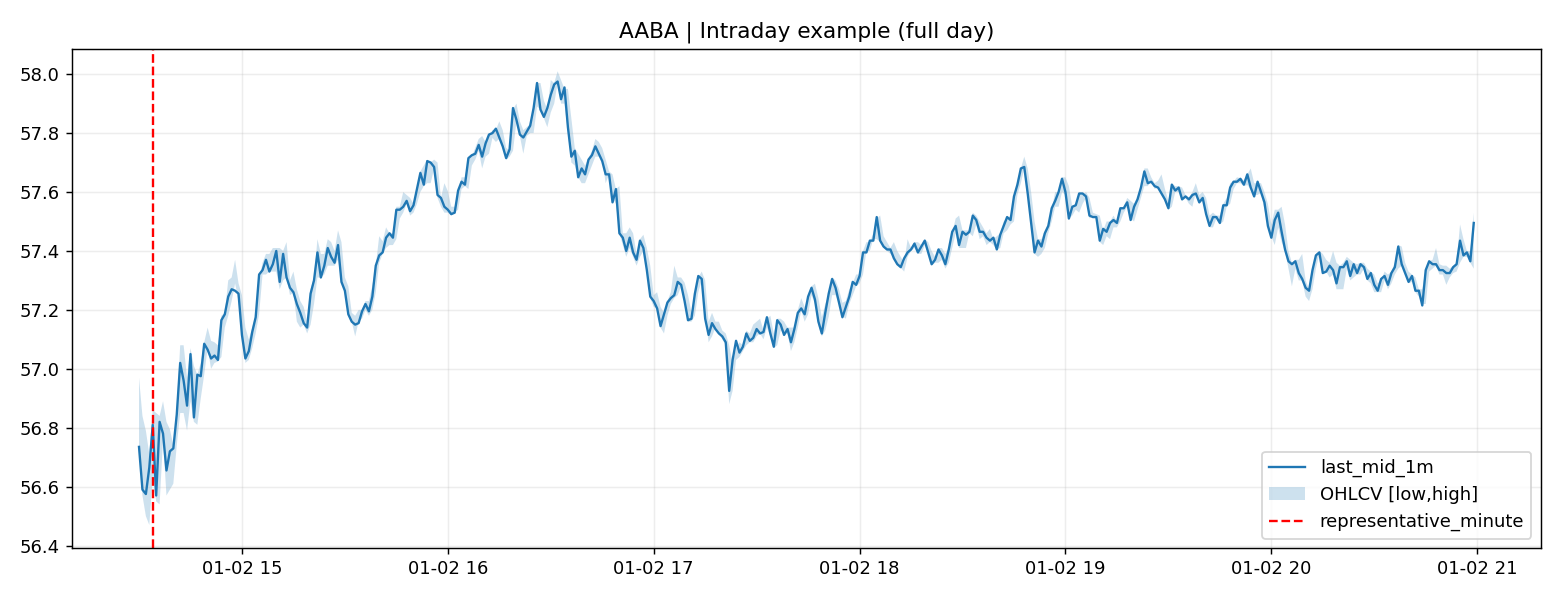

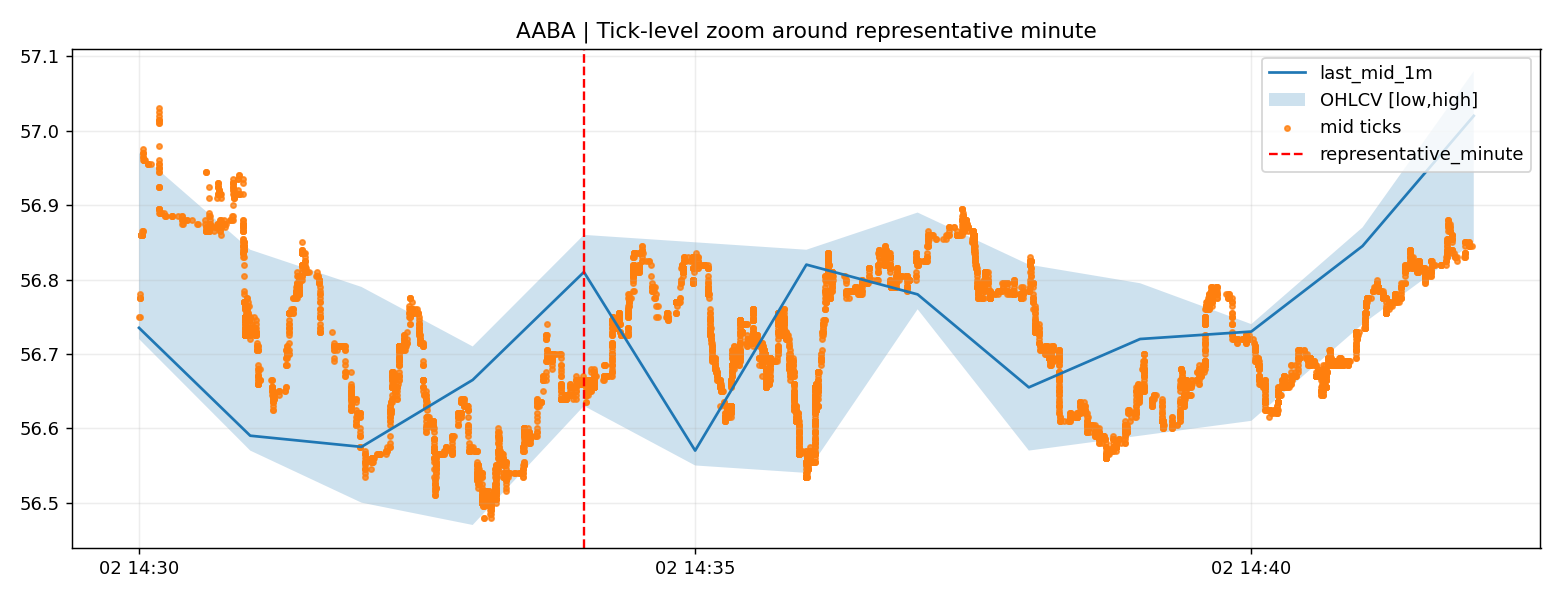

### CRMD | 2019-02-14 | rep_minute=2019-02-14 14:30:00 | abs_err=8.525000

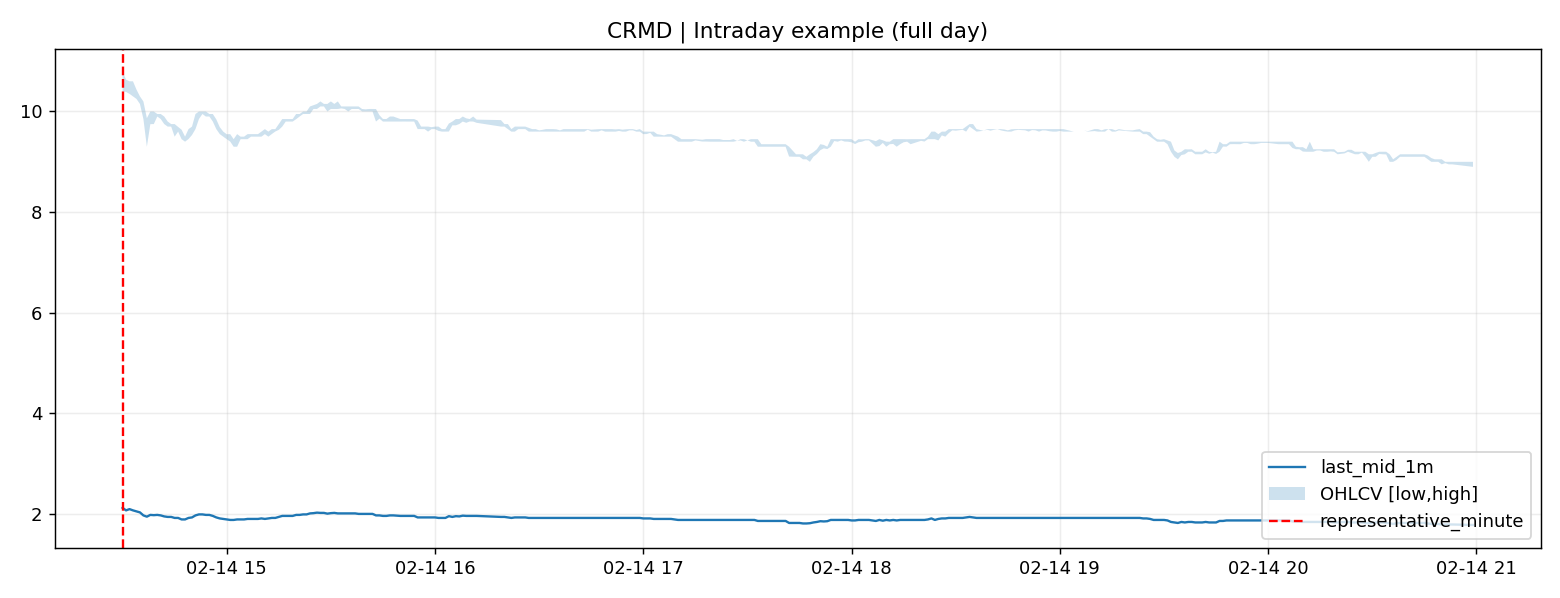

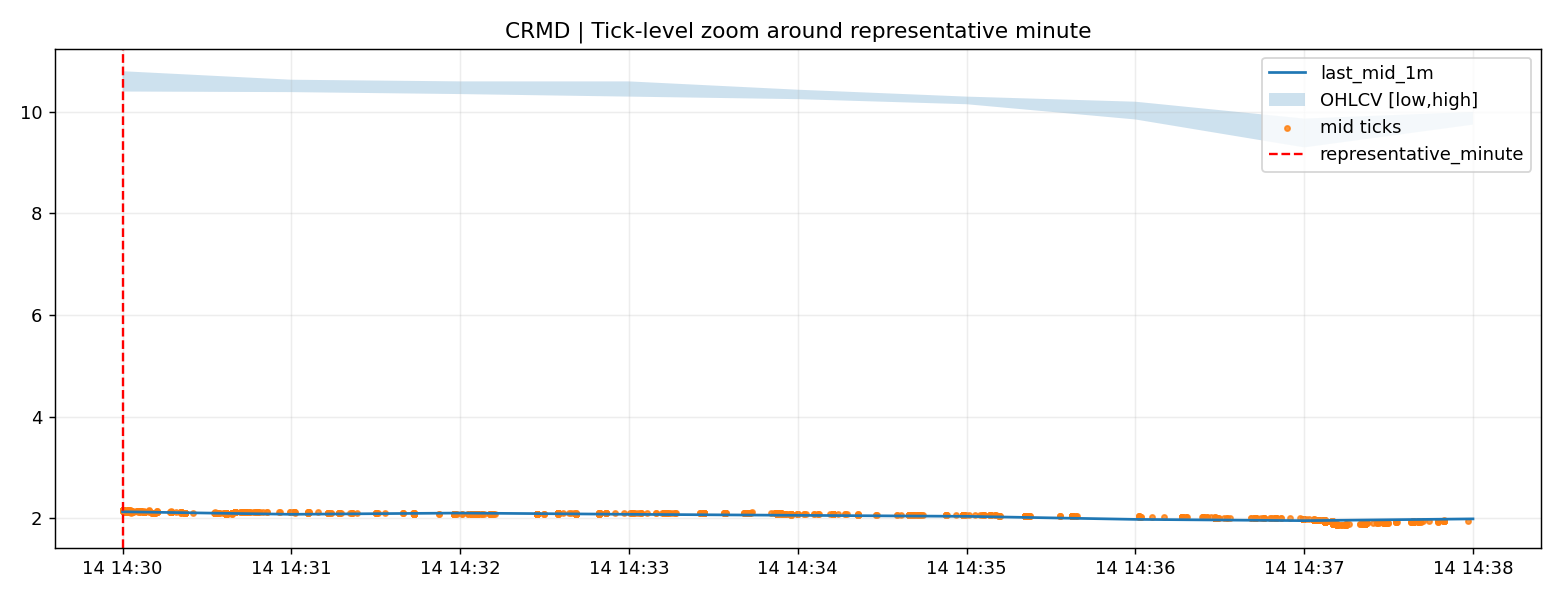

In [29]:
# PASO 8 - GENERAR CHARTS VISUALES OHLCV VS QUOTES (FULL DAY + ZOOM)
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step8_real_charts_ohlcv_vs_quotes.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

## Analisis visual doctrinal de errores OHLCV vs Quotes

### 1) CRMD - Dia completo (`015.png`)
![](../img/015.png)

Lectura analitica:
- Se observan dos regimes totalmente separados: `last_mid_1m` alrededor de `1.9-2.1` y banda `OHLCV [low,high]` alrededor de `9.0-10.8`.
- La separacion es persistente durante toda la sesion, no puntual ni aleatoria.
- Este patron es incompatible con ruido microestructural; corresponde a **error sistematico de escala** (aprox. factor 4-5).

Conclusiones metodologicas:
- El hallazgo valida que el root cause `scale_mismatch` no es artefacto del score agregado.
- No se descarta por volatilidad: la distancia relativa permanece casi constante en el tiempo.
- Decision correcta en politica: `NOT_COMPARABLE` hasta aplicar `factor` validado (auto o manual).

### 2) CRMD - Zoom tick-level (`014.png`)
![](../img/016.png)

Lectura analitica:
- Los puntos `mid ticks` (naranja) y la serie `last_mid_1m` (azul) co-mueven y quedan en el mismo orden de magnitud (`~2.0`).
- La banda OHLCV permanece en `~9.5-10.8`, fuera de escala respecto al flujo tick-level real.
- La linea roja (`representative_minute`) cae en el tramo de mayor discrepancia, y esta discrepancia es estructural, no local.
- Eso implica un desfase de escala multiplicativo (aprox. factor 4-5), no ruido normal.  
Por eso la banda aparece “separada”: no están en la misma unidad/escala efectiva para ese ticker-día.

Conclusiones metodologicas:
- Este grafico localiza *donde* se produce el error y prueba que el problema esta en la escala OHLCV frente a quotes, no en el muestreo de ticks.
- Se justifica la estrategia de remediacion por `candidate_scale_factor` y posterior `recheck` de overlap.

### 3) AABA - Zoom tick-level (`016.png`)
![](../img/014.png)

Lectura analitica:
- `mid ticks`, `last_mid_1m` y banda OHLCV comparten la misma escala (`~56.5-57.1`).
- Existen desviaciones intraminuto, pero la mayor parte del trayecto queda dentro o cerca de la banda.
- No aparece separacion multiplicativa persistente; la dinamica es consistente con microestructura normal (latencia, bid-ask bounce, agregacion por minuto).

Conclusiones metodologicas:
- Este grafico funciona como **control positivo de comparabilidad**: el pipeline puede alinear correctamente cuando no hay fallo de escala.
- Por eso casos como AABA no deben entrar en `scale_mismatch`; sus diferencias son de ruido esperable, no de ruptura estructural.

### 4) Sintesis causal (como los localizamos y por que se descartan/aceptan)
- Localizacion del error: primero por metrica (`p_overlap=0`, ratio de escala anomalo), luego por prueba visual full-day + zoom.
- Criterio de descarte de falso positivo: si ticks y OHLCV co-escalan y la divergencia es local, se clasifica como ruido; no hay `scale_mismatch`.
- Criterio de confirmacion: si la separacion de escala es global, estable y repetible en zoom, se confirma `scale_mismatch` estructural y se remedia con factor/recheck.



## Paso 9 - Integración de decisiones manuales en policy final

Objetivo:
1. tomar el ?ltimo `mvp_policy_mode_table.parquet` (post-autoscale),
2. aplicar `manual_factor`/`keep_not_comparable` de `review_outcome_v1`,
3. producir una tabla final de policy con trazabilidad (`decision_policy_final`, `root_cause_policy_final`).

Regla de integración en esta iteración:
- `manual_factor` -> promover a `FAIL` (recuperable) con `root_cause_policy_final = scale_manual_recheck` y factor manual adjunto.
- `keep_not_comparable` -> conservar `NOT_COMPARABLE` tal como está.



In [30]:
# PASO 9 - APPLY MANUAL REVIEW TO FINAL POLICY
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step9_manual_policy_integration.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 9 - MANUAL POLICY INTEGRATION ===
source_policy: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260224_140714_mvp_03_06_alignment_massive_v2\mvp_policy_mode_table.parquet
source_reviewed_table: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\scale_mismatch_diagnostics\step4_scale_mismatch_plan_20260224T134242Z\manual_review\review_outcome_v1\manual_review_decision_table_reviewed_v1.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\final_policy\step9_manual_integration_20260226T105229Z

[Decision BEFORE]
shape: (4, 2)
┌─────────────────┬─────┐
│ decision_policy ┆ n   │
│ ---             ┆ --- │
│ str             ┆ u32 │
╞═════════════════╪═════╡
│ FAIL            ┆ 514 │
│ GO              ┆ 239 │
│ NOT_COMPARABLE  ┆ 14  │
│ WARN            ┆ 381 │
└─────────────────┴─────┘

[Decision AFTER]
shape: (4, 2)
┌───────────────────────┬─────┐
│ decision_policy_final ┆ n   │
│ ---                

### Explicación del Paso 9 - Integración de decisiones manuales

Qu? se hizo:
- Se tom? como base el policy más reciente post-autoscale: `20260224_140714_mvp_03_06_alignment_massive_v2/mvp_policy_mode_table.parquet`.
- Se carg? la tabla revisada manualmente: `manual_review_decision_table_reviewed_v1.parquet`.
- Se hizo un `join` por `ticker` para incorporar `reviewer_decision`, `reviewer_manual_factor` y `reviewer_notes` a la tabla de policy.

Regla de integración aplicada en esta iteración:
- Si `reviewer_decision = manual_factor`:
  - `decision_policy_final = FAIL` (fallo recuperable, no bloqueo estructural),
  - `root_cause_policy_final = scale_manual_recheck`,
  - `effective_scale_factor = reviewer_manual_factor`.
- Si `reviewer_decision = keep_not_comparable`:
  - se conserva el estado original (`decision_policy`, `root_cause_policy`),
  - no se fuerza remediación automática.

Por qu? esta decisión es correcta:
- Los casos `manual_factor` (2 tickers) tienen evidencia suficiente de desajuste de escala tratable y pasan de incertidumbre a acción operativa (`FAIL` recuperable).
- Los casos `keep_not_comparable` (12 tickers) mantienen prudencia: no se degrada la calidad del dataset imponiendo factores débiles.

Resultados observados (before -> after):
- `FAIL`: `514 -> 516` (`+2`)
- `NOT_COMPARABLE`: `14 -> 12` (`-2`)
- `GO`: `239 -> 239` (sin cambio)
- `WARN`: `381 -> 381` (sin cambio)

Lectura técnica:
- El paso 9 no altera el núcleo de calidad del universo (`GO/WARN`) y solo reclasifica 2 casos frontera con criterio explícito y trazable.
- Se reduce el residual de no comparabilidad estructural y se prepara una política final más accionable para materialización de universos.

Trazabilidad generada:
- Tabla final: `mvp_policy_mode_table_final_manual_v1.parquet`.
- Resumen reproducible: `step9_manual_integration_summary.json`.



## Paso 10 - Congelar baseline final (`after_manual`)

Este paso fija el estado final tras integrar decisiones manuales, para comparar formalmente:
- `before_remediation`,
- `after_remediation`,
- `after_autoscale`,
- `after_manual` (nuevo baseline final).



In [31]:
# PASO 10 - FREEZE BASELINE AFTER MANUAL
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step10_baseline_after_manual.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 10 - BASELINE AFTER MANUAL ===
source_final_policy: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\final_policy\step9_manual_integration_20260226T105229Z\mvp_policy_mode_table_final_manual_v1.parquet
out_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\after_manual_20260226T105348Z

[decision counts]
shape: (4, 2)
┌───────────────────────┬─────┐
│ decision_policy_final ┆ n   │
│ ---                   ┆ --- │
│ str                   ┆ u32 │
╞═══════════════════════╪═════╡
│ FAIL                  ┆ 516 │
│ GO                    ┆ 239 │
│ NOT_COMPARABLE        ┆ 12  │
│ WARN                  ┆ 381 │
└───────────────────────┴─────┘

[root cause counts]
shape: (19, 2)
┌────────────────────────────┬─────┐
│ root_cause_policy_final    ┆ n   │
│ ---                        ┆ --- │
│ str                        ┆ u32 │
╞════════════════════════════╪═════╡
│ magnitude                  ┆ 213 │
│ none                       ┆ 239 │
│ point                      ┆ 

## Paso 11 - Qu? significa materializar universos finales

Cuando decimos **materializar universos** nos referimos a convertir la tabla de policy final (por ticker) en listas operativas de tickers para backtest, con reglas explícitas por nivel de riesgo/calidad.

### Objetivo operativo
- Partir de `decision_policy_final` y `root_cause_policy_final`.
- Generar 3 universos listos para usar en experimentos/backtests.
- Dejar trazabilidad completa (reglas, conteos, archivos y fecha).

### Definición propuesta de universos
1. `strict`
- Incluye solo tickers `GO`.
- Uso: baseline de máxima calidad y mínima ambigüedad.

2. `guardrailed`
- Incluye `GO + WARN`.
- Excluye `FAIL` y `NOT_COMPARABLE`.
- Uso: investigación robusta con más cobertura, manteniendo control de riesgo.

3. `exploratory`
- Incluye `GO + WARN + FAIL` (solo fallos recuperables).
- Excluye `NOT_COMPARABLE` estructural.
- Uso: exploración amplia/feature discovery, nunca como universo de producción.

### Qu? entregar? el Paso 11
- Archivos parquet/csv por universo con la lista de tickers.
- Tabla comparativa de tamaños (`n_tickers`) y cobertura relativa de cada universo.
- Manifiesto JSON con reglas exactas aplicadas y fuentes usadas.

### Por qu? este paso es crítico
- Cierra el ciclo de calidad -> decisión -> ejecución de backtest.
- Evita discusiones ambiguas sobre qu? tickers entran en cada corrida.
- Permite comparar resultados de estrategia bajo diferentes niveles de exigencia de datos de forma reproducible.



## Paso 11 - Materialización de universos finales (`strict`, `guardrailed`, `exploratory`)

Este paso genera archivos operativos de tickers a partir de `decision_policy_final` y deja una tabla comparativa final de tamaños.




In [28]:
# PASO 11 - MATERIALIZE FINAL UNIVERSES
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step11_final_universe_materialization.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 11 - FINAL UNIVERSE MATERIALIZATION ===
source_final_policy: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\final_policy\step9_manual_integration_20260224T183126Z\mvp_policy_mode_table_final_manual_v1.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\final_universes\step11_materialized_20260226T105103Z
[universe sizes]
shape: (3, 4)
┌─────────────┬───────────┬────────────────┬─────────────────────────────────┐
│ universe    ┆ n_tickers ┆ share_vs_total ┆ rule                            │
│ ---         ┆ ---       ┆ ---            ┆ ---                             │
│ str         ┆ i64       ┆ f64            ┆ str                             │
╞═════════════╪═══════════╪════════════════╪═════════════════════════════════╡
│ strict      ┆ 239       ┆ 0.208188       ┆ decision_policy_final == GO     │
│ guardrailed ┆ 620       ┆ 0.54007        ┆ decision_policy_final in {GO, … │
│ exploratory ┆ 1136      ┆ 0.989547  

## Investigamos porque el 03 descargata 3628 tikers

**Evidencia consolidada (1148 elegibles / 3629 excluidos)**

Pruebas exactas en notebooks:
1. `03_time_coverage.ipynb` celda `index=78` (RECONVERSION MASIVA V2): implementa prefilter por evidencia real en `TARGET_MONTHS` (`prefilter_rows`, `reason`, `03_universe_prefilter_summary.json`).
2. `03_time_coverage.ipynb` celda `index=79` (`rectification_note_cell78_20260224`): documenta que el bloque previo tenía `n_days=0/NaN` y terminaba en `schema_gap` en 06.
3. `01_dataset_builder.ipynb` celda `index=110` (`c2fce535`): salida `tickers_validos_metricas=1148`, `tickers_sin_metricas=3629`.
4. `02_policy_integration_and_massive_orchestration.ipynb` celda `audit_03_06_code`: valida identidad `n_valid03_finite=1148` y `n_notc_schema=3629`.
5. `02_policy_integration_and_massive_orchestration.ipynb` celda `rerun06_launch_code`: imprime `Universe eligible from 03 size: 1148` y `Universe final intersection size: 1148`.

Artefactos de run que congelan lo mismo:
- `runs/data_quality/03_time_coverage/20260224_103217_massive_v2/03_universe_prefilter_summary.json` -> `n_universe_eligible=1148`, `n_universe_excluded=3629`.
- `runs/backtest/02_policy_integration/schema_gap_diagnostics/audit_03_06_consistency_20260224T093950Z/audit_identity_summary.json` -> `n_valid03_finite=1148`, `n_notc_schema=3629`.




In [32]:
# PASO 12 - DEEP AUDIT DE LOS 3629 EXCLUIDOS (para detectar perdida artificial)
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step12_deep_audit_3629.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 12 - DEEP AUDIT 3629 ===
source_prefilter: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260224_103217_massive_v2\03_universe_prefilter.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step12_deep_audit_3629_20260226T105615Z
n_excluded: 3629
reason_counts: [{'reason_prefilter': 'no_quotes_in_target_months', 'n': 3629}]
n_window_recoverable: 3472
n_no_overlap_any_2019_2025: 157
[q_start_bucket]
shape: (3, 2)
┌───────────────────────────┬──────┐
│ q_start_bucket            ┆ n    │
│ ---                       ┆ ---  │
│ str                       ┆ u32  │
╞═══════════════════════════╪══════╡
│ starts_after_2019         ┆ 3053 │
│ starts_before_2019        ┆ 517  │
│ starts_2019_but_after_M10 ┆ 59   │
└───────────────────────────┴──────┘
[no_overlap gap distribution]
shape: (21, 2)
┌───────────────────────────────┬─────┐
│ year_gap_o_first_minus_q_last ┆ n   │
│ ---                          

## Paso 13 - Qué ocurrió con los 3629, qué ya estaba documentado y cómo lo vamos a corregir

### 1) Qué ocurrió realmente
- En `03` se aplic? un prefilter con ventana fija (`TARGET_MONTHS`, por defecto 2019-01..2019-10).
- Esa ventana dejó fuera `3629` tickers con razón `no_quotes_in_target_months`.
- Después, en `06`, ese bloque se reflejó como masa de `NOT_COMPARABLE/schema_gap` en la etapa previa a la rectificación.

### 2) Qu? ya estaba tratado y documentado (no es nuevo)
- En `03_time_coverage.ipynb` (celda de rectificación) ya se dejó constancia del problema de `n_days=0`/NaN y su impacto.
- En `01_dataset_builder.ipynb` (constancia before/after) ya se dejó trazabilidad formal del cambio 03?06.
- En `02` ya se auditó identidad 03?06 y se confirmó el patrón `1148` vs `3629`.

Conclusión: la hipótesis y la constancia histórica ya existían; lo que faltaba era **cerrar la corrección estructural multi-era** para no perder universo por una ventana fija.

### 3) Hallazgo técnico del deep audit
- Los `3629` no son ?sin datos? en general.
- Mayoritariamente son un problema de ventana temporal fija (gran bloque recuperable con criterio dinámico por ticker).
- Solo una fracción pequeña queda como no recuperable por falta de solape real o continuidad temporal problemática.

### 4) Qu? vamos a hacer ahora (y ejecutar)
- Implementar `03 v3` no monolítico, multi-era (`2004_2018` + `2019_2025`) con separación por capas:
  1. `contract_layer`: rutas/esquema
  2. `evidence_layer`: hechos medibles por ticker
  3. `policy_layer`: reglas (`eligible/manual_review/excluded`) + guardrails
  4. `orchestration_layer`: ejecución/checkpoint/lineage
  5. `diagnostics_layer`: comparativa v2 vs v3 para evidencia en `02`
- Ejecutar el runner v3 para generar nuevo `prefilter` y medir recuperación real del universo.

### 5) Reparto de responsabilidades
- `03`: ejecución técnica (runner modular).
- `02`: evidencia, análisis, decisiones y baseline.





In [33]:
# PASO 13 - EJECUTAR 03 v3 MULTI-ERA Y COMPARAR VS v2
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step13_run_03_v3_multi_era.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 13 - 03 v3 MULTI-ERA (EXECUTED) ===
out_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage_v3\20260226_105711_prefilter_v3_multi_era
[v2 vs v3 eligible]
{'v2_eligible': 1148, 'v3_eligible': 1687, 'delta': 539}
[v3 summary]
{'n_universe_input': 4777, 'n_eligible': 1687, 'n_manual_review': 3090, 'n_excluded': 0}
[top delta buckets]
shape: (6, 6)
┌──────────────┬─────────────┬─────────────┬────────────────────────┬───────────────────────┬──────┐
│ delta_status ┆ eligible_v2 ┆ eligible_v3 ┆ reason_v2              ┆ prefilter_reason      ┆ n    │
│ ---          ┆ ---         ┆ ---         ┆ ---                    ┆ ---                   ┆ ---  │
│ str          ┆ bool        ┆ bool        ┆ str                    ┆ str                   ┆ u32  │
╞══════════════╪═════════════╪═════════════╪════════════════════════╪═══════════════════════╪══════╡
│ same         ┆ false       ┆ false       ┆ no_quotes_in_target_mo ┆ low_overlap_quote_day ┆ 1440 │
│              

### Lectura analítica del resultado de Paso 13 (v2 vs v3)

Qu? mide esta salida:
- Compara el prefilter histórico v2 contra el prefilter v3 multi-era sobre el mismo universo de entrada.
- Separa tres zonas: `eligible` (entra directo), `manual_review/pending_repair` (recuperable con reparación), `excluded` (sin base para comparar).

Resultados observados en esta corrida:
- `v2_eligible`: `1148`
- `v3_eligible`: `1687`
- `delta` (`v3 - v2`): `539`
- `n_universe_input`: `4777`
- `n_eligible` (resumen v3): `1687`
- `n_manual_review` (resumen v3): `3090`
- `n_excluded` (resumen v3): `0`

Derivadas técnicas:
- Si `delta > 0`, v3 está recuperando universo que v2 perdía por ventana fija; esto valida la hipótesis de pérdida artificial.
- El bloque `manual_review/pending_repair` es la cola operativa del Paso 14: no se descarta, se repara con trazabilidad.
- El bloque `excluded` debe quedar pequeño y bien explicado por causa fuerte (`no_overlap` real o continuidad temporal anómala).

Decisión operativa:
- Mantener `03 v3` como nuevo prefilter base para reruns de 06.
- Ejecutar inmediatamente `Paso 14` para convertir parte del bloque recuperable en comparables con estado `PENDING_REPAIR`.




## Paso 14 - Verificación explícita de los 3629 en todo el rango 2004-2025

Objetivo:
- responder de forma inequívoca si los `3629` tienen o no datos comparables en algún mes entre 2004 y 2025,
- separar `recoverable` (con solape quotes+OHLCV) de `no_overlap_real`,
- exportar listas operativas de tickers para la siguiente fase.

Este paso no aplica política nueva: solo congela evidencia estructural de presencia/solape.




In [34]:
# PASO 14 - OVERLAP REAL 2004-2025 SOBRE LOS 3629
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step14_overlap_check_2004_2025.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 14 - OVERLAP CHECK 2004-2025 ===
source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step12_deep_audit_3629_20260226T105615Z\step12_excluded_3629_diagnostics.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step14_overlap_check_2004_2025_20260226T105942Z
[summary]
shape: (2, 2)
┌─────────────────┬───────────┐
│ recovery_class  ┆ n_tickers │
│ ---             ┆ ---       │
│ str             ┆ u32       │
╞═════════════════╪═══════════╡
│ recoverable     ┆ 3472      │
│ no_overlap_real ┆ 157       │
└─────────────────┴───────────┘
recoverable_n: 3472
no_overlap_real_n: 157
Saved:
C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step14_overlap_check_2004_2025_20260226T105942Z\step14_overlap_summary.parquet
C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step14_overlap_check_200

  Resultado explícito de los 3629 (rango completo 2004-2025):

  - recoverable: 3472
  - no_overlap_real: 157

  Celda ejecutada:

  - step14_overlap_2004_2025_code en 02_policy_integration_and_massive_orchestration.ipynb (C:
    \TSIS_Data\v1\backtest_SmallCaps\notebooks\02_backtest\02_policy_integration_and_massive_orchestration.ipynb)

  Artefactos generados:

  - step14_overlap_summary.parquet (C:
    \TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step14_overlap_check_200
    4_2025_20260224T192521Z\step14_overlap_summary.parquet)
  - step14_recoverable_tickers.parquet (C:
    \TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step14_overlap_check_200
    4_2025_20260224T192521Z\step14_recoverable_tickers.parquet)
  - step14_no_overlap_real_tickers.parquet (C:
    \TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step14_overlap_check_200
    4_2025_20260224T192521Z\step14_no_overlap_real_tickers.parquet)
  - step14_overlap_manifest.json (C:
    \TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step14_overlap_check_200
    4_2025_20260224T192521Z\step14_overlap_manifest.json)

  Esto confirma tu sospecha: la gran mayoría no era “sin data”, era pérdida por criterio/ventana.


## Paso 15 - Siguiente paso directo

1. Usar `step14_recoverable_tickers.parquet` (`3472`) como cola `PENDING_REPAIR`.

2. Crear Paso 15 en `02` para:
- etiquetar esos `3472` como `PENDING_REPAIR`,
- generar `repair_queue_v1.parquet` con prioridad,
- separar subgrupos por causa técnica (`window_shift`, `low_overlap_months`, `low_overlap_days`, `continuity_gap`).

3. Ejecutar primer `repair pass` automático sobre el subgrupo más fácil (`window_shift`) y medir cuántos pasan a `eligible`.

4. Re-lanzar `03` con universo `eligible + repaired`.

5. Re-lanzar `06` y comparar contra baseline actual.

Si te parece, implemento ahora mismo Paso 15 (cola + priorización + primer pass) en el notebook y lo dejamos congelado.




## Paso 15 - Cola `PENDING_REPAIR` y primer `repair pass`

Este paso convierte los `3472` recuperables en una cola operativa trazable, los prioriza por causa técnica y ejecuta un primer pase automático sobre `window_shift`.




In [35]:
# PASO 15 - BUILD REPAIR QUEUE V1 + FIRST AUTO PASS (WINDOW_SHIFT)
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step15_repair_queue_v1.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 15 - REPAIR QUEUE V1 ===
recoverable_source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\schema_gap_diagnostics\step14_overlap_check_2004_2025_20260226T105942Z\step14_recoverable_tickers.parquet
v3_prefilter_source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage_v3\20260226_105711_prefilter_v3_multi_era\03_universe_prefilter_v3.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\repair_queue\step15_repair_queue_20260226T110022Z
[repair cause counts]
shape: (3, 3)
┌────────────────────┬─────────────────┬───────────┐
│ repair_cause       ┆ priority_bucket ┆ n_tickers │
│ ---                ┆ ---             ┆ ---       │
│ str                ┆ str             ┆ u32       │
╞════════════════════╪═════════════════╪═══════════╡
│ window_shift       ┆ P1              ┆ 948       │
│ low_overlap_months ┆ P2              ┆ 1139      │
│ low_overlap_days   ┆ P3              ┆ 1385      │
└─────────

### Interpretación de las salidas de Paso 15

Qué representa cada bloque:
- `repair cause counts`: particiona la cola `PENDING_REPAIR` por causa técnica y prioridad operativa.
- `post-repair status counts`: muestra cuántos tickers pasan a `eligible` tras el primer pase automático y cuántos quedan pendientes.

Lectura de los resultados actuales:
- `n_pending_repair = 3472`: tamaño total de la cola recuperable detectada en Paso 14.
- `window_shift (P1) = 948`: casos más fáciles; suelen fallar por ventana temporal fija y se pueden promover con regla automática.
- `low_overlap_months (P2) = 1139`: hay solape, pero insuficiente número de meses; requieren ajuste de criterio o más evidencia.
- `low_overlap_days (P3) = 1385`: hay solape mensual, pero pocos días útiles; requieren reglas de robustez por muestra.

Efecto del primer `repair pass`:
- `eligible = 948`: promoción automática del subgrupo `window_shift`.
- `pending_repair = 2524`: cola residual que no debe descartarse; pasa a remediación de segunda iteración (`P2/P3`).

Derivadas operativas:
- El pase automático ya recupera un bloque material sin degradar control de calidad.
- El siguiente rerun de `03` debe usar `eligible + repaired(948)` para medir impacto real.
- Luego `06` debe reejecutarse y compararse contra baseline para validar que la recuperación mejora cobertura sin inflar falsos comparables.

Trazabilidad:
- `repair_queue_v1.parquet/csv`: estado completo por ticker.
- `step15_first_pass_promoted_tickers.parquet`: universo promovido automáticamente.
- `step15_repair_queue_summary.json`: resumen reproducible de conteos y reglas aplicadas.




## Paso 15B - Evidencia visual de fallos `P2` y `P3` (con selector de ticker)

Objetivo:
- dejar evidencia visual de por qu? ciertos tickers quedan en `low_overlap_months (P2)` o `low_overlap_days (P3)`,
- permitir selección interactiva de ticker (como en `01`) para inspección reproducible.

Qu? muestra el bloque interactivo:
1. resumen técnico del ticker (`overlap_months_total`, `overlap_quote_days_total`, prioridad),
2. gráfico de meses con solape y días de quotes por mes (evidencia estructural de P2/P3),
3. cuando hay día utilizable, chart intradía `last_mid_1m` vs banda `OHLCV [low,high]` + zoom de ticks.





In [37]:
# PASO 15B - WIDGET DE EVIDENCIA VISUAL PARA P2/P3
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step15b_visual_evidence_widget.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

### Paso 15B - Visual evidence widget
Salida de imágenes: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\repair_queue\step15_visual_evidence_20260226T110227Z`

Output()

## Lectura de los graficos 

### Evidencia de por qué esos tickers caen en P2 o P3 dentro de PENDING_REPAIR

- **P2** = falta profundidad en meses comparables.
- **P3** = hay meses, pero faltan días efectivos.
- Ambos casos son reparables con expansión de ventana/criterio, no necesariamente descartables por mala calidad de precio.


**1. low_overlap_months (AACI)**

- En **Evidencia 1** solo aparece 1 mes con solape real (2025-10) y 1 día útil de quotes en ese mes.
- Eso significa: hay comparabilidad técnica mínima, pero insuficiente continuidad temporal para evaluación robusta.
- Por eso es P2: no es “sin datos”, pero tampoco alcanza para decisión estable.

![](../img/018.png)

- En **Evidencia 2**, full-day y zoom muestran que sí existe match intradía entre last_mid_1m y banda OHLCV [low, high]; el problema no es de escala, sino de muestra demasiado corta.

![](../img/017.png)


**2. low_overlap_days (AAC)**

- En **Evidencia 1** sí hay varios meses con solape (9), pero en total solo 11 días útiles.
- Es decir, hay dispersión temporal (meses sueltos), pero poca densidad diaria por mes.
- Por eso es P3: la cobertura mensual existe, pero la muestra por días no alcanza para métricas de calidad confiables.

![](../img/019.png)


- En **Evidencia 2** también se ve coherencia intradía (línea azul, ticks naranjas y banda OHLCV razonablemente
alineados), luego no parece un scale_mismatch estructural.

**Qué es la línea roja (representative_minute) y por qué**

- Es el minuto seleccionado automáticamente como el de mayor `abs_err = |close_ohlcv - last_mid_1m|` dentro del día
elegido.
- Sirve para inspeccionar el “peor punto” local del día.
- Importante: en P2/P3 el bloqueo principal no es ese punto rojo; el bloqueo principal es falta de evidencia
suficiente (meses o días), no una discrepancia de precios estructural.


![](../img/020.png)





## Paso 15C - Histogramas granulares de `P2` y `P3`

Objetivo:
- visualizar en detalle la distribución de evidencia de `low_overlap_months` (`P2`) y `low_overlap_days` (`P3`),
- cuantificar cola problemática y percentiles para priorizar el `repair pass`.



[15C] inicializando...
[15C] queue: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\repair_queue\step15_repair_queue_20260226T110022Z\repair_queue_v1.parquet
[15C] tamaños -> P2=1139, P3=1385


### Paso 15C | input: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\repair_queue\step15_repair_queue_20260226T110022Z\repair_queue_v1.parquet`

group,n,months_min,months_p25,months_p50,months_p75,months_max,days_min,days_p25,days_p50,days_p75,days_max,gap_min,gap_p50,gap_max
str,i64,i64,f64,f64,f64,i64,i64,f64,f64,f64,i64,f64,f64,f64
"""P2""",1139,1,1.0,1.0,2.0,2,1,1.0,2.0,2.0,24,-6.0,-1.0,0.0
"""P3""",1385,3,3.0,5.0,7.0,16,3,5.0,8.0,12.0,19,-6.0,-3.0,0.0


[15C] graficando P2...


#### P2 - histogramas granulares

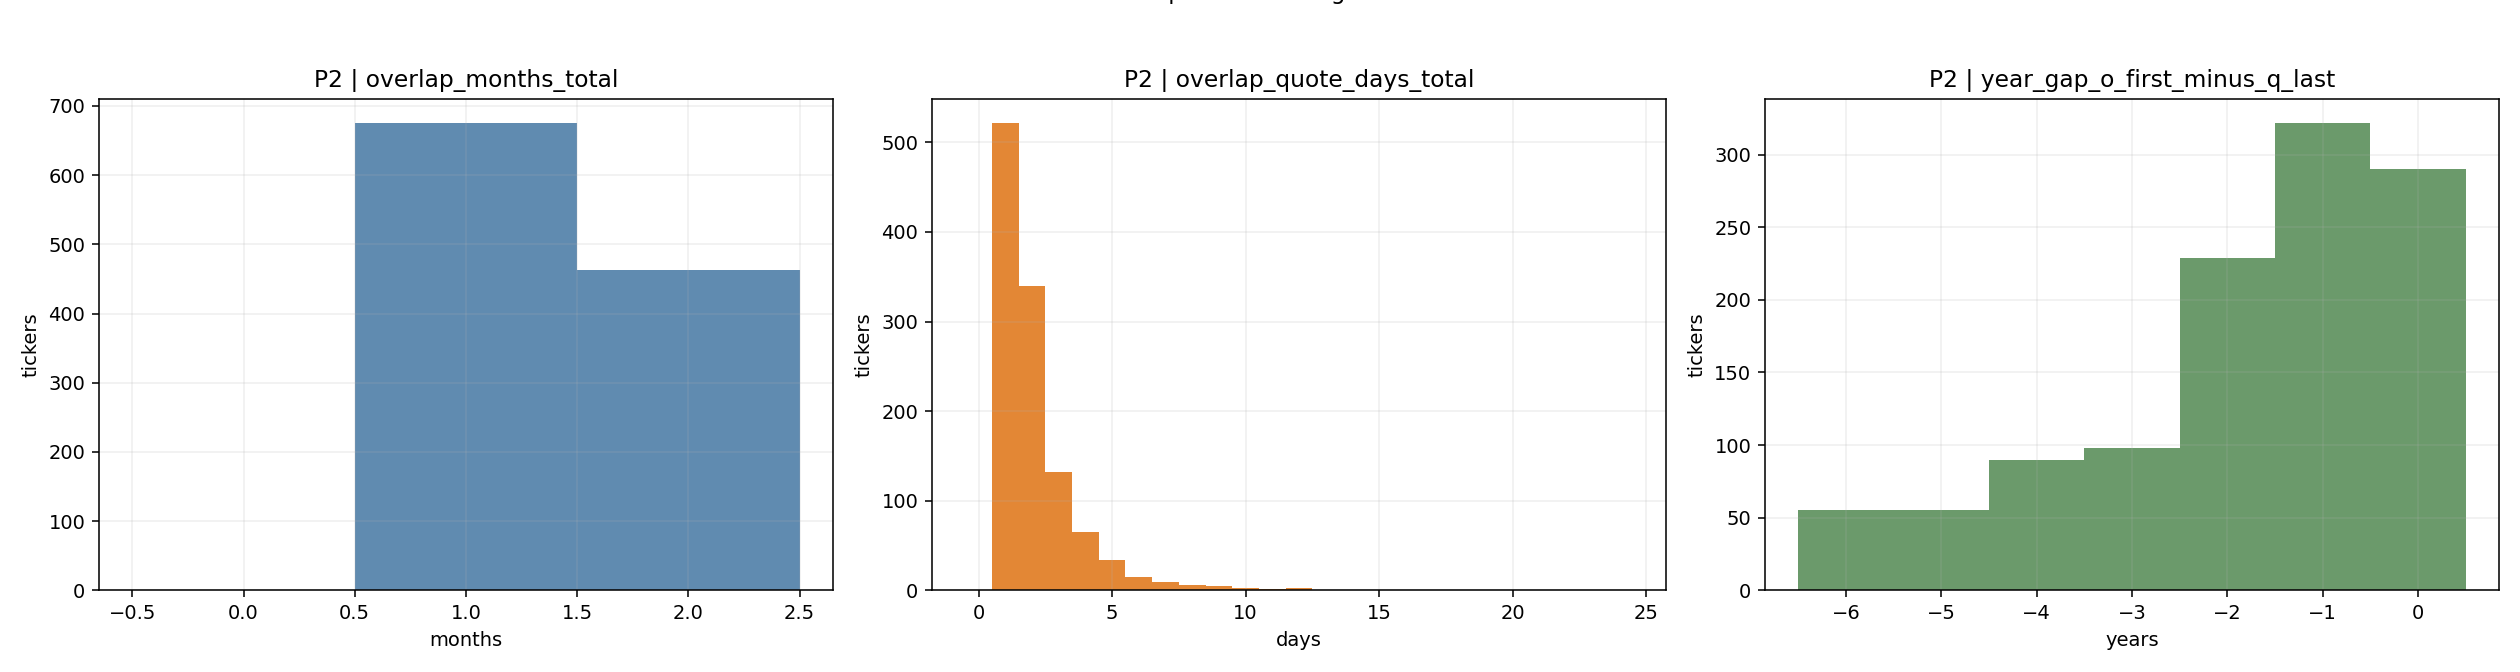

#### P2 - 25 casos más débiles

ticker,repair_cause,priority_bucket,overlap_months_total,overlap_quote_days_total,year_gap_o_first_minus_q_last
str,str,str,i64,i64,i64
"""JAGX""","""low_overlap_months""","""P2""",1,1,-6
"""EFSC""","""low_overlap_months""","""P2""",1,1,-6
"""FGEN""","""low_overlap_months""","""P2""",1,1,-6
"""CHAC""","""low_overlap_months""","""P2""",1,1,-6
"""SCOR""","""low_overlap_months""","""P2""",1,1,-6
…,…,…,…,…,…
"""PIXY""","""low_overlap_months""","""P2""",1,1,-5
"""HSII""","""low_overlap_months""","""P2""",1,1,-5
"""CSWI""","""low_overlap_months""","""P2""",1,1,-5


[15C] graficando P3...


#### P3 - histogramas granulares

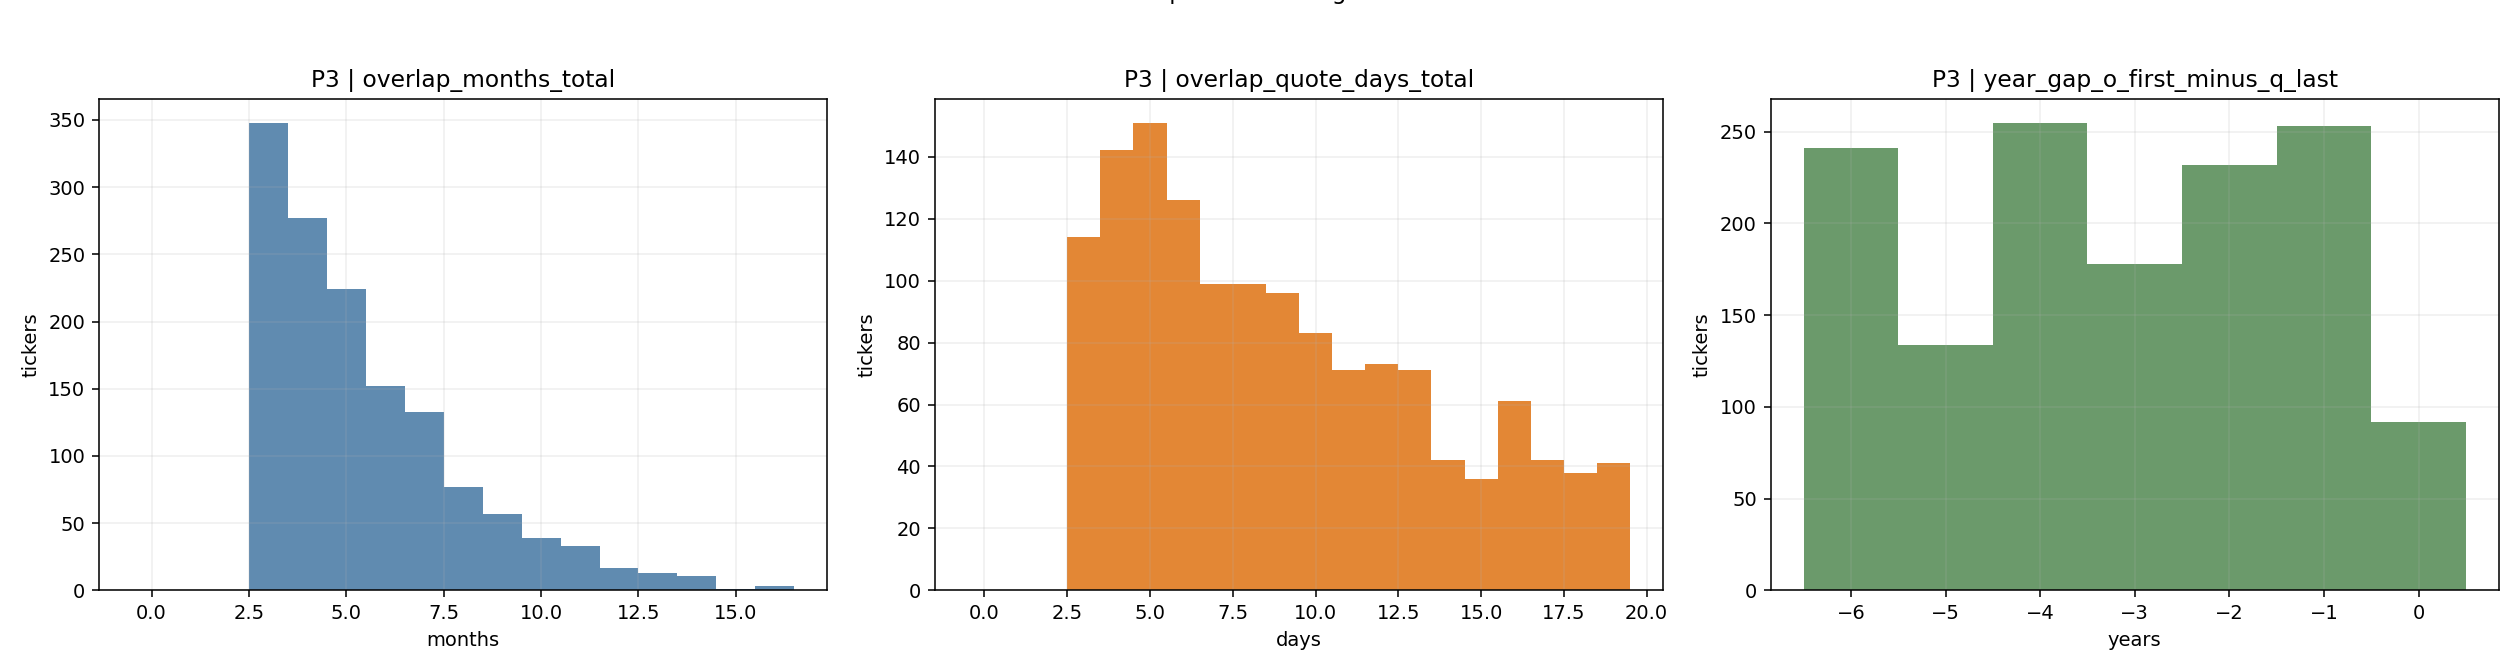

#### P3 - 25 casos más débiles

ticker,repair_cause,priority_bucket,overlap_months_total,overlap_quote_days_total,year_gap_o_first_minus_q_last
str,str,str,i64,i64,i64
"""TAIT""","""low_overlap_days""","""P3""",3,3,-6
"""SRI""","""low_overlap_days""","""P3""",3,3,-6
"""EARN""","""low_overlap_days""","""P3""",3,3,-6
"""BPT""","""low_overlap_days""","""P3""",3,3,-6
"""HAO""","""low_overlap_days""","""P3""",3,3,-6
…,…,…,…,…,…
"""NWN""","""low_overlap_days""","""P3""",3,3,-5
"""OBLG""","""low_overlap_days""","""P3""",3,3,-5
"""NEXA""","""low_overlap_days""","""P3""",3,3,-5


[15C] terminado. salida=C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\repair_queue\step15c_histograms_20260226T110402Z


Guardado: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\repair_queue\step15c_histograms_20260226T110402Z`

In [38]:
# PASO 15C - HISTOGRAMAS GRANULARES P2/P3 + RESUMEN NUMERICO (version estable)
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step15c_granular_histograms.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

## Analizmos salidas

- P2: problema dominante = profundidad temporal insuficiente (meses muy pocos + pocos días).
- P3: problema dominante = densidad diaria insuficiente (meses sí, días no).
- No sugieren principalmente scale_mismatch; sugieren insuficiencia de evidencia comparable y desalineación temporal parcial.
- Por eso la estrategia correcta es PENDING_REPAIR con reparación por subgrupo (window shift, expansión de ventana y reglas de robustez por muestra), no descarte masivo inmediato.

### P2 : tickers con pocos meses solapados (n=1139)

**1. P2 | overlap_months_total**

- Distribución casi binaria entre 1 y 2 meses.
- Pico en 1 mes (la mayoría), segundo bloque en 2 meses.
- Significado: estos tickers no están “sin datos”, pero la comparabilidad temporal es mínima.
- Por qué caen en P2: no alcanzan profundidad temporal para validar estabilidad.

**2. P2 | overlap_quote_days_total**

- Distribución fuertemente sesgada a la izquierda: concentración en 1–3 días, cola hasta ~24.
- Significado: incluso dentro de esos 1–2 meses, hay pocos días efectivos de quotes con overlap real.
- Implicación técnica: alta varianza de métricas; cualquier decisión GO/FAIL sería frágil por tamaño muestral.

**3. P2 | year_gap_o_first_minus_q_last**

- Valores entre aprox. -6 y 0, con masa cerca de -2..0.
- Interpretación del gap (OHLCV first year - quotes last year):
    - 0 o cerca de 0: continuidad razonable.
    - más negativo: desacople temporal entre ventanas de ambas fuentes.
- Significado aquí: mezcla de casos con continuidad aceptable y otros con desalineación histórica moderada.


![](../img/021.png)


### P3: tickers con meses suficientes pero pocos días (n=1385).

**1. P3 | overlap_months_total**

- Rango ~3 a 16 meses, pico alrededor de 3–6 meses, cola larga.
- Significado: sí existe cobertura mensual más amplia que en P2.
- Por qué no son P2: el problema principal no es falta de meses, sino densidad diaria.

**2. P3 | overlap_quote_days_total**

- Rango ~3 a 20 días, concentración ~4–10 días.
- Significado: aunque hay meses en el calendario, pocos días útiles por mes.
- Implicación: comparabilidad “intermitente”; suficiente para detectar señal gruesa, insuficiente para validación
robusta intradía.

**3. P3 | year_gap_o_first_minus_q_last**

- Distribución extendida entre ~-6 y 0, sin pico extremo único.
- Significado: hay heterogeneidad temporal; parte de la muestra tiene continuidad aceptable y parte sufre corte entre eras/fuentes.
- Implicación: necesita reparación por subcausa (no vale una sola regla global).


![](../img/022.png)


ahora que hemos visto todo esto: fíjate el contexto, hemos de crear estrategias y backtestear estrategias de micro
  caps y small caps donde nos aprovechamos de movimientos explisivos y muerte de ese movimiento. Luego hemos de
  alimentar a ML e IA para que nos de alertas y señales probabilisticas de entrada. Son compañías que mientras no se
  dan estos patrones están "muertas" y de repente despiertan. Mi pregunta es ¿estamos analizado exactamente el solape
  de delas de minuto con quotes? pero ¿cierto que si la comparabilidad en P2 es mínima aún así en esa corta etapa de
  solapamiento pueden haber patrones buenos? ¿el solapamiento minimo es porque la compañía se deslistó o realmente hay
  data extra solapamientos y esa data no se solapa? ¿P3 realmente es de mala calidad y no se puede aprovechar ya que si
  hay meses pero los días no hay densidad y eso significa que no son utiles o quizás no vemos el problema reeal? ¿como
  podemos arreglar todo esto para identificar realmente si la data que si solapa podemos usarla realmente para estos
  patrones?


Sí, vais en la dirección correcta, pero ahora toca cambiar el criterio de “calidad global” a “calidad para evento”.

**Respuestas directas**
1. Sí: estáis analizando solape minuto (`OHLCV 1m`) vs quotes/miniticks.
2. Sí: en `P2` puede haber alpha aunque el solape global sea mínimo, si justo cubre ventanas de explosión/reversión.
3. `P2` no implica automáticamente “deslistada”; mezcla causas:
- vida corta real (IPO/SPAC/deslist),
- desalineación temporal entre fuentes,
- faltan tramos en una de las dos fuentes.
4. `P3` no es automáticamente ?mala calidad inútil?; puede ser microcap ilíquida con pocos ticks/día pero patrón válido cuando despierta.

**Qu? está fallando conceptualmente ahora**
- Estabais usando un filtro de cobertura “promedio histórico”.
- Para microcaps, eso penaliza injustamente tickers que solo “viven” en ráfagas (que justo son los que os interesan).

**Estrategia correcta**
1. Redefinir elegibilidad por **eventos**, no por meses globales.
2. Construir un `event_index` (desde quotes): picos de volumen, rango, spread-compression/expansion, velocidad de retorno.
3. Medir comparabilidad solo en ventana del evento (`T-30m ... T+120m`, y `D-2 ... D+2`).
4. Crear **tiers de calidad por evento**:
- `E0`: no comparable en ventana,
- `E1`: comparable mínima,
- `E2`: comparable robusta,
- `E3`: comparable alta.
5. Backtest con pesos por tier (no binario GO/FAIL).
6. ML: entrenar con `sample_weight` por tier + features de fiabilidad (`n_ticks`, spread, gaps, overlap_ratio_event`).

**Cómo arreglar P2/P3 sin perder alpha**
1. `P2`: mantener en `candidate_event_driven`; no excluir por cobertura global.
2. `P3`: separar “ilíquido pero usable en evento” vs “ruido estructural” con reglas intradía:
- mínimo ticks por minuto en ventana,
- estabilidad de timestamp/bucket,
- coherencia `last_mid_1m` dentro de banda OHLCV en % de minutos.
3. Investigar causa real de no-solape con matriz por ticker:
- primer/?ltimo mes con quotes,
- primer/?ltimo mes con OHLCV,
- intersección real,
- huecos internos,
- corporate actions/symbol changes.

**Plan operativo inmediato (siguiente bloque en 02)**
1. Paso 16: `event_index_builder` (quotes-only).
2. Paso 17: `event_overlap_audit` (quotes↔OHLCV solo en ventanas de evento).
3. Paso 18: `event_quality_tiering` (`E0..E3`) + universo final para backtest.
4. Paso 19: backtest v1 ?event-driven? + comparación contra baseline actual.

Si quieres, te preparo ya las celdas de Paso 16-17 en el `02` para congelar evidencia y empezar el rerun correcto.




## Paso 16 - Event Index Builder (quotes-only, orientado a microcaps)

Objetivo:
- construir un ?ndice de eventos por ticker/d?a usando solo quotes,
- priorizar ventanas con potencial de movimiento explosivo y reversi?n,
- dejar un artefacto reproducible para el Paso 17 (`event_overlap_audit`).

Notas operativas:
- el paso usa un l?mite de tickers (`MAX_TICKERS`) para ejecuci?n r?pida y congelaci?n incremental de salidas,
- cuando validemos el flujo, se ejecuta en modo full (`MAX_TICKERS=None`).



In [ ]:
# PASO 16 - LOADER (codigo externo)
from pathlib import Path

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16_event_index_builder.py")
print(f"[Paso 16] Ejecutando: {SCRIPT}")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[16] ticker 1/30: AABA
[16] ticker 25/30: AKBA
[16] ticker 30/30: ALDX

=== STEP 16 - EVENT INDEX BUILDER ===
candidate_universe: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T105435Z\step16_candidate_universe.parquet
event_index: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T105435Z\step16_event_index_quotes_only.parquet
summary: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T105435Z\step16_event_index_summary.parquet
top_events: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T105435Z\step16_top_event_days.parquet
n_rows: 9638
n_tickers: 30
n_event_days: 1574


### Step 16 output dir `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T105435Z`

priority_bucket,n_days,n_tickers,n_event_days,event_score_mean,day_range_p95,abs_return_p95
str,u32,u32,u32,f64,f64,f64
"""P0""",9638,30,1574,53.967695,0.221337,0.124564


ticker,date,priority_bucket,repair_cause,source_group,n_ticks,day_range,day_return,event_score,event_rank_in_ticker
str,str,str,str,str,i64,f64,f64,f64,u32
"""AIV""","""2008-10-16""","""P0""","""none""","""eligible_v3""",71490,7856.51005,7856.432785,77758.177145,1
"""AIV""","""2008-10-16""","""P0""","""none""","""eligible_v3""",71490,7856.51005,7856.432785,77758.177145,1
"""AIV""","""2008-10-15""","""P0""","""none""","""eligible_v3""",53695,7071.933036,7071.833647,69992.531115,2
"""AIV""","""2008-10-15""","""P0""","""none""","""eligible_v3""",53695,7071.933036,7071.833647,69992.531115,2
"""AIV""","""2008-10-14""","""P0""","""none""","""eligible_v3""",75496,6774.262435,6774.198515,67046.971067,3
…,…,…,…,…,…,…,…,…,…
"""ACC""","""2020-03-26""","""P0""","""none""","""eligible_v3""",38627,0.433339,0.388731,14.169088,4
"""ABUS""","""2020-07-23""","""P0""","""none""","""eligible_v3""",208749,1.82716,1.077601,13.748731,1
"""ABUS""","""2020-07-23""","""P0""","""none""","""eligible_v3""",208749,1.82716,1.077601,13.748731,1


## Paso 16B - Widget visual de `is_event_day` (ticker y multi-ticker)

Objetivo:

- visualizar por ticker c?mo se marca `is_event_day`,
- descomponer la causa del disparo (`score`, `range`, `return`),
- comparar r?pidamente varios tickers con un resumen agregado.

**event_day básico**

Para cada ticker y día:

- mid = (bid_price + ask_price) / 2
- day_return = (mid_close - mid_open) / mid_open
- day_range = (mid_max - mid_min) / mid_open

**Normalizaciones por ticker:**

- z_range = (day_range - median(day_range)) / (std(day_range) + 1e-9)
- z_ticks = (n_ticks - median(n_ticks)) / (std(n_ticks) + 1e-9)
- return_scale = abs(day_return) / (median(abs(day_return)) + 1e-9)

**Score:**

- event_score = 0.50*z_range + 0.30*z_ticks + 0.20*return_scale

**Regla de evento:**

- is_event_day = (event_score >= 2.0) OR (day_range >= 0.12) OR (abs(day_return) >= 0.15)


In [40]:
# PASO 16B - LOADER (codigo externo)
from pathlib import Path

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16b_event_day_widget.py")
print(f"[Paso 16B] Ejecutando: {SCRIPT}")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[Paso 16B] Ejecutando: C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16b_event_day_widget.py


### Paso 16B | run: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T192210Z`

Output()

Esa gráfica de 16B no sirve sola para validar pump/dump completo.

16B valida solo:

- detección de días anómalos (is_event_day) por event_score/range/return.

No valida:

- si hubo pump previo,
- ni si hubo dump posterior.

Para eso necesitas 16E/16H/16I/16J (lifecycle + régimen).
En tu imagen de ACCO, 16B solo dice “hubo días calientes”; no demuestra ciclo pump→dump.

Si quieres revisar “qué tan bien puntúa” visualmente, usa esta secuencia:

1. 16B: detectar día ancla.
2. 16H: marcar backside_start.
3. 16J: ver régimen final (pump_then_dump_confirmed, shakeout, continuation).

Eso sí responde si estamos finos para pump/dump.

## Paso 16C - QA visual de m?tricas (`n_ticks`, `day_return`, `day_range`)

Ejecuta el script externo para validar visualmente que el ?ndice de Paso 16 coincide con recomputaci?n desde quotes.


### Paso 16C QA Widget | run: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T192210Z`

Output()

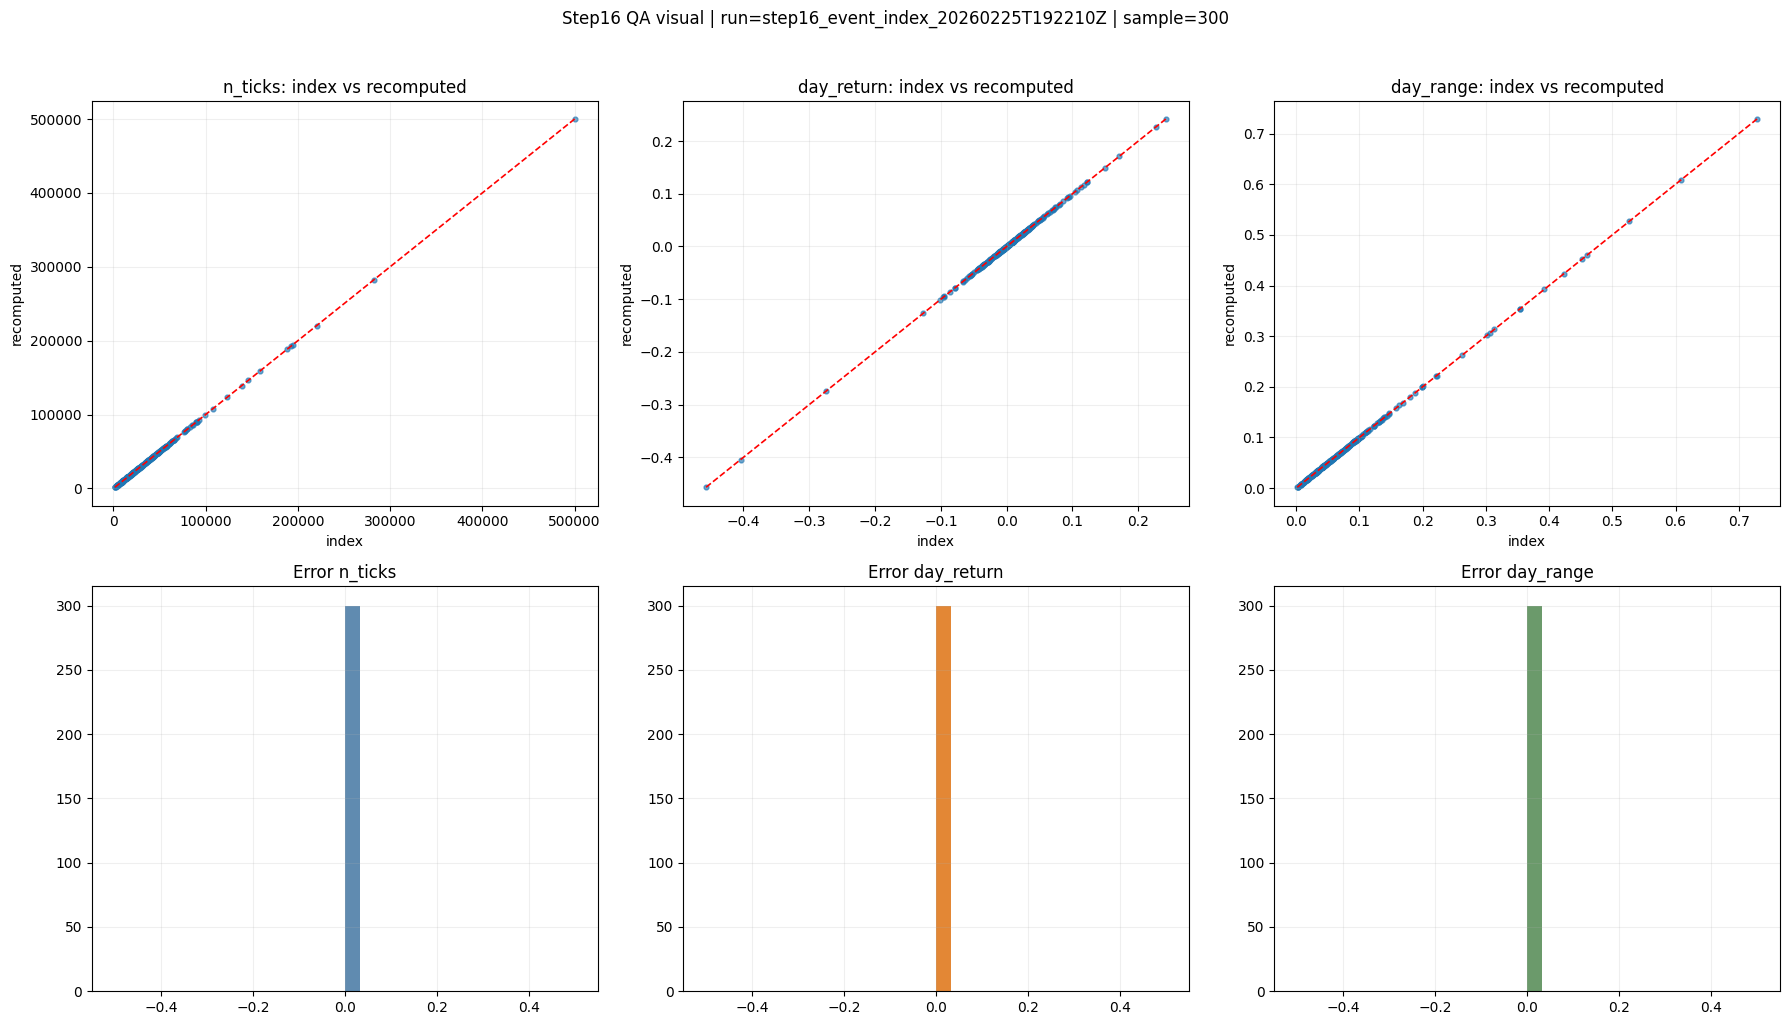

In [43]:
# PASO 16C - LOADER (codigo externo)
from pathlib import Path

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16c_qa_visual_widget_modes.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())


**(step16c QA)**: valida que los cálculos del Paso 16 están bien construidos desde quotes.
      - Scatter sobre línea diagonal = valor en índice vs valor recalculado.
      - Histogramas de error centrados en 0 = diferencias nulas.
      - Traducción: n_ticks, day_return y day_range están correctamente calculados; no es un bug de fórmula/código.

## Paso 16E - Score de ciclo completo (`score_explosion` + `score_decay`)

Paso 16E (lifecycle: explosión + decay)

Explosión:

- ret_pos = max(day_return, 0)
- ret_pos_scale = ret_pos / median(ret_pos>0)
- score_explosion = 0.45*z_range + 0.35*z_ticks + 0.20*ret_pos_scale

Decay (futuro):

- fwd_ret_3d = (1+r1)*(1+r2)*(1+r3) - 1  (r1/r2/r3 = returns t+1..t+3)
- neg_fwd3d = max(-fwd_ret_3d, 0)
- neg_fwd3d_scale = neg_fwd3d / median(neg_fwd3d>0)
- drawdown_proxy = max(-min(r1,r2,r3), 0)
- drawdown_scale = drawdown_proxy / median(drawdown_proxy>0)
- ticks_drop_1d = max((n_ticks_t - n_ticks_{t+1}) / n_ticks_t, 0)
- score_decay = 0.50*neg_fwd3d_scale + 0.30*drawdown_scale + 0.20*ticks_drop_1d

Lifecycle:

- event_lifecycle_score = 0.6*score_explosion + 0.4*score_decay
- is_explosion_day = (score_explosion >= 2.0) OR (day_range >= 0.12) OR (day_return >= 0.10)
- is_decay_followup = (score_decay >= 1.2)
- is_lifecycle_event = is_explosion_day AND is_decay_followup AND (event_lifecycle_score >= 2.8)

Objetivo: puntuar evento completo (explosi?n y muerte/reversi?n posterior), no solo el d?a aislado.

16E no es “del widget 16B”, pero sí usa su misma base de datos.

- 16B = visualiza señales de event_day (día aislado) desde step16_event_index.
- 16E = toma ese step16_event_index y, por ticker, calcula secuencia temporal para puntuar ciclo completo:
    - score_explosion (hoy),
    - score_decay (días futuros t+1..t+3),
    - event_lifecycle_score = 0.6*explosion + 0.4*decay.

O sea:

- Sí es referente al ticker (normaliza y evalúa dentro de cada ticker).
- Usa métricas que vienen del paso 16 base (z_range, z_ticks, day_return, n_ticks) y añade futuro (fwd_ret_3d,
drawdown, caída de ticks).

Para vuestro objetivo (recuperar P2/P3 en modo pasivo y granular), lo correcto es:

1. Ejecutar 16 sobre universo amplio (no solo MAX_TICKERS=30).
2. Calcular 16E/16I para todos.
3. Medir finura por grupo P2/P3:
    - precision de eventos (muestras revisadas),
    - % eventos con dump confirmado,
    - estabilidad por estrato de liquidez.
4. Promover por event_quality_gate (no por cobertura global).



para pasar de “día raro” a “ciclo completo”.

16E sí evalúa decay explícitamente, así:

- Mira el futuro del día ancla (t+1, t+2, t+3).
- Calcula caída acumulada futura:
    - fwd_ret_3d = (1+r1)(1+r2)(1+r3)-1
    - neg_fwd3d = max(-fwd_ret_3d, 0)
- Calcula proxy de drawdown en esos 3 días:
    - drawdown_proxy = max(-min(r1,r2,r3), 0)
- Mide pérdida de actividad:
    - ticks_drop_1d = max((n_ticks_t - n_ticks_{t+1}) / n_ticks_t, 0)

Con eso:

- score_decay = 0.50*neg_fwd3d_scale + 0.30*drawdown_scale + 0.20*ticks_drop_1d
- Y combina con explosión:
    - event_lifecycle_score = 0.6*score_explosion + 0.4*score_decay

Luego marca evento lifecycle solo si:

- hay explosión,
- hay decay suficiente,
- y supera umbral global (2.8).

O sea: sí, decays se evalúan y pesan en la decisión final.

16E no mide solo “sube y baja”. Mide un patrón más estructurado:

- Explosión: rango anómalo + actividad anómala + retorno positivo.
- Decay: caída futura (t+1..t+3) + drawdown + pérdida de ticks.

O sea, combina magnitud + microestructura + secuencia temporal, no solo dirección del precio.

In [46]:
# PASO 16E - LOADER (codigo externo)
from pathlib import Path

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16e_event_lifecycle_scores.py")
print(f"[Paso 16E] Ejecutando: {SCRIPT}")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[Paso 16E] Ejecutando: C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16e_event_lifecycle_scores.py
=== STEP 16E - EVENT LIFECYCLE SCORING ===
input_step16: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T192210Z\step16_event_index_quotes_only.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T120022Z
output_scores: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T120022Z\step16e_event_lifecycle_scores.parquet
summary: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T120022Z\step16e_summary.parquet
top_lifecycle: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T120022Z\step16e_top_lifecycle_eve

### Step 16E output dir
`C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T120022Z`

,priority_bucket,n_days,n_tickers,n_explosion_days,n_decay_days,n_lifecycle_events,score_explosion_mean,score_decay_mean,lifecycle_score_p95
0,P0,9638,30,1542,1787,102,60.757014,0.761561,1.808852


,ticker,date,priority_bucket,source_group,day_return,day_range,n_ticks,score_explosion,score_decay,event_lifecycle_score,is_explosion_day,is_decay_followup,is_lifecycle_event
0,AIV,2008-08-01,P0,eligible_v3,4303.761905,4303.798370,42479,48175.601309,2.748661,28906.460250,True,True,True
1,ACC,2020-03-13,P0,eligible_v3,0.233242,0.280082,21852,2.886988,30.997712,14.131278,True,True,True
2,ACC,2020-03-16,P0,eligible_v3,-0.229718,0.817236,20734,1.643650,26.701149,11.666650,True,True,True
3,ACC,2020-03-13,P0,eligible_v3,0.233242,0.280082,21852,2.886988,22.696142,10.810650,True,True,True
4,ABUS,2020-07-23,P0,eligible_v3,1.077601,1.827160,208749,13.380612,5.807805,10.351489,True,True,True
5,ABUS,2020-07-23,P0,eligible_v3,1.077601,1.827160,208749,13.380612,2.157231,8.891260,True,True,True
6,AKBA,2022-03-30,P0,eligible_v3,-0.601453,0.675545,37457,5.148398,12.772584,8.198072,True,True,True
7,ACHC,2020-03-17,P0,eligible_v3,-0.832166,0.835987,17058,2.278806,14.687528,7.242295,True,True,True
8,ACHC,2020-03-20,P0,eligible_v3,-0.827778,0.850980,30765,2.604891,14.099754,7.202836,True,True,True
9,ACHC,2020-03-17,P0,eligible_v3,-0.832166,0.835987,17058,2.278806,14.501933,7.168057,True,True,True




## 3) ¿Estamos separando pump vs dump?

Sí, en Paso 16I ya se separa en regímenes:

- pump_then_dump_confirmed
- pump_then_shakeout
- pump_continuation

Usando métricas post-evento (ventana ~10 días), sobre todo:

- dd10 (drawdown 10d),
- dd5,
- rebound_ratio_10d,
- pendiente (slope10).



Ahora mismo estáis recuperando tickers por patrón explosión -> decay, que es correcto para empezar. 

Para micro/small caps, si queréis robustez real de backtest/ML, debéis añadir más patrones/contexto:

**1. Gap regime** premarket gap %, open vs prev close, gap fill/no fill, time-to-fail.  
**2. Liquidity/participation** RVOL intradía, ticks por minuto, spread, deterioro de liquidez.  
**3. Borrow/short-pressure (si tenéis data)** fee, disponibilidad, cambios bruscos de borrow, SSR context.  
**4. Structure/microestructura** rangos por tramo horario, ruptura y reclaim de niveles (HOD/LOD), VWAP distance/reclaim.  
**5. Catalyst/context** earnings/news/filings/day-of-week/session regime.  

Tu imagen (pump inicial, distribución lateral, nuevo impulso con RVOL) justo muestra que no todo es “pump and dump limpio”: hay continuation, re-acceleration, failed dump, etc.

**Conclusión crítica:**

- Sí: lo actual está bien como base de recuperación P2/P3.
- No: no basta para producción ni para ML final.
- Siguiente paso correcto: pasar de un único patrón a un catálogo de regímenes (dump_confirmed, continuation, re-
  acceleration, chop/no-edge) y etiquetar así para backtest/ML.

[Paso 16G] Ejecutando: C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16g_event_score_decomposition.py


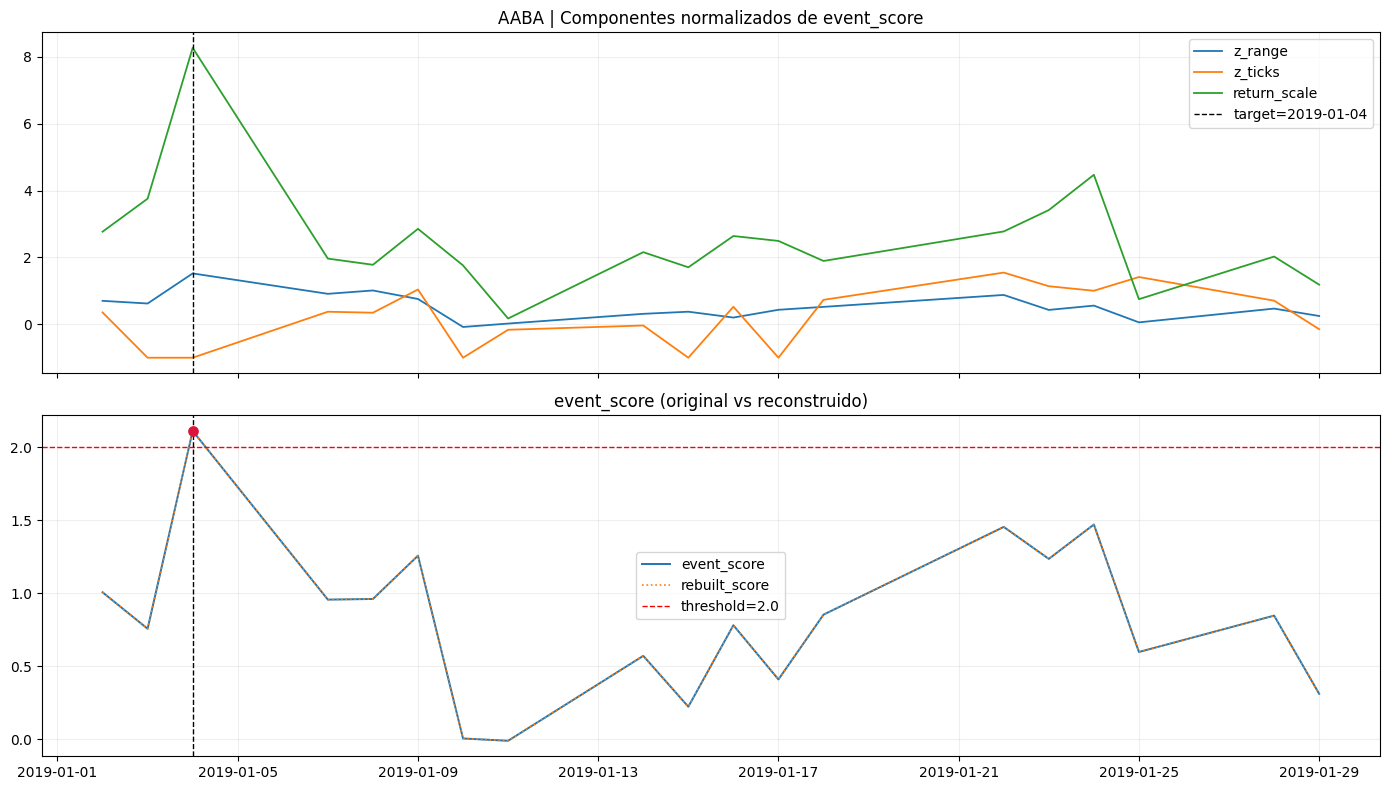

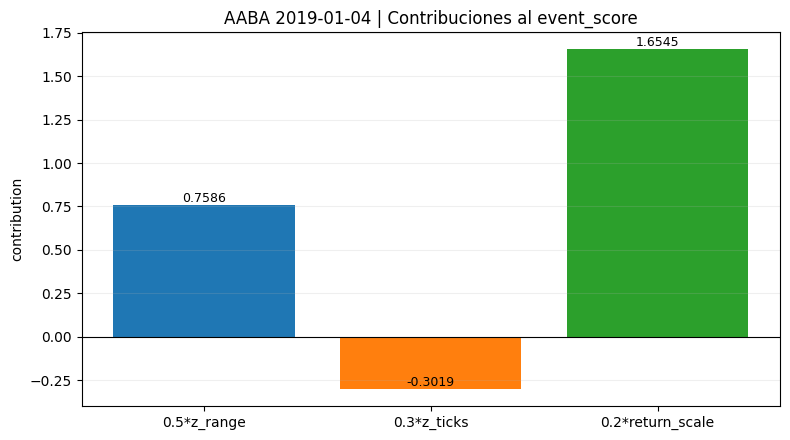

=== STEP 16G - EVENT_SCORE DECOMPOSITION ===
run_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T192210Z
ticker/date: AABA 2019-01-04
z_range=1.517201, z_ticks=-1.006448, return_scale=8.272350
c_range=0.758601, c_ticks=-0.301934, c_ret=1.654470
event_score(original)=2.111136
event_score(rebuilt) =2.111136
delta=0.000000000000
is_event_day=True (threshold=2.0)


In [48]:
# PASO 16G - Descomposición de event_score (caso fijo)
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16g_event_score_decomposition.py")
print(f"[Paso 16G] Ejecutando: {SCRIPT}")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

In [5]:
# PASO 16G-W - Descomposición de event_score con widget
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16g_event_score_decomposition_widget.py")
print(f"[Paso 16G-W] Ejecutando: {SCRIPT}")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[Paso 16G-W] Ejecutando: C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16g_event_score_decomposition_widget.py


### Paso 16G-W | run `step16_event_index_20260225T192210Z`

Output()

In [6]:
# PASO 16H - Backside dump widget
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16h_backside_dump_widget.py")
print(f"[Paso 16H] Ejecutando: {SCRIPT}")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[Paso 16H] Ejecutando: C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16h_backside_dump_widget.py


### Paso 16H | run `step16e_event_lifecycle_20260226T120022Z`

Output()

In [7]:
# PASO 16I - Clasificador de régimen pump/dump
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16i_pump_dump_regime_classifier.py")
print(f"[Paso 16I] Ejecutando: {SCRIPT}")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[Paso 16I] Ejecutando: C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16i_pump_dump_regime_classifier.py
=== STEP 16I - PUMP/DUMP REGIME CLASSIFIER ===
input_step16e: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T120022Z\step16e_event_lifecycle_scores.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T182645Z
labels: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T182645Z\step16i_event_regime_labels.parquet
summary: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T182645Z\step16i_summary.parquet
joined: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T182645Z\step16i_event_regime_joined.par

### Step 16I output dir
`C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T182645Z`

,regime_label,n_events,n_tickers,lifecycle_score_mean,dd10_median,rebound_median
0,pump_then_shakeout,59,16,4.996468,-0.442116,1.048457
1,pump_then_dump_confirmed,31,8,4.945013,-0.879304,0.381397
2,pump_continuation,12,10,2412.667259,0.009162,5.983616


,ticker,event_date,priority_bucket,source_group,event_lifecycle_score,score_explosion,score_decay,dd5,dd10,rebound_ratio_10d,slope10,regime_label
0,AIV,2008-08-01 00:00:00,P0,eligible_v3,28906.460250,48175.601309,2.748661,3387.522518,3246.237588,0.325769,-2.326108e+05,pump_continuation
1,ACC,2020-03-13 00:00:00,P0,eligible_v3,14.131278,2.886988,30.997712,-0.392610,-0.392610,2.965247,2.306850e-01,pump_then_shakeout
2,ACC,2020-03-16 00:00:00,P0,eligible_v3,11.666650,1.643650,26.701149,-0.360605,-0.360605,5.726800,6.561932e-01,pump_then_shakeout
3,ACC,2020-03-13 00:00:00,P0,eligible_v3,10.810650,2.886988,22.696142,-0.392610,-0.392610,2.965247,2.306850e-01,pump_then_shakeout
4,ABUS,2020-07-23 00:00:00,P0,eligible_v3,10.351489,13.380612,5.807805,-0.100899,-0.154119,7.991989,-7.223845e-01,pump_then_shakeout
5,ABUS,2020-07-23 00:00:00,P0,eligible_v3,8.891260,13.380612,2.157231,-0.100899,-0.154119,7.991989,-7.223845e-01,pump_then_shakeout
6,AKBA,2022-03-30 00:00:00,P0,eligible_v3,8.198072,5.148398,12.772584,-0.614614,-0.650877,0.094410,-8.020157e-03,pump_then_dump_confirmed
7,ACHC,2020-03-17 00:00:00,P0,eligible_v3,7.242295,2.278806,14.687528,-0.996422,-0.999928,0.167775,-4.246660e-05,pump_then_dump_confirmed
8,ACHC,2020-03-20 00:00:00,P0,eligible_v3,7.202836,2.604891,14.099754,-0.997208,-0.998257,0.170777,-2.238274e-06,pump_then_dump_confirmed
9,ACHC,2020-03-17 00:00:00,P0,eligible_v3,7.168057,2.278806,14.501933,-0.996422,-0.999928,0.167775,-4.246660e-05,pump_then_dump_confirmed


In [8]:
# PASO 16J - Visual widget por régimen
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16j_regime_visual_widget.py")
print(f"[Paso 16J] Ejecutando: {SCRIPT}")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[Paso 16J] Ejecutando: C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16j_regime_visual_widget.py


### Paso 16J | life_run=`step16e_event_lifecycle_20260226T120022Z` | regime_run=`step16i_regime_20260226T182645Z`

Output()

[Paso 16K] Ejecutando: C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16k_split_vs_extreme_audit.py
=== STEP 16K - SPLITS VS EXTREMES AUDIT ===
splits_source: C:\TSIS_Data\data\additional\corporate_actions\splits.parquet
event_source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T192210Z\step16_event_index_quotes_only.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\outlier_audit\step16k_split_extreme_20260226T182646Z
thresholds -> TH_RET=0.498543, TH_RNG=0.691734, TH_SCR=9.515669
n_event_rows: 9638
n_extremes: 102
n_split_related: 0
n_non_split_likely_error: 0
n_non_split_candidate_event: 102
global_chart: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\outlier_audit\step16k_split_extreme_20260226T182646Z\step16k_global_histograms.png
candidate_charts_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integrati

### Step 16K output dir
`C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\outlier_audit\step16k_split_extreme_20260226T182646Z`

#### Histograma global (splits vs extremos no-split)

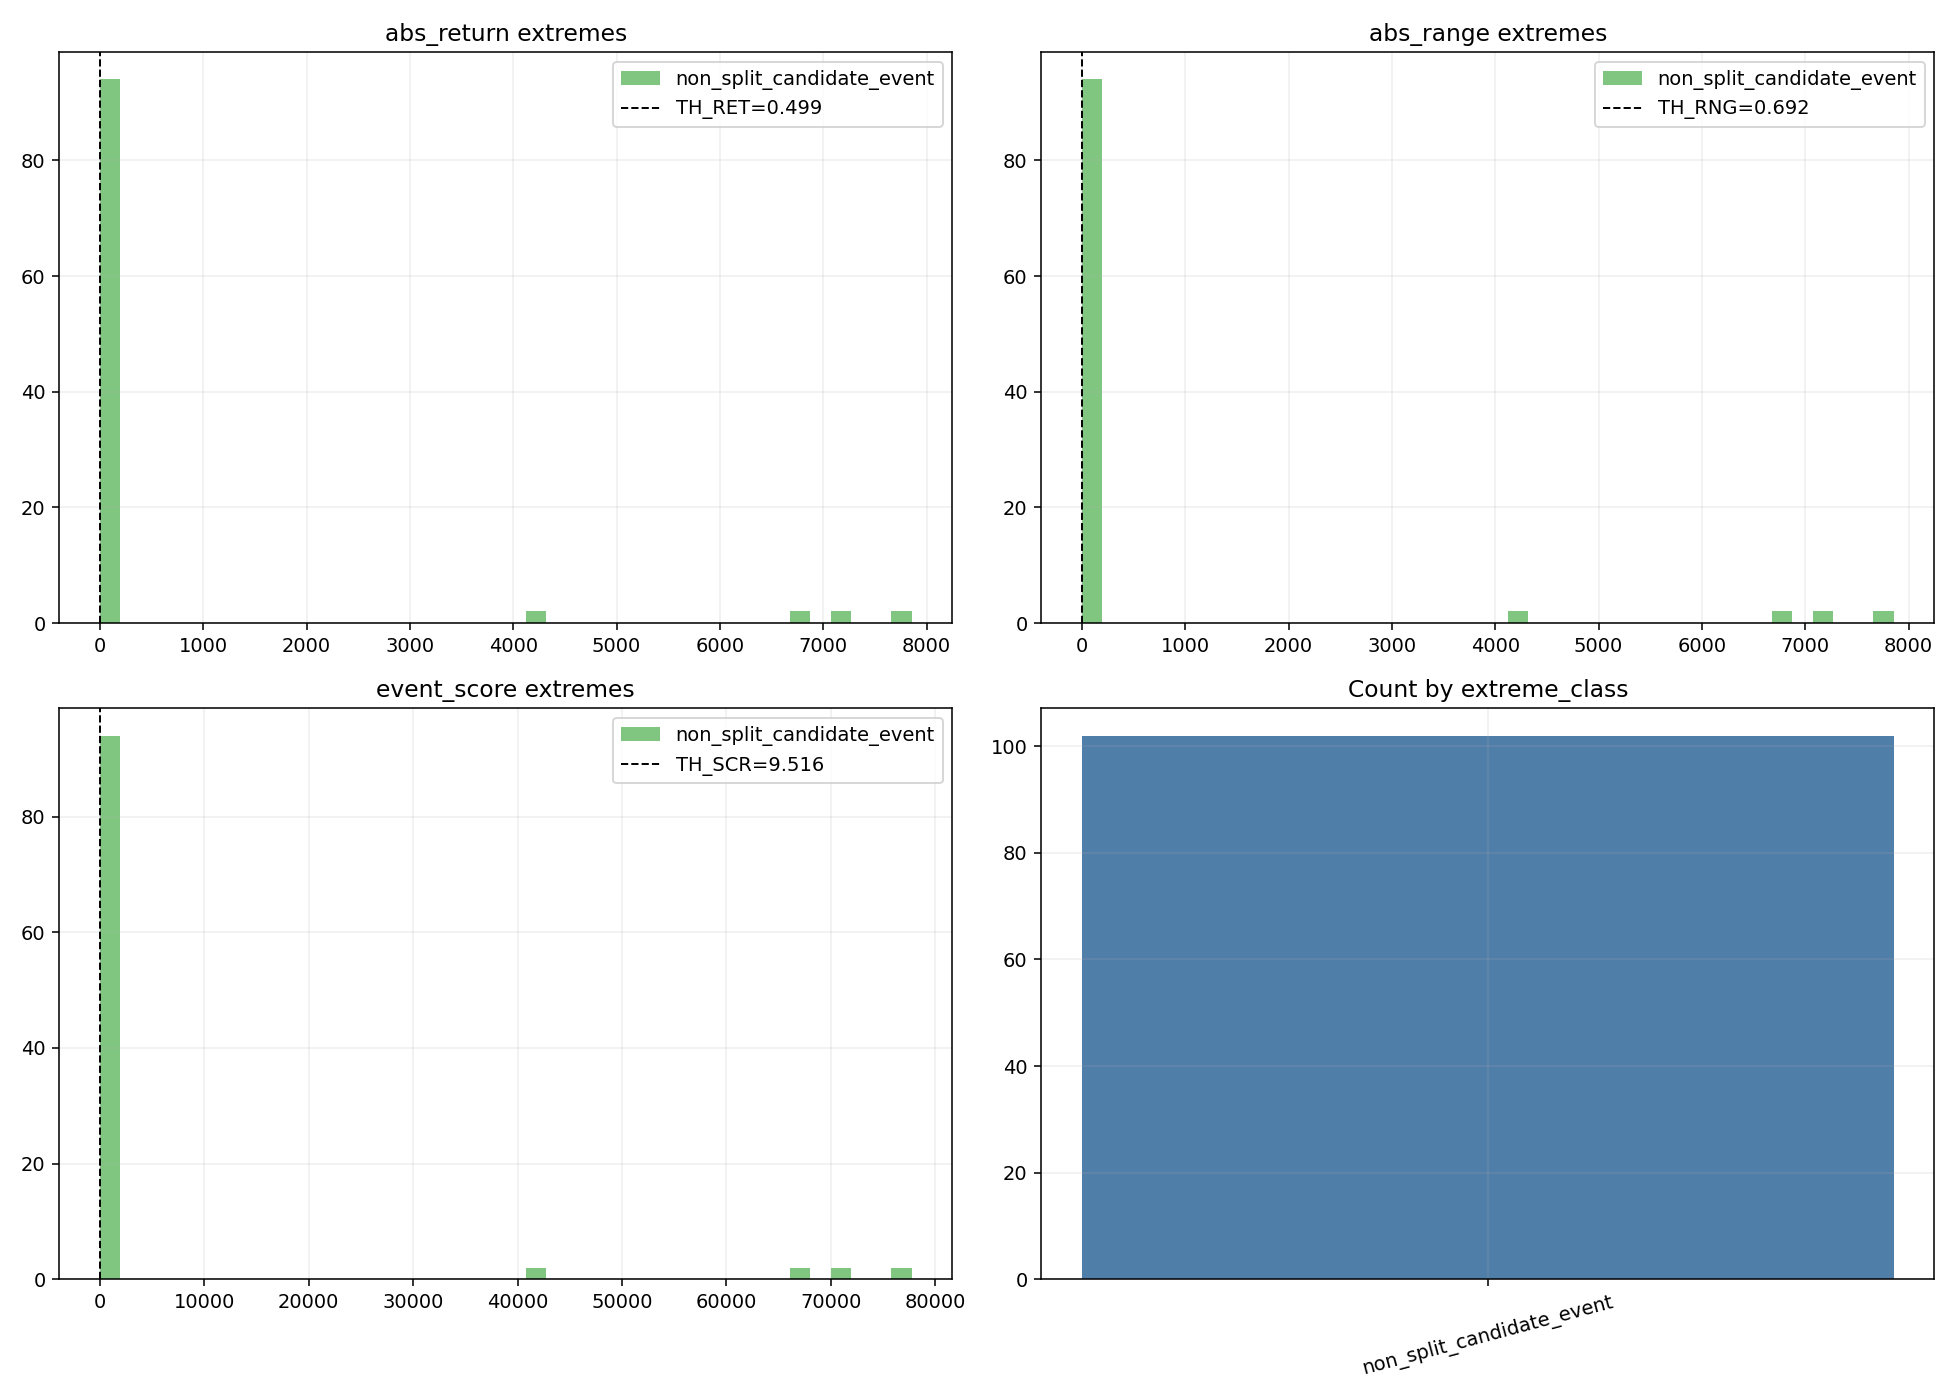

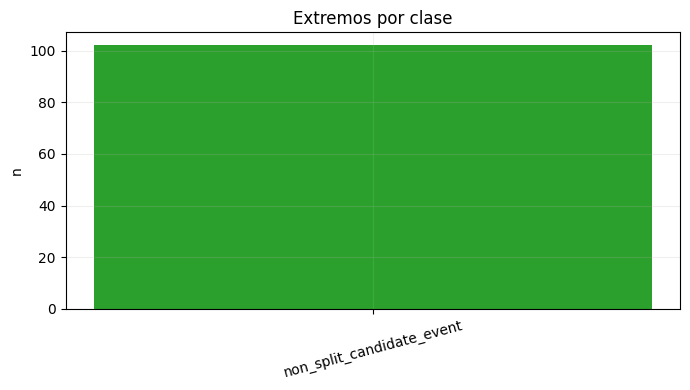

#### Revisi?n de candidatos no-split (uno por uno)

Output()

In [9]:
# PASO 16K - Auditoría split vs extremos
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16k_split_vs_extreme_audit.py")
print(f"[Paso 16K] Ejecutando: {SCRIPT}")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[Paso 16L] Ejecutando: C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16l_split_reverse_engineering.py
=== STEP 16L - SPLIT REVERSE ENGINEERING ===
splits_source: C:\TSIS_Data\data\additional\corporate_actions\splits.parquet
event_source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T192210Z\step16_event_index_quotes_only.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\split_reverse_engineering\step16l_split_reverse_20260226T182655Z
n_rows_event_dedup: 4819
n_extreme_jumps: 196
split_matched: 3
split_like_unmatched: 189
extreme_non_split: 4
global_chart: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\split_reverse_engineering\step16l_split_reverse_20260226T182655Z\step16l_global_comparison.png
ticker_charts_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\split_reverse_engineering\step16l_split_r

### Step 16L output dir`C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\split_reverse_engineering\step16l_split_reverse_20260226T182655Z`

#### Comparativa global (splits data vs tick moves extremos)

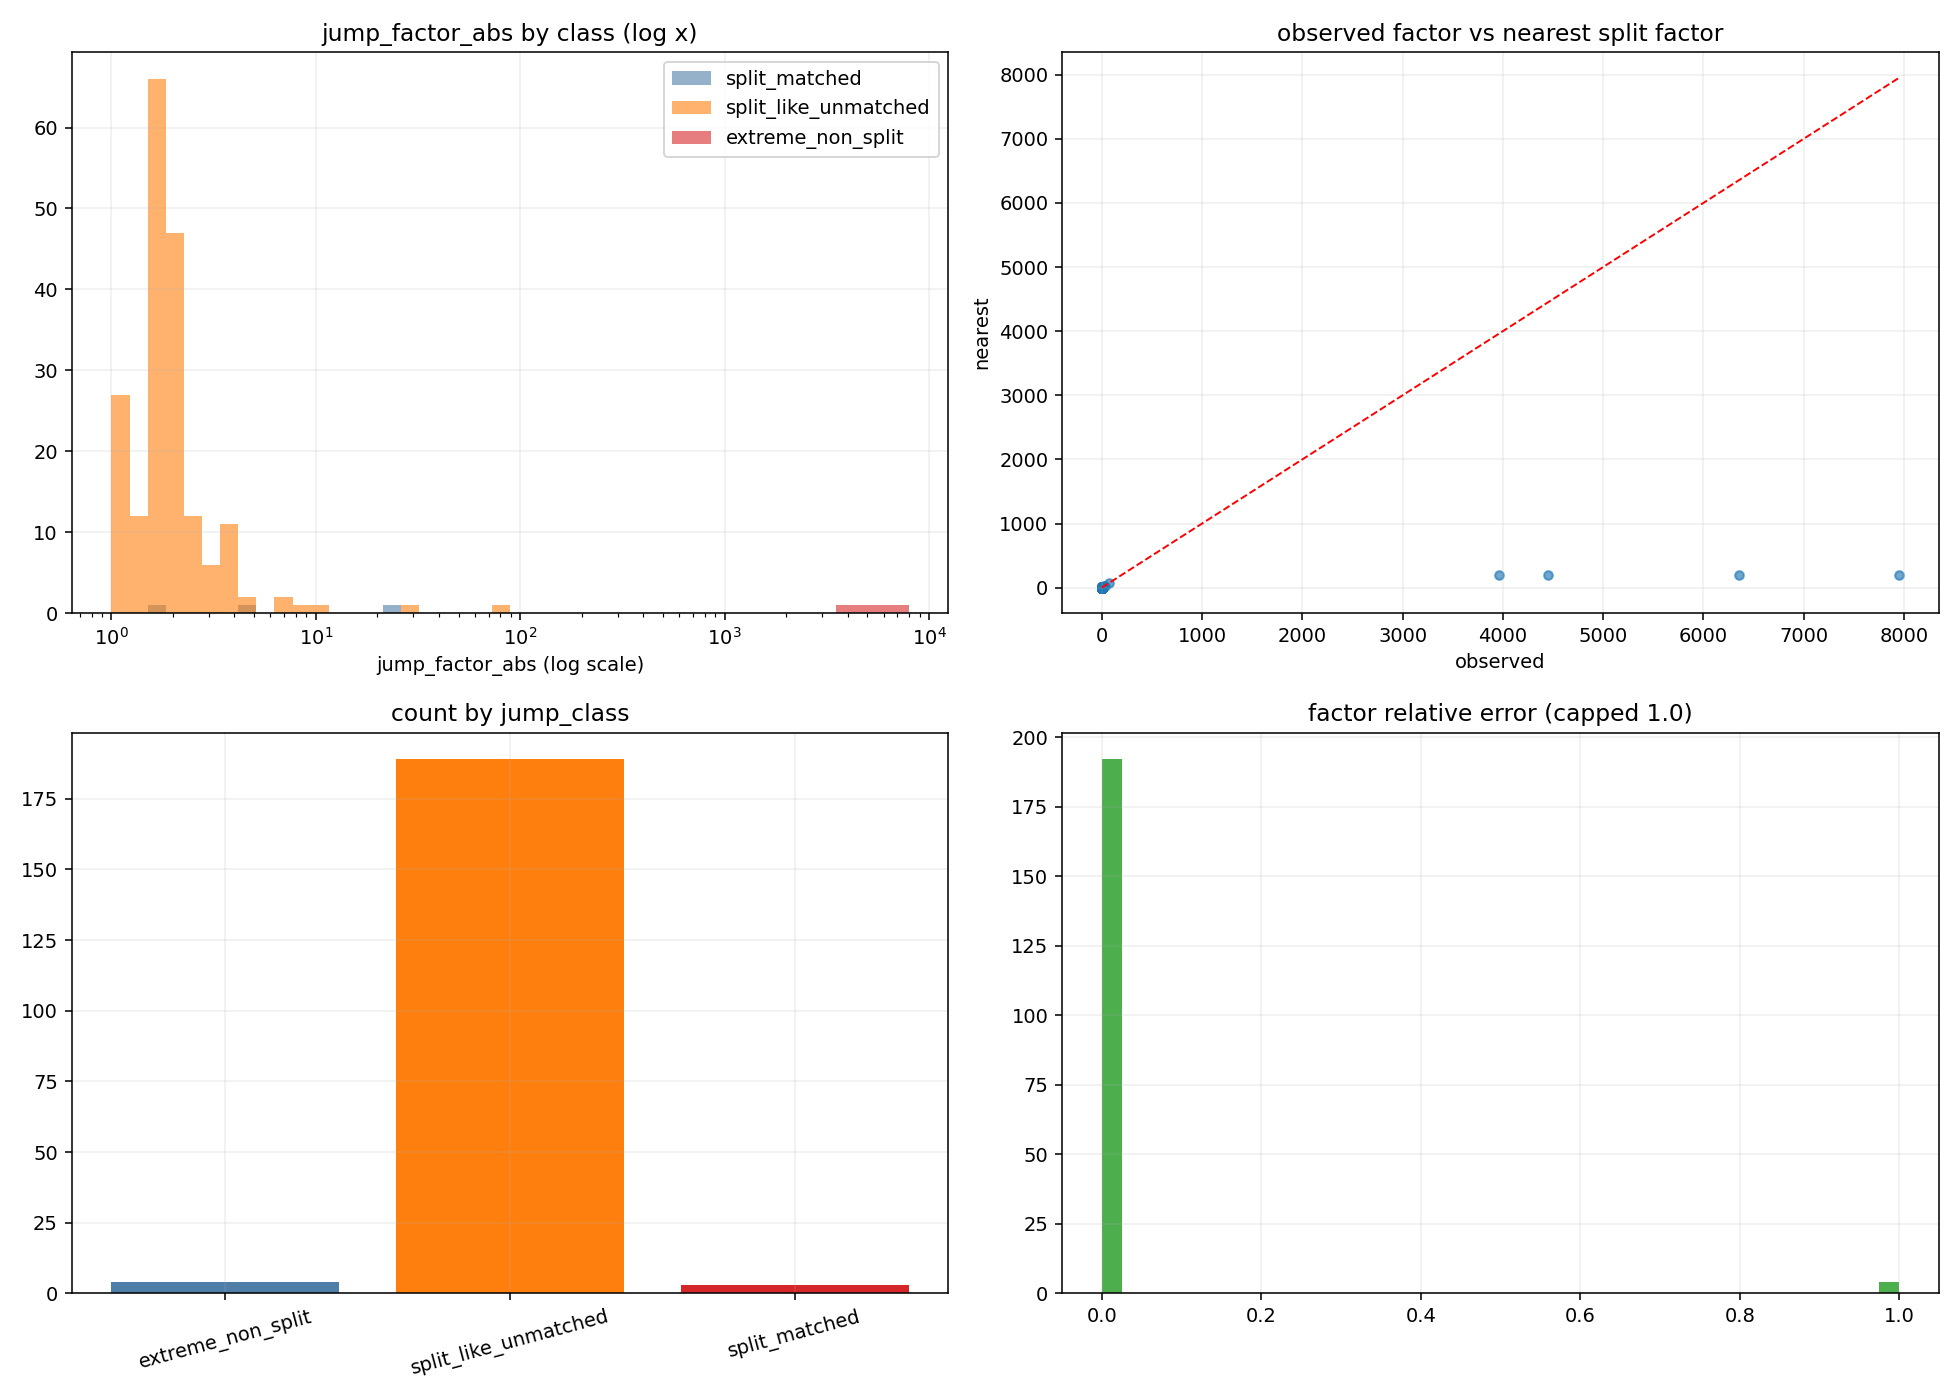

#### Revision interactiva por ticker

Output()

In [10]:
# PASO 16L - Ingeniería inversa de splits/outliers
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16l_split_reverse_engineering.py")
print(f"[Paso 16L] Ejecutando: {SCRIPT}")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

Interpretación de esa salida (step16k/16l split vs saltos extremos):

![](../img/036.png)

**Arriba izquierda (jump_factor_abs by class)**  
- Eje X (log): magnitud del salto jump_factor_abs (1 = sin salto; 2 = 2x; 10 = 10x; 100 = 100x).
- Eje Y: cuántos casos hay en cada rango de salto.
- Color dominante naranja (split_like_unmatched): la mayoría de saltos extremos están entre ~1.2 y ~5 y “parecen
  split”, pero no matchean con split oficial cercano.
- Azul (split_matched) casi nulo: muy pocos extremos sí coinciden con split documentado.
- Rojo (extreme_non_split) aparece sobre todo en la cola extrema (factores enormes, ~10^3–10^4): casos raros,
  probablemente anomalías severas de datos o eventos no explicados por corporate actions.

Conclusión de ese panel: el problema principal no es “no hay patrón”, sino mucha señal tipo split sin reconciliación
limpia con el maestro de splits.
  
**Arriba derecha (observed factor vs nearest split factor)**
  - Línea roja = coincidencia perfecta.
  - Los puntos lejos de la diagonal (observed muy alto, nearest mucho menor) indican saltos extremos que no encajan
  bien con split oficial.
  - Eso sugiere desalineación de metadata o eventos no corporativos.

  
**Abajo izquierda (count by jump_class)**
  - Conteos:
      - split_like_unmatched: dominante (casi todos).
      - split_matched: muy pocos.
      - extreme_non_split: muy pocos.
  - Conclusión: el problema principal aquí no son “errores puros”, sino muchos casos “parecen split pero no matchean”.

  
**Abajo derecha (factor relative error)**
  - Error relativo del factor observado vs split más cercano (capado a 1.0).
  - Pico fuerte en 0: muchos casos están cerca de algún factor conocido.
  - Cola/pico en 1: pocos casos muy mal explicados por splits.

**Resumen práctico:** La mayor parte de extremos parecen de naturaleza “tipo split”, pero la tabla de splits no los está reconciliando bien (fecha/factor/ticker mapping). Antes de tratarlos como eventos de trading, conviene reparar ese matching.

In [11]:
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16l_split_matched_vs_unmatched_widget.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

### Step16L | Comparativa visual matched vs unmatched

Output()

significa que está revelando un desalineamiento de metadatos.

Por qué puede no coincidir un split oficial con el salto en tus series:

- ticker no estable en el tiempo (cambios de símbolo/corporate history).
- fecha de split en tabla (execution_date) distinta de la fecha efectiva en tu serie (offset de 1-5 días por calendario/sesión/UTC).
- comparación entre precios de naturaleza distinta (mid_close de quotes vs precio oficial de split-adjustment).
- varios eventos corporativos cercanos (split + merger/name change) que distorsionan el factor observado.
- outliers microcap (ticks casi cero, huecos de liquidez) que parecen split.

Así que no: “split oficial => siempre salto perfecto en tu gráfico” no se cumple automáticamente sin reconciliación
temporal/identidad.

## Cómo solucionarlo (para no contaminar ML)

1. Reconciliación robusta de splits

- match por ventana (±5d) + factor cercano + mercado abierto.
- soportar composición de factores (dos eventos seguidos).

2. Identidad histórica

- mapear ticker histórico/cambio de símbolo.

3. Ajuste canónico

- construir serie adjustment_factor acumulada por ticker-fecha y derivar precios ajustados consistentes.

4. Gate de calidad para ML

- excluir de entrenamiento los split_like_unmatched no resueltos.
- mantenerlos en PENDING_REPAIR.

5. Regla de evento

- solo usable_for_event si el evento sobrevive tras ajuste y tiene evidencia microestructural (ticks/participación).

## Repercusión en datos (y en P2/P3)

- En tu salida reciente, la mayoría de extremos cayó en split_like_unmatched (aprox. ~190), mientras split_matched y
extreme_non_split son pocos.
- Impacto:
    - sin resolver, esos casos inflan falsos eventos (ruido para ML y backtest).
    - al limpiar, baja volumen bruto de eventos, pero sube calidad.
- En P2/P3:
    - parte de la “recuperación” actual puede ser artificial por saltos no reconciliados.
    - tras limpieza, algunos tickers/eventos volverán a PENDING_REPAIR, pero los que queden serán mucho más útiles
    para estrategia/ML.

Si quieres, el siguiente paso es implementar un gate automático:   
`split_matched => keep, split_like_unmatched => hold/review, extreme_non_split => investigarevento real.`

## Estado actual: separaci?n de eventos y calidad para estrategia

### 1) Lo que ya estamos haciendo bien
Actualmente ya no evaluamos solo ?calidad global? del ticker, sino comportamiento de evento:

- **Paso 16 (base)**: detecta d?as an?malos (`is_event_day`) con `event_score`, `day_range`, `abs(day_return)`.
- **Paso 16E**: punt?a **ciclo completo** (`score_explosion + score_decay`), no solo d?a aislado.
- **Paso 16I**: clasifica reg?menes:
  - `pump_then_dump_confirmed`
  - `pump_then_shakeout`
  - `pump_continuation`

Esto es una buena base para recuperar P2/P3 con criterio de evento.

### 2) Limitaci?n actual
Aunque el enfoque actual es correcto para empezar, a?n es **insuficiente para producci?n/ML final** porque se centra demasiado en un patr?n principal (`explosion -> decay`) y no captura bien todos los contextos microcap/smallcap.

### 3) Qu? falta para robustez real (backtest + ML)
Debemos ampliar a un cat?logo de reg?menes y features contextuales:

1. **Gap regime**
- premarket gap %
- open vs prev close
- gap fill/no fill
- time-to-fail

2. **Liquidity/participation**
- RVOL intrad?a
- ticks por minuto
- spread
- deterioro de liquidez

3. **Borrow/short-pressure** (si hay dataset)
- borrow fee
- disponibilidad
- cambios bruscos
- contexto SSR

4. **Estructura/microestructura**
- rangos por tramo horario
- ruptura/reclaim HOD/LOD
- distancia/reclaim de VWAP

5. **Catalyst/context**
- earnings/news/filings
- d?a de semana
- r?gimen de sesi?n

### 4) Conclusi?n operativa
- **S?**: vamos por buen camino para recuperaci?n inicial de P2/P3.
- **No**: a?n no est? listo para producci?n ni para alimentar ML de forma definitiva.
- **Siguiente paso**: pasar de un patr?n ?nico a un **cat?logo de reg?menes**:
  - `dump_confirmed`
  - `continuation`
  - `re-acceleration`
  - `chop/no-edge`

y etiquetar eventos con ese esquema para backtest y entrenamiento.


S?. Ya revis? el `02` completo (Markdown, c?digo y salidas ejecutadas).  
Estado real ahora mismo:

## D?nde estamos

- Fase de remediaci?n estructural avanzada y casi cerrada:
  - Baseline inicial: `NOT_COMPARABLE=3672` (77%), `FAIL=485`, `WARN=381`, `GO=239`.
  - Causa dominante confirmada: `schema_gap=3629` y `scale_mismatch=43`.
  - Con relanzamiento 03/06 se elimin? `schema_gap` del flujo activo y qued? el bloque de `scale_mismatch`.
  - `scale_mismatch` pas? de `43` a `14` tras auto-scale; luego revisi?n manual aplicada (2 casos con factor manual).

- Fase de recuperaci?n P2/P3 por evento iniciada:
  - Paso 14: `recoverable=3472`, `no_overlap_real=157`.
  - Paso 15: cola `PENDING_REPAIR=3472` con:
    - `P1 window_shift=948` (auto-promovidos),
    - `P2 low_overlap_months=1139`,
    - `P3 low_overlap_days=1385`.

- Fase de event scoring montada (Paso 16A..16L):
  - 16A/16E/16I/16K/16L existen y funcionan.
  - Pero ahora mismo se est? corriendo sobre muestra limitada (`MAX_TICKERS=30`) y el output mostrado est? pr?cticamente en `P0`, no en todo P2/P3.
  - 16K/16L muestran fuerte desalineaci?n split/precio (`split_matched` muy bajo, `split_like_unmatched` muy alto).

## Qu? falta para cerrar esta fase

1. Ejecutar scoring/event lifecycle sobre universo objetivo completo (no solo 30 tickers).
2. Asegurar muestreo estratificado real P0/P2/P3 en 16A.
3. Resolver deduplicaci?n y reconciliaci?n de corporate actions (splits) antes de etiquetar eventos finales.
4. Crear el gate final de calidad para evento (`usable_event`, `usable_partial`, `not_usable_event`) y aplicarlo a P2/P3.
5. Re-materializar universo final para 03/06 con ese gate (`eligible + repaired_event_usable`).

## Ampliaci?n necesaria para robustez real (backtest + ML)

Aunque el enfoque actual es correcto para empezar, a?n es **insuficiente para producci?n/ML final** porque se centra demasiado en un patr?n principal (`explosion -> decay`) y no captura bien todos los contextos microcap/smallcap.

Debemos ampliar a un cat?logo de reg?menes y features contextuales:

1. **Gap regime**
- premarket gap %
- open vs prev close
- gap fill/no fill
- time-to-fail

2. **Liquidity/participation**
- ticks por minuto
- spread
- deterioro de liquidez

3. **Borrow/short-pressure** (si hay dataset)
- borrow fee
- disponibilidad
- cambios bruscos
- contexto SSR

4. **Estructura/microestructura**
- rangos por tramo horario
- ruptura/reclaim HOD/LOD
- distancia/reclaim de VWAP

5. **Catalyst/context**
- earnings/news/filings
- d?a de semana
- r?gimen de sesi?n

## ?En qu? punto del pipeline entra esto?

Ahora mismo, eso a?n no est? dentro del pipeline ejecutado. Est? identificado como la siguiente ampliaci?n.

1. **16A?16E**
- Detecci?n de evento base (`event_day`) + ciclo (`explosion + decay`).

2. **Nuevo bloque intermedio (pendiente)**
- Enriquecimiento contextual (gap/liquidez/borrow/microestructura/catalyst).

3. **16I/16J v2**
- Clasificaci?n de r?gimen con evento + contexto (no solo `explosion -> decay`).

4. **Gate final (16M)**
- `usable_event / usable_partial / not_usable_event`.

5. **Rerun y consumo final**
- Rerun 03/06 con universo `event_usable` y luego backtest/ML.


Siguiente paso lógico: 

**implementar 16M (event quality gate) sobre P2/P3 para cerrar esta fase.**

1. Construir event_quality_gate (usable_event, usable_partial, not_usable_event).
2. Aplicarlo a la cola P2/P3 usando salidas de 16E/16I/16K/16L.
3. Materializar tablas finales + resumen de promoción.
4. Dejar loader en cell_code/02_policy_integration.


**`event_quality_gate` lo construiría con reglas explícitas por evento/ticker:**

**usable_event**

- evento lifecycle válido (16E: is_lifecycle_event=True)
- régimen útil (16I: pump_then_dump_confirmed o pump_then_shakeout)
- no marcado como problema de split no reconciliado (16K/16L)
- evidencia mínima en ventana (ticks/días suficientes)

**usable_partial**

- hay señal de evento, pero falta robustez en algún eje:
    - régimen pump_continuation, o
    - posible split-like sin resolver pero no extremo, o
    - evidencia incompleta (pocos días/ticks)
- se conserva para exploración/backtest secundario, no para entrenamiento principal.

**not_usable_event**

- evento inválido o muy contaminado:
    - falla lifecycle,
    - outlier/split inconsistente fuerte,
    - calidad mínima no cumplida.

**Cómo lo aplico a P2/P3:**

1. tomo repair_queue_v1 y filtro P2/P3.
2. uno por ticker con 16E (señal lifecycle), 16I (régimen), 16K/16L (riesgo de split/outlier).
3. agrego por ticker (mejor evento o score robusto).
4. asigno event_quality_gate.
5. saco tablas:

- p2p3_gate_assignments.parquet
- promoted_usable_event.parquet
- gate_summary.parquet/json.

**Sobre si 16E/16I/16K/16L están “100% bien”:**

- No, 100% no puedo afirmarlo hoy.
- Están funcionales y coherentes para v1, pero hay riesgos ya vistos:
    - MAX_TICKERS=30 en parte del flujo (muestra limitada),
    - desalineación fuerte split/precio (split_like_unmatched alto),
    - duplicados/higiene temporal en algunos outputs.
- Por eso el gate debe incluir flags de confianza y dejar pending_repair donde haya duda.

In [1]:
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16m_preflight_audit_event_gate.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 16M PRE-FLIGHT AUDIT ===
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_gate_preflight\step16m_preflight_20260226T190522Z
ok_for_event_gate: False

[Missing columns]
{'16e': [], '16i': [], '16k': [], '16l': []}

[Duplicates]
{'16e': 4819, '16i': 31}

[Coverage P2/P3 across sources]
shape: (5, 2)
┌───────────────┬───────────┐
│ source        ┆ n_tickers │
│ ---           ┆ ---       │
│ str           ┆ i64       │
╞═══════════════╪═══════════╡
│ P2P3_queue    ┆ 2524      │
│ 16E_lifecycle ┆ 0         │
│ 16I_regime    ┆ 0         │
│ 16K_outlier   ┆ 0         │
│ 16L_jumps     ┆ 0         │
└───────────────┴───────────┘

[16L jump_class counts]
shape: (3, 2)
┌──────────────────────┬─────┐
│ jump_class           ┆ n   │
│ ---                  ┆ --- │
│ str                  ┆ u32 │
╞══════════════════════╪═════╡
│ split_like_unmatched ┆ 189 │
│ extreme_non_split    ┆ 4   │
│ split_matched        ┆ 3   │
└──────────────────────┴─────┘

[16

Clave de lectura:

- ok_for_event_gate: False
    - El preflight bloquea porque la evidencia no está alineada con la cola P2/P3.
- Missing columns: []
    - Estructura de archivos está bien (no faltan columnas).
- Duplicates {'16e': 4819, '16i': 31}
    - Hay duplicados severos por clave (ticker-date / ticker-event_date), así que no es fiable agregar sin deduplicar.
- Coverage P2P3 ... 16E/16I/16K/16L = 0
    - Esta es la razón principal: los outputs 16* que usaste fueron corridos sobre otro universo (muestra P0/30
    tickers), no sobre los 2524 tickers P2/P3 actuales.
    - Por eso no hay intersección.
- 16L jump_class y 16K extreme_class
    - Son conteos internos de esa muestra 16*, no de tu cola P2/P3.
    - Señalan además desalineación split (split_like_unmatched alto).

En resumen:

- Los artefactos 16* existen, pero no son aplicables todavía a P2/P3.
- Hay que:

1. rerun 16A/16E/16I/16K/16L con universo P2/P3 (o estratificado incluyendo P2/P3),
2. deduplicar claves antes del gate,
3. repetir preflight; recién ahí 16M gate.


Demostrado: no son filas idénticas completas, pero sí son duplicados de clave que contaminan el cálculo.

Resultados forenses:

- 16E
    - rows_total=9638
    - unique_full_rows=9638 (no hay clones exactos)
    - duplicate_keys (ticker+date)=4819
    - En esos duplicados, cambian columnas de futuro:
        - fwd_ret_3d, fwd_ret_1d, drawdown_scale, score_decay, event_lifecycle_score, etc.
- 16I
    - rows_total=102
    - unique_full_rows=102
    - duplicate_keys (ticker+event_date)=31
    - Cambian sobre todo:
        - score_decay y event_lifecycle_score
    - Ejemplo real ABUS 2020-07-23: misma fecha/evento, distinto score_decay (5.8078 vs 2.1572).

Conclusión:

- Tu hipótesis era correcta: no es solo “misma fecha con evento distinto legítimo”.
- Son claves repetidas con payload inconsistente por contaminación previa del pipeline (origen: duplicados aguas
arriba).

Qué implica:

- No se puede cerrar 16M gate hasta deduplicar.
- Hay que deduplicar en 16A/input base por ticker+date antes de calcular 16E, y regenerar 16I.

In [2]:
# RERUN 16E (con dedupe)
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16e_event_lifecycle_scores.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 16E - EVENT LIFECYCLE SCORING ===
input_step16: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260225T192210Z\step16_event_index_quotes_only.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T191507Z
output_scores: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T191507Z\step16e_event_lifecycle_scores.parquet
summary: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T191507Z\step16e_summary.parquet
top_lifecycle: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T191507Z\step16e_top_lifecycle_events.parquet
n_rows: 4819
n_tickers: 30
n_explosion_days: 771
n_decay_followup: 958
n_lifecycle_events: 55


### Step 16E output dir
`C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T191507Z`

,priority_bucket,n_days,n_tickers,n_explosion_days,n_decay_days,n_lifecycle_events,score_explosion_mean,score_decay_mean,lifecycle_score_p95
0,P0,4819,30,771,958,55,60.757014,0.84559,1.869309


,ticker,date,priority_bucket,source_group,day_return,day_range,n_ticks,score_explosion,score_decay,event_lifecycle_score,is_explosion_day,is_decay_followup,is_lifecycle_event
0,AIV,2008-08-01,P0,eligible_v3,4303.761905,4303.798370,42479,48175.601309,2.389812,28906.316710,True,True,True
1,ACC,2020-03-13,P0,eligible_v3,0.233242,0.280082,21852,2.886988,21.497982,10.331385,True,True,True
2,ABUS,2020-07-23,P0,eligible_v3,1.077601,1.827160,208749,13.380612,4.816699,9.955047,True,True,True
3,ACC,2020-03-12,P0,eligible_v3,0.267080,0.291731,25624,3.386457,16.022925,8.441044,True,True,True
4,ACHC,2020-03-17,P0,eligible_v3,-0.832166,0.835987,17058,2.278806,14.596066,7.205710,True,True,True
5,ACHC,2020-03-20,P0,eligible_v3,-0.827778,0.850980,30765,2.604891,13.786020,7.077343,True,True,True
6,AJRD,2019-06-28,P0,eligible_v3,0.149254,0.691734,15744,5.827954,8.254409,6.798536,True,True,True
7,ACHC,2019-03-01,P0,eligible_v3,0.145951,0.171751,31810,1.777304,13.334431,6.400155,True,True,True
8,ACHC,2020-03-25,P0,eligible_v3,-0.152183,0.338807,56914,1.511190,13.715553,6.392935,True,True,True
9,ABR,2020-03-19,P0,eligible_v3,0.073113,0.226415,19348,4.094749,9.468970,6.244437,True,True,True


In [3]:
# RERUN 16I (con dedupe)
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16i_pump_dump_regime_classifier.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 16I - PUMP/DUMP REGIME CLASSIFIER ===
input_step16e: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T191507Z\step16e_event_lifecycle_scores.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T191516Z
labels: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T191516Z\step16i_event_regime_labels.parquet
summary: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T191516Z\step16i_summary.parquet
joined: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T191516Z\step16i_event_regime_joined.parquet
n_events: 55
n_tickers: 17
ACC_sample:
{'ticker': ['ACC', 'ACC', 'ACC'], 'event_date': ['2020-03-13 00:00:00', '2020-03-12 00:00:00', 

### Step 16I output dir
`C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T191516Z`

,regime_label,n_events,n_tickers,lifecycle_score_mean,dd10_median,rebound_median
0,pump_then_shakeout,34,13,854.494945,-0.285453,1.007428
1,pump_then_dump_confirmed,14,9,5.413927,-0.511773,0.320514
2,pump_continuation,7,5,4.422847,-0.066159,1.525875


,ticker,event_date,priority_bucket,source_group,event_lifecycle_score,score_explosion,score_decay,dd5,dd10,rebound_ratio_10d,slope10,regime_label
0,AIV,2008-08-01 00:00:00,P0,eligible_v3,28906.316710,48175.601309,2.389812,-0.131475,-0.131475,59298.291829,1.589478e+06,pump_then_shakeout
1,ACC,2020-03-13 00:00:00,P0,eligible_v3,10.331385,2.886988,21.497982,-0.298206,-0.298206,13.636280,8.212747e-01,pump_then_shakeout
2,ABUS,2020-07-23 00:00:00,P0,eligible_v3,9.955047,13.380612,4.816699,-0.361923,-0.369559,0.261846,-2.117621e-02,pump_then_dump_confirmed
3,ACC,2020-03-12 00:00:00,P0,eligible_v3,8.441044,3.386457,16.022925,-0.134518,-0.134518,28.262942,5.437268e-01,pump_then_shakeout
4,ACHC,2020-03-17 00:00:00,P0,eligible_v3,7.205710,2.278806,14.596066,-0.979335,-0.985477,0.160024,-3.631643e-04,pump_then_dump_confirmed
5,ACHC,2020-03-20 00:00:00,P0,eligible_v3,7.077343,2.604891,13.786020,-0.915675,-0.915675,0.833803,-1.864397e-04,pump_then_shakeout
6,AJRD,2019-06-28 00:00:00,P0,eligible_v3,6.798536,5.827954,8.254409,-0.098708,-0.098708,0.948414,-1.089503e-02,pump_continuation
7,ACHC,2019-03-01 00:00:00,P0,eligible_v3,6.400155,1.777304,13.334431,-0.974662,-0.997480,1.034030,-1.529530e-02,pump_then_shakeout
8,ACHC,2020-03-25 00:00:00,P0,eligible_v3,6.392935,1.511190,13.715553,-0.900539,-0.900539,0.056327,-6.120902e-06,pump_then_dump_confirmed
9,ABR,2020-03-19 00:00:00,P0,eligible_v3,6.244437,4.094749,9.468970,-0.278977,-0.278977,0.658160,-1.031600e-02,pump_then_shakeout


In [4]:


# PRE-FLIGHT 16M (validación)
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16m_preflight_audit_event_gate.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 16M PRE-FLIGHT AUDIT ===
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_gate_preflight\step16m_preflight_20260226T191524Z
ok_for_event_gate: False

[Missing columns]
{'16e': [], '16i': [], '16k': [], '16l': []}

[Duplicates]
{'16e': 0, '16i': 0}

[Coverage P2/P3 across sources]
shape: (5, 2)
┌───────────────┬───────────┐
│ source        ┆ n_tickers │
│ ---           ┆ ---       │
│ str           ┆ i64       │
╞═══════════════╪═══════════╡
│ P2P3_queue    ┆ 2524      │
│ 16E_lifecycle ┆ 0         │
│ 16I_regime    ┆ 0         │
│ 16K_outlier   ┆ 0         │
│ 16L_jumps     ┆ 0         │
└───────────────┴───────────┘

[16L jump_class counts]
shape: (3, 2)
┌──────────────────────┬─────┐
│ jump_class           ┆ n   │
│ ---                  ┆ --- │
│ str                  ┆ u32 │
╞══════════════════════╪═════╡
│ split_like_unmatched ┆ 189 │
│ extreme_non_split    ┆ 4   │
│ split_matched        ┆ 3   │
└──────────────────────┴─────┘

[16K ex

**esto confirma exactamente el diagnóstico:**

- Duplicates ya está arreglado (16e=0, 16i=0).
- El bloqueo ahora es solo cobertura: P2/P3 -> 0 en 16E/16I/16K/16L.

Qué significa:

- Los pasos 16* siguen corriendo sobre un universo que no incluye P2/P3 (muestra limitada/P0).
- Por eso ok_for_event_gate sigue en False: no hay evidencia 16* para los 2524 tickers P2/P3.

Qué toca ahora:

1. Reejecutar 16A incluyendo P2/P3 (sin límite de 30, o muestreo estratificado real).
2. Reejecutar en cadena 16E -> 16I -> 16K -> 16L.
3. Repetir preflight 16M; ahí debería aparecer cobertura > 0 para P2/P3.
4. Si pasa, construir gate final usable_event / usable_partial / not_usable_event.

Si quieres, te parcheo ahora 16A para modo full_p2p3 y te dejo loaders listos.

In [6]:
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16a_event_index_builder_p2p3_full.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[16A_v2] ticker 1/2524: AACI
[16A_v2] ticker 100/2524: AVNS
[16A_v2] ticker 200/2524: CENH
[16A_v2] ticker 300/2524: DTOC
[16A_v2] ticker 400/2524: FUV
[16A_v2] ticker 500/2524: IBKC
[16A_v2] ticker 600/2524: LKFN
[16A_v2] ticker 700/2524: NKLR
[16A_v2] ticker 800/2524: PRGX
[16A_v2] ticker 900/2524: SHPH
[16A_v2] ticker 1000/2524: THOR
[16A_v2] ticker 1100/2524: WLAC
[16A_v2] ticker 1200/2524: ALUR
[16A_v2] ticker 1300/2524: BETS
[16A_v2] ticker 1400/2524: CLIK
[16A_v2] ticker 1500/2524: DNAA
[16A_v2] ticker 1600/2524: FIII
[16A_v2] ticker 1700/2524: HAAC
[16A_v2] ticker 1800/2524: ISSC
[16A_v2] ticker 1900/2524: LVTX
[16A_v2] ticker 2000/2524: NFH
[16A_v2] ticker 2100/2524: PLXP
[16A_v2] ticker 2200/2524: SAFE
[16A_v2] ticker 2300/2524: SSPK
[16A_v2] ticker 2400/2524: UBX
[16A_v2] ticker 2500/2524: YDKG
[16A_v2] ticker 2524/2524: ZYBT
=== STEP 16A v2 - EVENT INDEX BUILDER P2/P3 FULL ===
mode: p2p3_only
candidate_universe: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_int

### Step 16A v2 output dir `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260226T192146Z_p2p3full`

priority_bucket,n_days,n_tickers,n_event_days,event_score_mean,day_range_p95,abs_return_p95
str,u32,u32,u32,f64,f64,f64
"""P2""",2387,1126,1387,0.850171,1.872502,0.517079
"""P3""",12372,1384,7833,107.426078,1.420606,0.48588


ticker,date,priority_bucket,repair_cause,source_group,n_ticks,day_range,day_return,event_score,event_rank_in_ticker
str,str,str,str,str,i64,f64,f64,f64,u32
"""AVAN""","""2020-12-10""","""P3""","""low_overlap_days""","""repair_queue_residual""",1017,0.011646,0.004051,810127.039036,1
"""AII""","""2007-06-28""","""P3""","""low_overlap_days""","""repair_queue_residual""",53,16384.91018,10940.753402,161503.684666,1
"""AII""","""2007-09-28""","""P3""","""low_overlap_days""","""repair_queue_residual""",837,10905.660879,10905.239826,160979.025914,2
"""HTH""","""2007-08-17""","""P3""","""low_overlap_days""","""repair_queue_residual""",1949,9021.017504,9020.544434,86701.525241,1
"""SMA""","""2008-04-24""","""P3""","""low_overlap_days""","""repair_queue_residual""",11708,7102.026502,7101.892933,43348.111511,1
…,…,…,…,…,…,…,…,…,…
"""BBW""","""2005-06-06""","""P3""","""low_overlap_days""","""repair_queue_residual""",3600,94.391273,94.331041,215.174448,1
"""ISAA""","""2021-06-09""","""P3""","""low_overlap_days""","""repair_queue_residual""",662,0.501007,-0.499496,202.462828,1
"""FORE""","""2021-08-20""","""P3""","""low_overlap_days""","""repair_queue_residual""",133,0.846193,-0.614716,123.261285,1


In [7]:
# 1) Rerun 16E
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16e_event_lifecycle_scores.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 16E - EVENT LIFECYCLE SCORING ===
input_step16: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_index\step16_event_index_20260226T192146Z_p2p3full\step16_event_index_quotes_only.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T192814Z
output_scores: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T192814Z\step16e_event_lifecycle_scores.parquet
summary: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T192814Z\step16e_summary.parquet
top_lifecycle: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T192814Z\step16e_top_lifecycle_events.parquet
n_rows: 14759
n_tickers: 2510
n_explosion_days: 9169
n_decay_followup: 1604
n_lifecycle_events: 106


### Step 16E output dir
`C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T192814Z`

,priority_bucket,n_days,n_tickers,n_explosion_days,n_decay_days,n_lifecycle_events,score_explosion_mean,score_decay_mean,lifecycle_score_p95
0,P2,2387,1126,1373,89,4,0.612619,0.341442,1.142625
1,P3,12372,1384,7796,1515,102,25.942411,0.817458,1.794036


,ticker,date,priority_bucket,source_group,day_return,day_range,n_ticks,score_explosion,score_decay,event_lifecycle_score,is_explosion_day,is_decay_followup,is_lifecycle_event
0,ACTT,2020-03-09,P3,repair_queue_residual,211.607431,212.097525,126,2316.585276,14.945679,1395.929437,True,True,True
1,SRRA,2022-01-26,P3,repair_queue_residual,0.257268,0.334208,41071,2.699852,436.043683,176.037384,True,True,True
2,SRRA,2022-01-25,P3,repair_queue_residual,-0.059863,0.181667,55820,1.023577,434.982244,174.607044,True,True,True
3,ATRC,2005-08-05,P3,repair_queue_residual,81.886598,82.055670,8203,218.746805,6.231461,133.740667,True,True,True
4,TIG,2020-07-16,P3,repair_queue_residual,-0.091467,0.160725,20113,1.155032,84.855341,34.635156,True,True,True
5,PAE,2020-03-13,P3,repair_queue_residual,-0.541081,0.612879,8365,1.143451,76.344354,31.223813,True,True,True
6,COWN,2022-07-05,P3,repair_queue_residual,0.052989,0.067595,45964,2.545262,73.734089,31.020793,True,True,True
7,PAE,2020-06-19,P3,repair_queue_residual,0.150369,0.657744,21135,2.884404,67.229698,28.622522,True,True,True
8,PAE,2020-03-16,P3,repair_queue_residual,-0.561545,0.624438,5935,1.017673,64.419138,26.378259,True,True,True
9,LBPH,2024-01-02,P3,repair_queue_residual,0.354761,0.514255,105700,5.259532,40.453457,19.337102,True,True,True


In [8]:
# 2) Rerun 16I
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16i_pump_dump_regime_classifier.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 16I - PUMP/DUMP REGIME CLASSIFIER ===
input_step16e: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle\step16e_event_lifecycle_20260226T192814Z\step16e_event_lifecycle_scores.parquet
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T192839Z
labels: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T192839Z\step16i_event_regime_labels.parquet
summary: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T192839Z\step16i_summary.parquet
joined: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T192839Z\step16i_event_regime_joined.parquet
n_events: 106
n_tickers: 91


### Step 16I output dir
`C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_lifecycle_regime\step16i_regime_20260226T192839Z`

,regime_label,n_events,n_tickers,lifecycle_score_mean,dd10_median,rebound_median
0,pump_then_shakeout,63,58,30.743834,-0.315789,0.794555
1,pump_continuation,22,19,14.770594,-0.030032,0.732101
2,pump_then_dump_confirmed,21,21,12.001154,-0.514515,0.256671


,ticker,event_date,priority_bucket,source_group,event_lifecycle_score,score_explosion,score_decay,dd5,dd10,rebound_ratio_10d,slope10,regime_label
0,ACTT,2020-03-09 00:00:00,P3,repair_queue_residual,1395.929437,2316.585276,14.945679,-0.498767,-0.504541,0.999015,-8.585203,pump_then_shakeout
1,SRRA,2022-01-26 00:00:00,P3,repair_queue_residual,176.037384,2.699852,436.043683,-0.131857,-0.131857,0.514365,0.016487,pump_then_shakeout
2,SRRA,2022-01-25 00:00:00,P3,repair_queue_residual,174.607044,1.023577,434.982244,0.091489,0.091489,1.812021,-0.003889,pump_continuation
3,ATRC,2005-08-05 00:00:00,P3,repair_queue_residual,133.740667,218.746805,6.231461,-0.667340,-0.667340,0.147491,-0.448716,pump_then_dump_confirmed
4,TIG,2020-07-16 00:00:00,P3,repair_queue_residual,34.635156,1.155032,84.855341,-0.499001,-0.499001,0.884204,-0.080401,pump_then_shakeout
5,PAE,2020-03-13 00:00:00,P3,repair_queue_residual,31.223813,1.143451,76.344354,-0.751828,-0.751828,0.340786,-0.012019,pump_then_dump_confirmed
6,COWN,2022-07-05 00:00:00,P3,repair_queue_residual,31.020793,2.545262,73.734089,-0.056233,-0.056233,0.098789,0.001031,pump_continuation
7,PAE,2020-06-19 00:00:00,P3,repair_queue_residual,28.622522,2.884404,67.229698,-0.507970,-0.507970,0.895856,-0.005190,pump_then_shakeout
8,PAE,2020-03-16 00:00:00,P3,repair_queue_residual,26.378259,1.017673,64.419138,-0.433984,-0.433984,1.346485,-0.010111,pump_then_shakeout
9,LBPH,2024-01-02 00:00:00,P3,repair_queue_residual,19.337102,5.259532,40.453457,-0.124511,-0.124511,2.057714,0.048249,pump_then_shakeout


In [9]:
# 3) Preflight 16M again
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\02_policy_integration\step16m_preflight_audit_event_gate.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

=== STEP 16M PRE-FLIGHT AUDIT ===
output_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\event_gate_preflight\step16m_preflight_20260226T192843Z
ok_for_event_gate: True

[Missing columns]
{'16e': [], '16i': [], '16k': [], '16l': []}

[Duplicates]
{'16e': 0, '16i': 0}

[Coverage P2/P3 across sources]
shape: (5, 2)
┌───────────────┬───────────┐
│ source        ┆ n_tickers │
│ ---           ┆ ---       │
│ str           ┆ i64       │
╞═══════════════╪═══════════╡
│ P2P3_queue    ┆ 2524      │
│ 16E_lifecycle ┆ 2510      │
│ 16I_regime    ┆ 91        │
│ 16K_outlier   ┆ 0         │
│ 16L_jumps     ┆ 0         │
└───────────────┴───────────┘

[16L jump_class counts]
shape: (3, 2)
┌──────────────────────┬─────┐
│ jump_class           ┆ n   │
│ ---                  ┆ --- │
│ str                  ┆ u32 │
╞══════════════════════╪═════╡
│ split_like_unmatched ┆ 189 │
│ extreme_non_split    ┆ 4   │
│ split_matched        ┆ 3   │
└──────────────────────┴─────┘

[16K ext

Perfecto, este resultado es muy bueno.

Qué significa ahora:

- ok_for_event_gate: True
    - Ya puedes construir el gate 16M.
- Missing columns: [] y Duplicates: 0
    - Integridad estructural y de claves ya resuelta.
- Cobertura:
    - 16E_lifecycle: 2510/2524 → muy alta.
    - 16I_regime: 91/2524 → normal, porque régimen solo existe cuando hay lifecycle event fuerte.
    - 16K/16L: 0 → importante: esos dos aún no están corridos sobre este universo P2/P3 full, por eso no aportan
    filtro aquí.

Recomendación inmediata para 16M:

1. Construir gate con 16E + 16I como núcleo.
2. Tratar 16K/16L como split_signal_unknown (no bloquear por falta de cobertura).
3. Etiquetar:

- usable_event (lifecycle + régimen útil),
- usable_partial (lifecycle sin régimen fuerte),
- not_usable_event (sin evidencia mínima).

4. Guardar promovidos y resumen para rerun 03/06.

Si quieres, lo implemento ya como step16m_event_quality_gate_p2p3.py + loader.